# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
- [3. Data](#3.-Data)
    - [3.1 Presentation of the products used](#3.1-Presentation-of-the-products-used)
        - [3.1.1 Physical Oceanography - Global Ocean Physics Analysis and Forecast](#3.1.1-Physical-Oceanography---Global-Ocean-Physics-Analysis-and-Forecast)
        - [3.1.2 Wave Data - Global Ocean Waves Analysis and Forecast](#3.1.2-Wave-Data---Global-Ocean-Waves-Analysis-and-Forecast)
        - [3.1.3 Biogeochemical Data - Suspended Particulate Matter](#3.1.3-Biogeochemical-Data---Suspended-Particulate-Matter)
    - [3.2 Accessing the data: the Copernicus ToolBox](#3.2-Accessing-the-data:-the-Copernicus-ToolBox)
- [4. First look at the data](#4.-First-look-at-the-data)
    - [4.1 Loading and exploring the datasets](#4.1-Loading-and-exploring-the-datasets)
    - [4.2 Spatial overview of the study area](#4.2-Spatial-overview-of-the-study-area)
- [5. Ocean Currents Analysis](#5.-Ocean-Currents-Analysis)
    - [5.1 Surface current patterns](#5.1-Surface-current-patterns)
    - [5.2 Vertical current profiles](#5.2-Vertical-current-profiles)
    - [5.3 Seasonal variability](#5.3-Seasonal-variability)
- [6. Wave Climate Analysis](#6.-Wave-Climate-Analysis)
    - [6.1 Significant wave height statistics](#6.1-Significant-wave-height-statistics)
    - [6.2 Wave period and direction](#6.2-Wave-period-and-direction)
    - [6.3 Wave energy potential](#6.3-Wave-energy-potential)
- [7. Sediment Transport Processes](#7.-Sediment-Transport-Processes)
    - [7.1 Bed shear stress computation](#7.1-Bed-shear-stress-computation)
    - [7.2 Shields parameter analysis](#7.2-Shields-parameter-analysis)
    - [7.3 Sediment transport capacity estimation](#7.3-Sediment-transport-capacity-estimation)
    - [7.4 Wave-induced sediment resuspension](#7.4-Wave-induced-sediment-resuspension)
    - [7.5 Suspended particulate matter dynamics](#7.5-Suspended-particulate-matter-dynamics)
    - [7.6 Erosion and deposition tendency analysis](#7.6-Erosion-and-deposition-tendency-analysis)
- [8. Marine Energy Assessment](#8.-Marine-Energy-Assessment)
    - [8.1 Current energy potential](#8.1-Current-energy-potential)
    - [8.2 Wave energy potential](#8.2-Wave-energy-potential)
    - [8.3 Combined analysis and site suitability](#8.3-Combined-analysis-and-site-suitability)
- [9. Exercises](#9.-Exercises)
- [10. Conclusion](#10.-Conclusion)

# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The coastal waters of South Africa represent a unique and dynamic marine environment with significant potential for marine renewable energy development. Located at the convergence of the Atlantic and Indian Oceans, this region experiences complex oceanographic conditions driven by major current systems including the Agulhas Current along the east coast and the Benguela Current along the west coast. These powerful ocean currents, combined with the region's energetic wave climate, create both opportunities and challenges for marine energy projects.

South Africa's coastline stretches approximately 3,000 km and encompasses diverse marine environments, from the cold, nutrient-rich waters of the Benguela upwelling system in the west to the warm, fast-flowing Agulhas Current in the east. The Agulhas Current is one of the strongest western boundary currents in the world, transporting warm water southward along the shelf edge at velocities that can exceed 2 m/s. This current system has been identified as having substantial potential for ocean current energy extraction. Additionally, South Africa's exposure to the Southern Ocean results in a high-energy wave climate, particularly along the southern and western coasts, making it attractive for wave energy conversion technologies.

Understanding the hydrodynamic conditions and sediment transport processes in this region is crucial for several reasons:

1. **Marine Energy Development**: Accurate characterization of ocean currents and waves is essential for assessing energy resource potential, optimizing device placement, and predicting power generation.

2. **Environmental Impact Assessment**: Sediment transport processes affect coastal morphology, water quality, and marine ecosystems. Any marine energy installation must consider potential impacts on sediment dynamics and coastal stability.

3. **Engineering Design**: Knowledge of extreme current velocities, wave heights, and bed shear stresses is necessary for the structural design of energy conversion devices and their moorings.

4. **Operational Planning**: Seasonal and interannual variability in oceanographic conditions influences the operation and maintenance schedules of marine energy projects.

This notebook focuses on the analysis of hydrodynamic variables and sediment transport processes for the South African coastal region, with particular emphasis on their implications for marine energy projects. We will utilize data from Copernicus Marine Service to examine:

- Ocean current velocities (horizontal and vertical structure)
- Wave characteristics (height, period, direction)
- Temperature and salinity distributions
- Derived parameters relevant to sediment transport (bed shear stress, Shields parameter, transport capacity)
- Suspended particulate matter concentrations

**Study Area**: South African coastal waters  
**Coordinates**: 40°S to 29°S, 14°E to 34°E  
**Time Period**: Year 2025

<div align="center">
<img src="./img/south_africa_currents_map.png" width="800">

*Schematic representation of major current systems around South Africa. The Agulhas Current (warm, southward flow) dominates the east coast, while the Benguela Current (cold, northward flow) characterizes the west coast.*
</div>

# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules
[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary available tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this exercise.

| Module name | Description |
| :---: | :---|
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python and for managing ND-arrays.|
| **pandas** | [Pandas](https://pandas.pydata.org/docs/) is a powerful package to manage data tables and time series.|
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) is a very user friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
| **scipy** | [SciPy](https://scipy.org/) is an open-source Python library used for scientific and technical computing, providing tools for mathematics, statistics, optimization, and signal processing, making it essential for data analysis and complex computations. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** | [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data analyses in Python. |
| **datetime** | [Datetime](https://docs.python.org/3/library/datetime.html) supplies classes for manipulating dates and times |
| **cmocean** | [cmocean](https://matplotlib.org/cmocean/) provides beautiful colormaps specifically designed for oceanographic data visualization. |


In [2]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import datetime
import pandas as pd
import os

from scipy.stats import linregress, pearsonr
from scipy.interpolate import griddata
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set plotting style
plt.style.use('bmh')

# Create output directories if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('img', exist_ok=True)
os.makedirs('out', exist_ok=True)

print("All libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Xarray version: {xr.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

All libraries loaded successfully!
NumPy version: 2.3.4
Xarray version: 2025.10.1
Matplotlib version: 3.10.7


# 3. Data

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 Presentation of the products used

[Go back to the "Table of contents"](#Table-of-contents)

For this analysis of hydrodynamics and sediment transport in South African waters, we will utilize multiple products from the Copernicus Marine Service catalogue. These products provide comprehensive coverage of physical oceanography, wave conditions, and ocean color parameters necessary for assessing marine energy potential and sediment dynamics.

### 3.1.1 Physical Oceanography - Global Ocean Physics Analysis and Forecast

[Go back to the "Table of contents"](#Table-of-contents)

The primary source for ocean current velocities, temperature, salinity, and sea surface height is the **Global Ocean Physics Analysis and Forecast** product. This state-of-the-art operational system provides daily analyses and 10-day forecasts of the global ocean physical state.

The system is based on the NEMO (Nucleus for European Modelling of the Ocean) ocean model at 1/12° resolution (~8 km), coupled with the SI3 sea-ice model and the GELATO sea-ice model. It assimilates satellite observations of sea level anomaly, sea surface temperature, and sea ice concentration, as well as in-situ temperature and salinity profiles from Argo floats and other observing systems.

**Key characteristics:**

| Parameter | Value |
| :---: | :---|
| **Variables used** | uo (eastward velocity), vo (northward velocity), thetao (temperature), so (salinity), zos (sea surface height), bottomT (bottom temperature) |
| **Product identifier** | [GLOBAL_ANALYSISFORECAST_PHY_001_024](https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_PHY_001_024/description) |
| **Spatial resolution** | 1/12° × 1/12° (~8 km) |
| **Vertical levels** | 50 depth levels (0 to 5500m) |
| **Temporal resolution** | Daily |
| **Temporal coverage** | 2019-01-01 to present + 10-day forecast |

<center><img src="./img/global_ocean_analysis.png" width="300"></center>

**For detailed information about the product, please consult the document:** [Product User Manual (PUM)](https://catalogue.marine.copernicus.eu/documents/PUM/CMEMS-GLO-PUM-001-024.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://catalogue.marine.copernicus.eu/documents/QUID/CMEMS-GLO-QUID-001-024.pdf)

---

### 3.1.2 Wave Data - Global Ocean Waves Analysis and Forecast

[Go back to the "Table of contents"](#Table-of-contents)

Wave conditions are critical for both marine energy assessment and sediment transport analysis. We will use the **Global Ocean Waves Analysis and Forecast** product, which provides comprehensive wave parameters.

This product is based on the MFWAM (Météo-France WAve Model), a third-generation wave model that simulates wave generation, propagation, and dissipation. The model is forced by ECMWF winds and assimilates significant wave height observations from altimeter satellites.

**Key characteristics:**

| Parameter | Value |
| :---: | :---|
| **Variables used** | VHM0 (significant wave height), VMDR (mean wave direction), VTPK (peak wave period), VTM02 (mean wave period) |
| **Product identifier** | [GLOBAL_ANALYSISFORECAST_WAV_001_027](https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_WAV_001_027/description) |
| **Spatial resolution** | 1/5° × 1/5° (~20 km) |
| **Temporal resolution** | 3-hourly |
| **Temporal coverage** | 2019-01-01 to present + 10-day forecast |

<center><img src="./img/global_ocean_waves.png" width="300"></center>

**For detailed information about the product, please consult the document:** [Product User Manual (PUM)](https://catalogue.marine.copernicus.eu/documents/PUM/CMEMS-GLO-PUM-001-027.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://catalogue.marine.copernicus.eu/documents/QUID/CMEMS-GLO-QUID-001-027.pdf)

---

### 3.1.3 Ocean Color Data - Water Clarity and Turbidity Indicators

[Go back to the "Table of contents"](#Table-of-contents)

To complement our sediment transport analysis, we will use satellite-derived ocean color parameters from the **Global Ocean Colour** product. This product provides key optical properties that serve as indicators of water turbidity and suspended material in the ocean.

**Important Note on Turbidity**: The Copernicus Marine Service does not provide a direct "turbidity" variable. However, several ocean color parameters serve as excellent proxies for turbidity and water clarity:

- **KD490** (Diffuse Attenuation Coefficient at 490 nm): The most direct measure of turbidity, representing how quickly light is absorbed in water. Higher values indicate more turbid water.
- **ZSD** (Secchi Depth): An inverse measure of turbidity - the depth at which a white disk would disappear from view. Lower values indicate higher turbidity.
- **SPM** (Suspended Particulate Matter): Mass concentration of suspended particles, directly related to turbidity.
- **BBP** (Particulate Backscattering Coefficient): Measures light scattered by particles, another turbidity indicator.
- **CDM** (Colored Dissolved Matter Absorption): Absorption by dissolved organic matter.

This product uses multi-sensor satellite observations (MODIS-Aqua, NOAA-20-VIIRS, NPP-VIIRS, Sentinel3A-OLCI, Sentinel3B-OLCI) to derive bio-optical parameters.

**Key characteristics:**

| Parameter | Value |
| :---: | :---|
| **Variables used** | SPM (suspended particulate matter), KD490 (attenuation coefficient - turbidity), ZSD (Secchi depth - water clarity), CHL (chlorophyll) |
| **Product identifier** | [OCEANCOLOUR_GLO_BGC_L4_NRT_009_102](https://data.marine.copernicus.eu/product/OCEANCOLOUR_GLO_BGC_L4_NRT_009_102/description) |
| **Spatial resolution** | 4 km × 4 km |
| **Temporal resolution** | Daily |
| **Temporal coverage** | 2023-04-01 to present (near real-time) |
| **Data type** | Satellite-derived Level 4 (gap-filled, surface only) |

<center><img src="./img/global_ocean_color.png" width="300"></center>

**Note**: As satellite data, this product only provides surface values and may have gaps due to cloud coverage. It complements physics-based sediment transport calculations with observed turbidity conditions.

**For detailed information about the product, please consult the document:** [Product User Manual (PUM)](https://catalogue.marine.copernicus.eu/documents/PUM/CMEMS-OC-PUM-009-ALL.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://catalogue.marine.copernicus.eu/documents/QUID/CMEMS-OC-QUID-009-030-037-051-068-069-091-100-103-141-143.pdf)

## 3.2 Accessing the data: the Copernicus ToolBox

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) is a free tool that allows users to explore product metadata information, subset datasets, and download original files from producers, all without quotas. The procedure for downloading Copernicus Marine products is explained in detail [here](https://help.marine.copernicus.eu/en/collections/9054839-main-functionalities). The data needed for this analysis is entirely downloadable using the following Python cells.

In this section, we will demonstrate the downloading process by subsetting specific regions, variables, and time periods using the [subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset) function of the Toolbox.

First, we import the Toolbox. Make sure to have activated a Python environment that contains the Copernicus Marine Toolbox library. You can install it using: `pip install copernicusmarine`

<center><img src="./img/py_kernel.png" width="300"></center>


In [3]:
import copernicusmarine

### Define the study area boundaries

We define the geographical boundaries of our South African study area. This region encompasses the major current systems and covers both the Atlantic (west) and Indian Ocean (east) sides of South Africa.


In [4]:
# Study area boundaries for South Africa
# Coordinates cover from Cape Town (west) to Durban (east)
# and extend offshore to capture major current systems

lat_min = -40  # Southern boundary
lat_max = -29  # Northern boundary
lon_min = 14   # Western boundary (Atlantic side)
lon_max = 34   # Eastern boundary (Indian Ocean side)

print(f"Study Area: South African Coastal Waters")
print(f"Latitude range: {lat_min}°N to {lat_max}°N")
print(f"Longitude range: {lon_min}°E to {lon_max}°E")
print(f"Area coverage: ~{abs(lat_max - lat_min) * abs(lon_max - lon_min) * 111 * 85:.0f} km²")

Study Area: South African Coastal Waters
Latitude range: -40°N to -29°N
Longitude range: 14°E to 34°E
Area coverage: ~2075700 km²


### Download Physical Oceanography Data

We will download ocean current velocities (uo, vo), temperature (thetao), salinity (so), sea surface height (zos), and mixed layer depth (mlotst) for the year 2025. We select multiple depth levels to capture the vertical structure of the currents, which is important for both marine energy assessment and sediment transport analysis.

**Note**: Due to the data structure in Copernicus Marine, we need to download currents and other physical variables separately as they are stored in different datasets within the GLOBAL_ANALYSISFORECAST_PHY_001_024 product.


**The following downloads may take several minutes** depending on your internet connection and the Copernicus Marine servers. You will be prompted to enter your Copernicus Marine credentials if not already configured.

In [53]:
# Download Physical Oceanography data - Part 1: Current velocities
# Dataset: cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m
# Variables: uo (eastward velocity), vo (northward velocity)

output_file = "data/SouthAfrica_Currents_2025.nc"

if os.path.exists(output_file):
    print(f"✓ File '{output_file}' already exists. Skipping download.")
else:
    print("Downloading ocean currents (uo, vo) from GLOBAL_ANALYSISFORECAST_PHY_001_024...")
    print("This may take several minutes...")

    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m",
        variables=["uo", "vo"],
        minimum_longitude=lon_min,
        maximum_longitude=lon_max,
        minimum_latitude=lat_min,
        maximum_latitude=lat_max,
        start_datetime="2025-01-01T00:00:00",
        end_datetime="2025-12-31T23:59:59",
        minimum_depth=0.49,  # Surface layer
        maximum_depth=100,    # Down to 100m to capture vertical structure
        output_filename="SouthAfrica_Currents_2025.nc",    
        output_directory="data"
    )
    print("✓ Ocean currents data downloaded successfully!")

✓ File 'data/SouthAfrica_Currents_2025.nc' already exists. Skipping download.


In [52]:
# Download Physical Oceanography data - Part 2: Sea Surface Height
# Dataset: cmems_mod_glo_phy_anfc_0.083deg_P1D-m
# Variables: zos (sea surface height)

output_file = "data/SouthAfrica_SSH_2025.nc"

if os.path.exists(output_file):
    print(f"✓ File '{output_file}' already exists. Skipping download.")
else:
    print("\nDownloading sea surface height from GLOBAL_ANALYSISFORECAST_PHY_001_024...")
    print("This may take several minutes...")

    copernicusmarine.subset(
            dataset_id="cmems_mod_glo_phy_anfc_0.083deg_P1D-m",
            variables=["zos"],
            minimum_longitude=lon_min,
            maximum_longitude=lon_max,
            minimum_latitude=lat_min,
            maximum_latitude=lat_max,
            start_datetime="2025-01-01T00:00:00",
            end_datetime="2025-12-31T23:59:59",
            output_filename="SouthAfrica_SSH_2025.nc",

            output_directory="data"

        )    
    print("✓ Sea surface height downloaded successfully!")


✓ File 'data/SouthAfrica_SSH_2025.nc' already exists. Skipping download.


**Troubleshooting Note**: If you encounter variable name errors, you can check which variables are available in a dataset using:

```python
copernicusmarine.describe(dataset_id="cmems_mod_glo_phy_anfc_0.083deg_P1D-m")
```

Common variable name variations:
- Temperature: `thetao`, `to`, `temperature`
- Salinity: `so`, `s`, `salinity`
- Sea Surface Height: `zos`, `ssh`, `adt`
- Mixed Layer Depth: `mlotst`, `mld`, `mlp`

### Download Wave Data

Wave parameters are essential for assessing wave energy potential and for calculating wave-induced bed shear stress and sediment resuspension. We download significant wave height, mean wave direction, peak period, and mean period.


In [54]:
# Download Wave data - 3-hourly fields for 2025
# Variables: Significant wave height, wave direction, wave periods

output_file = "data/SouthAfrica_Waves_2025.nc"

if os.path.exists(output_file):
    print(f"✓ File '{output_file}' already exists. Skipping download.")
else:
    print("Downloading Wave data from GLOBAL_ANALYSISFORECAST_WAV_001_027...")
    print("This may take several minutes...")

    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_wav_anfc_0.083deg_PT3H-i",
        variables=["VHM0", "VMDR", "VTPK", "VTM02"],
        minimum_longitude=lon_min,
        maximum_longitude=lon_max,
        minimum_latitude=lat_min,
        maximum_latitude=lat_max,
        start_datetime="2025-01-01T00:00:00",
        end_datetime="2025-12-31T23:59:59",
        output_filename="SouthAfrica_Waves_2025.nc",    
        output_directory="data"
    )
    print("✓ Wave data downloaded successfully!")

✓ File 'data/SouthAfrica_Waves_2025.nc' already exists. Skipping download.


### Download Ocean Color Data - Turbidity and Water Clarity Indicators

For sediment transport analysis, understanding water turbidity is essential. While Copernicus Marine Service does not provide a direct "turbidity" variable, ocean color satellite data offers several proxy variables that quantify turbidity and water clarity:

**Turbidity Proxy Variables:**

1. **KD490** (Diffuse Attenuation Coefficient at 490 nm) - **PRIMARY TURBIDITY INDICATOR**
   - Measures how rapidly light is attenuated (absorbed + scattered) in the water column
   - Units: m⁻¹ (per meter)
   - Higher KD490 = more turbid water (light penetrates less)
   - Typical range: 0.01 (very clear) to >1.0 (very turbid)
   - Most directly related to turbidity among available variables

2. **ZSD** (Secchi Depth) - **WATER CLARITY INDICATOR**
   - Estimated depth at which a standard white disk would disappear from view
   - Units: meters
   - Lower ZSD = higher turbidity (can't see as deep)
   - Inverse relationship with turbidity
   - Typical range: 1-50 meters depending on water clarity

3. **SPM** (Suspended Particulate Matter)
   - Mass concentration of suspended particles in water
   - Units: g/m³
   - Directly related to turbidity
   - Important for sediment transport processes

4. **CHL** (Chlorophyll-a concentration)
   - Phytoplankton pigment concentration
   - Can contribute to water turbidity in biologically productive regions

**Product**: OCEANCOLOUR_GLO_BGC_L4_NRT_009_102  
**Dataset**: cmems_obs-oc_glo_bgc-transp_nrt_l4-multi-4km_P1D  
**Resolution**: 4 km × 4 km  
**Coverage**: Daily from April 2023 to near real-time

**Limitations**: 
- Surface values only (satellite cannot see below surface)
- Cloud coverage creates data gaps
- Limited accuracy in very turbid coastal waters

**Application for Marine Energy Projects**:
- KD490 and ZSD help assess water clarity impacts of installations
- SPM indicates sediment resuspension and transport
- Temporal variability shows seasonal patterns
- Baseline for environmental impact assessment

In [55]:
# Download Ocean Color data - Turbidity proxy variables
# Product: OCEANCOLOUR_GLO_BGC_L4_NRT_009_102
# Dataset: cmems_obs-oc_glo_bgc-transp_nrt_l4-multi-4km_P1M (monthly, gap-filled L4)
# 
# Variables:
#   - SPM: Suspended particulate matter concentration
#   - KD490: Diffuse attenuation coefficient (PRIMARY TURBIDITY MEASURE)
#   - ZSD: Secchi depth (water clarity - inverse turbidity)
#   - CHL: Chlorophyll-a concentration
#
# Note: No direct "turbidity" variable exists in Copernicus Marine.
#       KD490 is the most direct turbidity indicator available.
#       This L4 product provides gap-filled data (cloud coverage interpolated).

output_file = "data/SouthAfrica_OceanColor_2025.nc"

if os.path.exists(output_file):
    print(f"✓ File '{output_file}' already exists. Skipping download.")
else:
    print("Downloading Ocean Color data (turbidity proxies) from OCEANCOLOUR_GLO_BGC_L4_NRT_009_102...")
    print("Variables: SPM (suspended matter), KD490 (turbidity), ZSD (water clarity)")
    print("Temporal resolution: MONTHLY (P1M)")
    print("This may take several minutes...")

    copernicusmarine.subset(
            dataset_id="cmems_obs-oc_glo_bgc-transp_nrt_l4-multi-4km_P1M",
            variables=["SPM", "KD490", "ZSD"],  # SPM, turbidity proxies 
            minimum_longitude=lon_min,
            maximum_longitude=lon_max,
            minimum_latitude=lat_min,
            maximum_latitude=lat_max,
            start_datetime="2025-01-01T00:00:00",
            end_datetime="2025-12-31T23:59:59",
            output_filename="SouthAfrica_OceanColor_2025.nc",
            output_directory="data"

        )    
    print("✓ Ocean Color data downloaded successfully!")    
    

✓ File 'data/SouthAfrica_OceanColor_2025.nc' already exists. Skipping download.


---

**All datasets have been downloaded successfully!**

The data are now stored in the `data/` directory as NetCDF files:
- `SouthAfrica_Currents_2025.nc` - Ocean current velocities (uo, vo) at multiple depths
- `SouthAfrica_SSH_2025.nc` - Sea surface height
- `SouthAfrica_Waves_2025.nc` - Wave parameters (height, direction, period)
- `SouthAfrica_OceanColor_2025.nc` - SPM and turbidity proxies (KD490, ZSD) - monthly data

**Note on Ocean Color Data**: 
The ocean color dataset uses **monthly temporal resolution** (P1M), providing monthly snapshots throughout the year. Depending on NRT data availability, some months may not yet be processed. This is normal for near-real-time satellite products.

**Turbidity Data Note**: 
The ocean color dataset (OCEANCOLOUR_GLO_BGC_L4_NRT_009_102) provides **SPM** (suspended particulate matter) directly, along with **KD490** (diffuse attenuation coefficient) as the primary turbidity measure, and **ZSD** (Secchi depth) for water clarity. While no direct "turbidity" variable exists in Copernicus Marine, KD490 is the standard oceanographic parameter for quantifying turbidity. This Level 4 gap-filled product minimizes cloud coverage issues.

In the following sections, we will:
1. Load and explore all datasets
2. Analyze current patterns and wave climate
3. Compute sediment transport parameters using physics-based calculations
4. Examine turbidity patterns using KD490 and other ocean color variables
5. Assess marine energy potential from currents and waves

The combination of satellite-observed turbidity (KD490, SPM) and physics-based sediment transport calculations will provide a comprehensive understanding of sediment dynamics relevant to marine energy projects.

# 4. First look at the data

[Go back to the "Table of contents"](#Table-of-contents)

Now that we have downloaded all the necessary data, let's load the datasets and explore their structure and content.

## 4.1 Loading and exploring the datasets

[Go back to the "Table of contents"](#Table-of-contents)

We will use the **xarray** library to load and manipulate the NetCDF files. Xarray provides a powerful and intuitive interface for working with labeled multi-dimensional arrays, making it ideal for oceanographic data analysis.


In [5]:
# Load the physical oceanography datasets
print("Loading Physical Oceanography data...")
ds_currents = xr.open_dataset('data/SouthAfrica_Currents_2025.nc')

print("\n" + "="*70)
print("OCEAN CURRENTS DATASET")
print("="*70)
print(ds_currents)

# Try to load temperature-salinity dataset if it exists
import os
if os.path.exists('data/SouthAfrica_TempSal_2025.nc'):
    ds_tempsal = xr.open_dataset('data/SouthAfrica_TempSal_2025.nc')
    print("\n" + "="*70)
    print("TEMPERATURE-SALINITY DATASET")
    print("="*70)
    print(ds_tempsal)
elif os.path.exists('data/SouthAfrica_SSH_2025.nc'):
    ds_tempsal = xr.open_dataset('data/SouthAfrica_SSH_2025.nc')
    print("\n" + "="*70)
    print("SEA SURFACE HEIGHT DATASET")
    print("="*70)
    print(ds_tempsal)
else:
    print("\nNote: Temperature-Salinity dataset not found. Proceeding with currents only.")
    ds_tempsal = None

Loading Physical Oceanography data...

OCEAN CURRENTS DATASET
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 365, depth: 22, latitude: 133, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * depth      (depth) float32 88B 0.494 1.541 2.646 3.819 ... 65.81 77.85 92.33
  * latitude   (latitude) float32 532B -40.0 -39.92 -39.83 ... -29.08 -29.0
  * longitude  (longitude) float32 964B 14.0 14.08 14.17 ... 33.83 33.92 34.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 1GB ...
    vo         (time, depth, latitude, longitude) float32 1GB ...
Attributes:
    references:                http://marine.copernicus.eu
    contact:                   https://marine.copernicus.eu/contact
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MOI GLO12
    credit:                    E.U. Copernicus Marine Service Information (CM...
    producer:             

In [6]:
# Merge the physical datasets for easier analysis
# Note: They should have compatible coordinates (lat, lon, time, depth)

if ds_tempsal is not None:
    print("\nMerging physical oceanography datasets...")
    ds_phy = xr.merge([ds_currents, ds_tempsal])
    print("✓ Datasets merged successfully!")
    print(f"\nMerged dataset contains: {', '.join([str(v) for v in ds_phy.data_vars])}")
else:
    print("\nUsing currents dataset only...")
    ds_phy = ds_currents
    print(f"Dataset contains: {', '.join([str(v) for v in ds_phy.data_vars])}")


Merging physical oceanography datasets...
✓ Datasets merged successfully!

Merged dataset contains: uo, vo, zos


In [7]:
# Load the wave dataset
print("Loading Wave data...")
ds_wav = xr.open_dataset('data/SouthAfrica_Waves_2025.nc')

print("\n" + "="*70)
print("WAVE DATASET")
print("="*70)
ds_wav

Loading Wave data...

WAVE DATASET


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 2920, latitude: 133, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2025-01-01 ... 2025-12-31T21:00:00
  * latitude   (latitude) float64 1kB -40.0 -39.92 -39.83 ... -29.08 -29.0
  * longitude  (longitude) float64 2kB 14.0 14.08 14.17 ... 33.83 33.92 34.0
Data variables:
    VHM0       (time, latitude, longitude) float64 749MB ...
    VMDR       (time, latitude, longitude) float64 749MB ...
    VTPK       (time, latitude, longitude) float64 749MB ...
    VTM02      (time, latitude, longitude) float64 749MB ...
Attributes:
    references:                http://marine.copernicus.eu
    contact:                   servicedesk.cmems@mercator-ocean.eu
    credit:                    E.U. Copernicus Marine Service Information (CM...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    institution:               METEO-FRANCE
    Conventions:               CF-1.6
    copernicusmarine_version:  2.2.3

In [8]:
# Load Ocean Color dataset (SPM and turbidity indicators) if available
import os

if os.path.exists('data/SouthAfrica_OceanColor_2024.nc'):
    print("Loading Ocean Color data (SPM, KD490, ZSD)...")
    ds_spm = xr.open_dataset('data/SouthAfrica_OceanColor_2024.nc')
    
    print("\n" + "="*70)
    print("OCEAN COLOR DATASET - SPM & TURBIDITY INDICATORS (L4 NRT)")
    print("="*70)
    print(ds_spm)
    print("\nAvailable variables:")
    if 'SPM' in ds_spm.data_vars:
        print("  ✓ SPM: Suspended particulate matter concentration")
    if 'KD490' in ds_spm.data_vars:
        print("  ✓ KD490: Diffuse attenuation coefficient (primary turbidity measure)")
    if 'ZSD' in ds_spm.data_vars:
        print("  ✓ ZSD: Secchi depth (water clarity indicator)")
    if 'CHL' in ds_spm.data_vars:
        print("  ✓ CHL: Chlorophyll-a concentration")
elif os.path.exists('data/SouthAfrica_OceanColor_2025.nc'):
    print("Loading Ocean Color data (SPM, KD490, ZSD, CHL)...")
    ds_spm = xr.open_dataset('data/SouthAfrica_OceanColor_2025.nc')
    
    print("\n" + "="*70)
    print("OCEAN COLOR DATASET - SPM & TURBIDITY INDICATORS")
    print("="*70)
    print(ds_spm)
    print("\nAvailable variables:")
    if 'SPM' in ds_spm.data_vars:
        print("  ✓ SPM: Suspended particulate matter concentration")
    if 'KD490' in ds_spm.data_vars:
        print("  ✓ KD490: Diffuse attenuation coefficient (primary turbidity measure)")
    if 'ZSD' in ds_spm.data_vars:
        print("  ✓ ZSD: Secchi depth (water clarity indicator)")
    if 'CHL' in ds_spm.data_vars:
        print("  ✓ CHL: Chlorophyll-a concentration")
else:
    print("\n" + "="*70)
    print("Note: Ocean Color data not available.")
    print("="*70)
    print("Turbidity cannot be directly measured from available data.")
    print("However, sediment transport analysis will use physics-based parameters:")
    print("  - Bed shear stress from currents and waves")
    print("  - Shields parameter for sediment mobility")
    print("  - Sediment transport capacity estimates")
    print("\nTo obtain turbidity data, download ocean color product with KD490 variable.")
    print("="*70)
    ds_spm = None

Loading Ocean Color data (SPM, KD490, ZSD)...

OCEAN COLOR DATASET - SPM & TURBIDITY INDICATORS (L4 NRT)
<xarray.Dataset> Size: 5MB
Dimensions:    (time: 3, latitude: 264, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 24B 2025-10-01 2025-11-01 2025-12-01
  * latitude   (latitude) float32 1kB -39.98 -39.94 -39.9 ... -29.06 -29.02
  * longitude  (longitude) float32 2kB 14.02 14.06 14.1 ... 33.9 33.94 33.98
Data variables:
    SPM        (time, latitude, longitude) float32 2MB ...
    KD490      (time, latitude, longitude) float32 2MB ...
    ZSD        (time, latitude, longitude) float32 2MB ...
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    title:                     cmems_obs-oc_glo_bgc-transp_nrt_l4-multi-4km_P1M
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:        

### Dataset dimensions and variables summary

Let's create a summary of the key information from each dataset:


In [9]:
# Create a summary of the datasets

print("="*70)
print("DATASET SUMMARY")
print("="*70)

print("\n1. PHYSICAL OCEANOGRAPHY (Merged)")
print(f"   Time range: {ds_phy.time.values[0]} to {ds_phy.time.values[-1]}")
print(f"   Number of time steps: {len(ds_phy.time)}")
print(f"   Depth levels: {len(ds_phy.depth)} levels")
print(f"   Depth range: {ds_phy.depth.values[0]:.2f} m to {ds_phy.depth.values[-1]:.2f} m")
print(f"   Grid size: {len(ds_phy.latitude)} × {len(ds_phy.longitude)} points")
print(f"   Variables: {', '.join([str(v) for v in ds_phy.data_vars])}")

print("\n2. WAVE DATA")
print(f"   Time range: {ds_wav.time.values[0]} to {ds_wav.time.values[-1]}")
print(f"   Number of time steps: {len(ds_wav.time)}")
print(f"   Grid size: {len(ds_wav.latitude)} × {len(ds_wav.longitude)} points")
print(f"   Variables: {', '.join([str(v) for v in ds_wav.data_vars])}")

if ds_spm is not None:
    print("\n3. OCEAN COLOR - TURBIDITY & WATER CLARITY")
    print(f"   Time range: {ds_spm.time.values[0]} to {ds_spm.time.values[-1]}")
    print(f"   Number of time steps: {len(ds_spm.time)}")
    print(f"   Grid size: {len(ds_spm.latitude)} × {len(ds_spm.longitude)} points")
    print(f"   Variables: {', '.join([str(v) for v in ds_spm.data_vars])}")
    print("\n   Turbidity Indicators:")
    if 'KD490' in ds_spm.data_vars:
        print(f"   - KD490 (attenuation): {ds_spm.KD490.attrs.get('long_name', 'Diffuse attenuation coefficient')}")
    if 'ZSD' in ds_spm.data_vars:
        print(f"   - ZSD (clarity): {ds_spm.ZSD.attrs.get('long_name', 'Secchi disk depth')}")
    if 'SPM' in ds_spm.data_vars:
        print(f"   - SPM: {ds_spm.SPM.attrs.get('long_name', 'Suspended particulate matter')}")

print("\n" + "="*70)
print("Ready for hydrodynamic and sediment transport analysis!")
print("\nNote: 'Turbidity' is not a direct variable in Copernicus Marine.")
print("      Use KD490 as the primary turbidity indicator.")
print("="*70)

DATASET SUMMARY

1. PHYSICAL OCEANOGRAPHY (Merged)
   Time range: 2025-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000
   Number of time steps: 365
   Depth levels: 22 levels
   Depth range: 0.49 m to 92.33 m
   Grid size: 133 × 241 points
   Variables: uo, vo, zos

2. WAVE DATA
   Time range: 2025-01-01T00:00:00.000000000 to 2025-12-31T21:00:00.000000000
   Number of time steps: 2920
   Grid size: 133 × 241 points
   Variables: VHM0, VMDR, VTPK, VTM02

3. OCEAN COLOR - TURBIDITY & WATER CLARITY
   Time range: 2025-10-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
   Number of time steps: 3
   Grid size: 264 × 480 points
   Variables: SPM, KD490, ZSD

   Turbidity Indicators:
   - KD490 (attenuation): Diffuse attenuation coefficient - Mean of the binned pixels
   - ZSD (clarity): Secchi disk depth - Mean of the binned pixels
   - SPM: Inorganic suspended particulate matter in sea water - Mean of the binned pixels

Ready for hydrodynamic and sediment transport analysis

### Compute derived variables

To facilitate our analysis, we'll compute some derived variables:
- **Current speed**: Total horizontal current velocity magnitude
- **Current direction**: Direction of the current flow

Current Speed = $\sqrt{uo^2 + vo^2}$

Current Direction = $\arctan2(vo, uo) \times \frac{180}{\pi}$


In [10]:
# Compute current speed (magnitude of horizontal velocity)
ds_phy['current_speed'] = np.sqrt(ds_phy.uo**2 + ds_phy.vo**2)
ds_phy['current_speed'].attrs['long_name'] = 'Current Speed'
ds_phy['current_speed'].attrs['units'] = 'm/s'

# Compute current direction (in degrees, oceanographic convention: direction TO)
ds_phy['current_direction'] = (np.arctan2(ds_phy.vo, ds_phy.uo) * 180 / np.pi) % 360
ds_phy['current_direction'].attrs['long_name'] = 'Current Direction'
ds_phy['current_direction'].attrs['units'] = 'degrees'

print("✓ Computed derived variables:")
print("  - current_speed (m/s)")
print("  - current_direction (degrees)")

✓ Computed derived variables:
  - current_speed (m/s)
  - current_direction (degrees)


## 4.2 Spatial overview of the study area

[Go back to the "Table of contents"](#Table-of-contents)

Let's create a comprehensive map showing the bathymetry and key features of the study area. We'll also plot a snapshot of surface currents and significant wave height to get a first impression of the oceanographic conditions.


In [11]:
# Select a representative date for visualization (mid-summer in Southern Hemisphere)
date_plot = '2025-01-15'

# Extract surface data for the selected date
phy_surface = ds_phy.sel(time=date_plot, depth=0.49, method='nearest')
wav_surface = ds_wav.sel(time=date_plot, method='nearest')

print(f"Plotting data for: {date_plot}")
print(f"Physical data time: {phy_surface.time.values}")
print(f"Wave data time: {wav_surface.time.values}")

Plotting data for: 2025-01-15
Physical data time: 2025-01-15T00:00:00.000000000
Wave data time: 2025-01-15T00:00:00.000000000


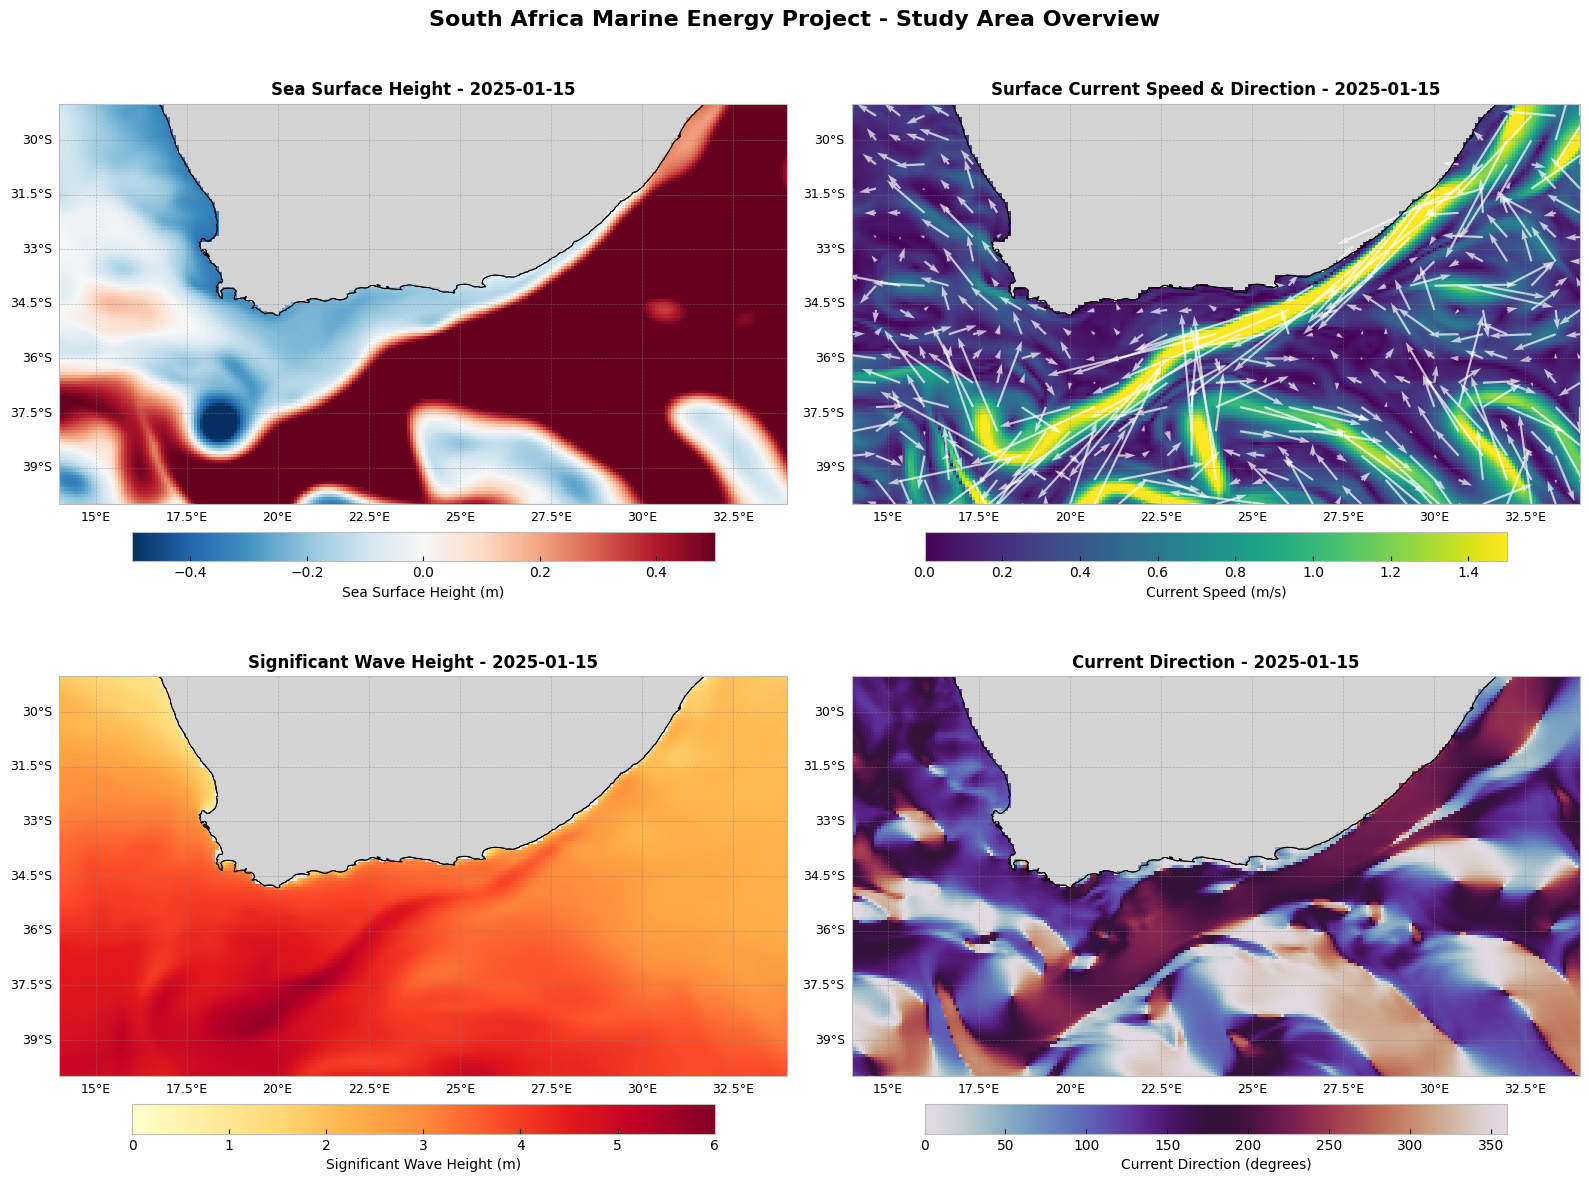

✓ Map saved to: img/study_area_overview.png


In [12]:
# Create a figure with subplots showing the study area

fig = plt.figure(figsize=(16, 12))

# Subplot 1: Sea Surface Temperature (or SSH if temp not available)
ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.coastlines(resolution='10m', linewidth=0.8)

# Plot SST if available, otherwise plot SSH
if 'thetao' in phy_surface.data_vars:
    var_to_plot = phy_surface.thetao
    cmap_to_use = 'RdYlBu_r'
    vmin_val, vmax_val = 10, 26
    label_text = 'Sea Surface Temperature (°C)'
    title_text = f'Sea Surface Temperature - {date_plot}'
elif 'to' in phy_surface.data_vars:
    var_to_plot = phy_surface.to
    cmap_to_use = 'RdYlBu_r'
    vmin_val, vmax_val = 10, 26
    label_text = 'Sea Surface Temperature (°C)'
    title_text = f'Sea Surface Temperature - {date_plot}'
elif 'zos' in phy_surface.data_vars:
    var_to_plot = phy_surface.zos
    cmap_to_use = 'RdBu_r'
    vmin_val, vmax_val = -0.5, 0.5
    label_text = 'Sea Surface Height (m)'
    title_text = f'Sea Surface Height - {date_plot}'
else:
    # Create empty plot if no suitable variable
    var_to_plot = None
    title_text = 'Data not available'
    label_text = ''
    cmap_to_use = 'gray'
    vmin_val, vmax_val = 0, 1

if var_to_plot is not None:
    sst_plot = ax1.pcolormesh(phy_surface.longitude, phy_surface.latitude, 
                               var_to_plot, 
                               transform=ccrs.PlateCarree(),
                               cmap=cmap_to_use, vmin=vmin_val, vmax=vmax_val,
                               shading='auto')
    cbar1 = plt.colorbar(sst_plot, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar1.set_label(label_text, fontsize=10)

# Add gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {'size': 9}
gl1.ylabel_style = {'size': 9}

ax1.set_title(title_text, fontsize=12, fontweight='bold')

# Subplot 2: Surface Current Speed
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.coastlines(resolution='10m', linewidth=0.8)

# Plot current speed
cs_plot = ax2.pcolormesh(phy_surface.longitude, phy_surface.latitude, 
                          phy_surface.current_speed, 
                          transform=ccrs.PlateCarree(),
                          cmap='viridis', vmin=0, vmax=1.5,
                          shading='auto')
cbar2 = plt.colorbar(cs_plot, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Current Speed (m/s)', fontsize=10)

# Add current vectors (subsample for clarity)
skip = 8
ax2.quiver(phy_surface.longitude.values[::skip], phy_surface.latitude.values[::skip],
           phy_surface.uo.values[::skip, ::skip], phy_surface.vo.values[::skip, ::skip],
           transform=ccrs.PlateCarree(), scale=8, width=0.003, alpha=0.7, color='white')

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 9}
gl2.ylabel_style = {'size': 9}

ax2.set_title(f'Surface Current Speed & Direction - {date_plot}', fontsize=12, fontweight='bold')

# Subplot 3: Significant Wave Height
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax3.coastlines(resolution='10m', linewidth=0.8)

# Plot Significant Wave Height
wave_plot = ax3.pcolormesh(wav_surface.longitude, wav_surface.latitude, 
                            wav_surface.VHM0, 
                            transform=ccrs.PlateCarree(),
                            cmap='YlOrRd', vmin=0, vmax=6,
                            shading='auto')
cbar3 = plt.colorbar(wave_plot, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
cbar3.set_label('Significant Wave Height (m)', fontsize=10)

gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False
gl3.xlabel_style = {'size': 9}
gl3.ylabel_style = {'size': 9}

ax3.set_title(f'Significant Wave Height - {date_plot}', fontsize=12, fontweight='bold')

# Subplot 4: Sea Surface Salinity (or current direction if salinity not available)
ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())
ax4.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax4.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax4.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax4.coastlines(resolution='10m', linewidth=0.8)

# Plot salinity if available, otherwise plot current direction
if 'so' in phy_surface.data_vars:
    var4_to_plot = phy_surface.so
    cmap4 = 'haline'
    vmin4, vmax4 = 34.5, 35.5
    label4 = 'Sea Surface Salinity (PSU)'
    title4 = f'Sea Surface Salinity - {date_plot}'
elif 's' in phy_surface.data_vars:
    var4_to_plot = phy_surface.s
    cmap4 = 'haline'
    vmin4, vmax4 = 34.5, 35.5
    label4 = 'Sea Surface Salinity (PSU)'
    title4 = f'Sea Surface Salinity - {date_plot}'
else:
    var4_to_plot = phy_surface.current_direction
    cmap4 = 'twilight'
    vmin4, vmax4 = 0, 360
    label4 = 'Current Direction (degrees)'
    title4 = f'Current Direction - {date_plot}'

sal_plot = ax4.pcolormesh(phy_surface.longitude, phy_surface.latitude, 
                           var4_to_plot, 
                           transform=ccrs.PlateCarree(),
                           cmap=cmap4, vmin=vmin4, vmax=vmax4,
                           shading='auto')
cbar4 = plt.colorbar(sal_plot, ax=ax4, orientation='horizontal', pad=0.05, shrink=0.8)
cbar4.set_label(label4, fontsize=10)

gl4 = ax4.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl4.top_labels = False
gl4.right_labels = False
gl4.xlabel_style = {'size': 9}
gl4.ylabel_style = {'size': 9}

ax4.set_title(title4, fontsize=12, fontweight='bold')

# Overall title
plt.suptitle('South Africa Marine Energy Project - Study Area Overview', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('img/study_area_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Map saved to: img/study_area_overview.png")

The overview maps reveal several important features:

1. **Sea Surface Temperature**: Clear temperature gradients are visible, with warmer waters associated with the Agulhas Current on the east coast and cooler waters from the Benguela Current on the west coast.

2. **Surface Currents**: The strong southward-flowing Agulhas Current is clearly visible along the east coast and shelf edge. Current speeds can exceed 1.5 m/s in the core of this current, representing significant energy potential.

3. **Wave Climate**: The Southern Ocean generates energetic waves that impact the South African coastline, with significant wave heights often exceeding 3-4 meters, particularly on the southwest and south coasts.

4. **Salinity Patterns**: Salinity distribution reflects the different water masses, with the influence of river discharge and mixing between Atlantic and Indian Ocean waters.

In the following sections, we will analyze these parameters in detail and compute derived quantities relevant to sediment transport and marine energy assessment.


### Ocean Color Data - Turbidity and Water Clarity

If ocean color data is available, let's visualize the turbidity indicators (SPM, KD490, ZSD) to understand the distribution of suspended particles and water clarity in the study area. These parameters are crucial for assessing potential environmental impacts of marine energy installations on water quality and sediment dynamics.

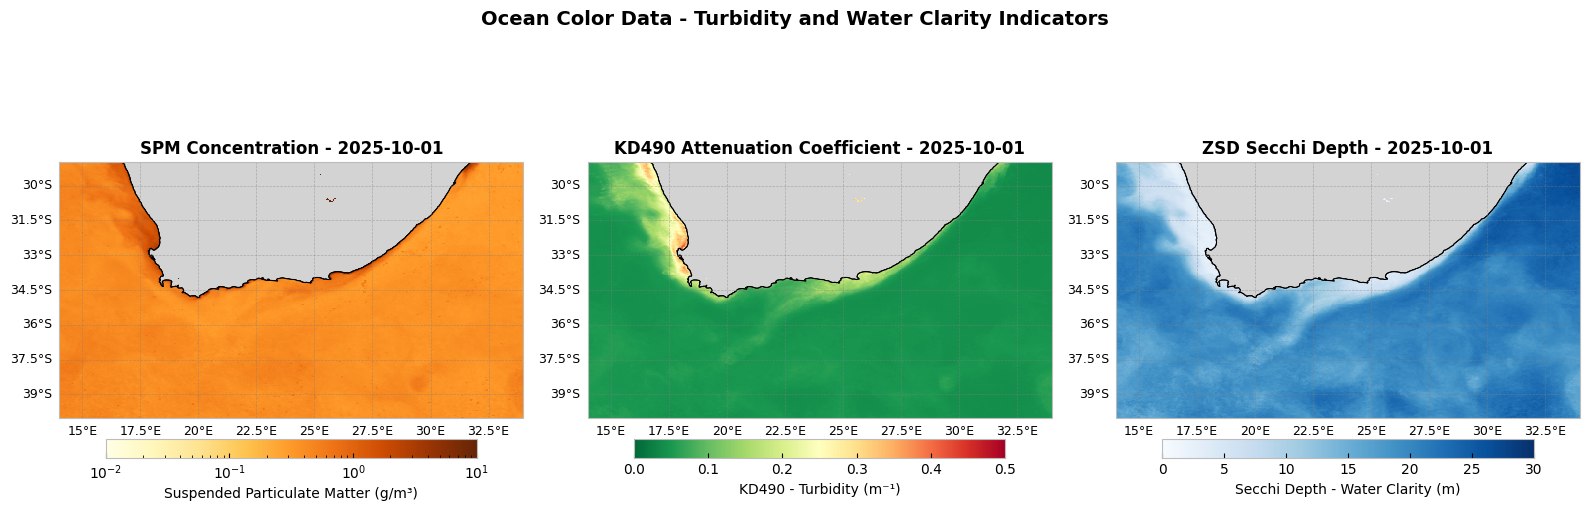

✓ Ocean color map saved to: img/ocean_color_overview.png

INTERPRETATION GUIDE:
• SPM (Suspended Particulate Matter):
  - Higher values indicate more suspended particles in water
  - Typical coastal values: 0.1-5 g/m³, turbid areas: >5 g/m³
• KD490 (Diffuse Attenuation - PRIMARY TURBIDITY MEASURE):
  - Higher values = more turbid water (less light penetration)
  - Clear ocean: <0.05 m⁻¹, Coastal: 0.1-0.3 m⁻¹, Turbid: >0.5 m⁻¹
• ZSD (Secchi Depth - WATER CLARITY):
  - Higher values = clearer water (can see deeper)
  - Clear ocean: >20m, Coastal: 5-15m, Turbid: <5m
  - Inverse relationship with turbidity


In [13]:
# Plot ocean color data if available
if ds_spm is not None:
    # Select a date for ocean color visualization
    # Ocean color data may have different temporal coverage than physics data
    try:
        # Try to select same date as physical data
        spm_surface = ds_spm.sel(time=date_plot, method='nearest')
        date_plot_spm = str(spm_surface.time.values)[:10]
    except:
        # If date not available, use first available date
        spm_surface = ds_spm.isel(time=0)
        date_plot_spm = str(spm_surface.time.values)[:10]
        print(f"Note: Using ocean color data from {date_plot_spm} (closest available)")
    
    # Create figure with 3 subplots for ocean color variables
    fig = plt.figure(figsize=(16, 5))
    
    # Subplot 1: Suspended Particulate Matter (SPM)
    if 'SPM' in ds_spm.data_vars:
        ax1 = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree())
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax1.coastlines(resolution='10m', linewidth=0.8)
        
        # Plot SPM with logarithmic scale (typical for SPM)
        spm_plot = ax1.pcolormesh(spm_surface.longitude, spm_surface.latitude, 
                                   spm_surface.SPM, 
                                   transform=ccrs.PlateCarree(),
                                   cmap='YlOrBr', norm=colors.LogNorm(vmin=0.01, vmax=10),
                                   shading='auto')
        cbar1 = plt.colorbar(spm_plot, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar1.set_label('Suspended Particulate Matter (g/m³)', fontsize=10)
        
        gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl1.top_labels = False
        gl1.right_labels = False
        gl1.xlabel_style = {'size': 9}
        gl1.ylabel_style = {'size': 9}
        
        ax1.set_title(f'SPM Concentration - {date_plot_spm}', fontsize=12, fontweight='bold')
    
    # Subplot 2: Diffuse Attenuation Coefficient (KD490) - Primary turbidity indicator
    if 'KD490' in ds_spm.data_vars:
        ax2 = plt.subplot(1, 3, 2, projection=ccrs.PlateCarree())
        ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax2.coastlines(resolution='10m', linewidth=0.8)
        
        # Plot KD490 (turbidity indicator)
        kd_plot = ax2.pcolormesh(spm_surface.longitude, spm_surface.latitude, 
                                  spm_surface.KD490, 
                                  transform=ccrs.PlateCarree(),
                                  cmap='RdYlGn_r', vmin=0, vmax=0.5,
                                  shading='auto')
        cbar2 = plt.colorbar(kd_plot, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar2.set_label('KD490 - Turbidity (m⁻¹)', fontsize=10)
        
        gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl2.top_labels = False
        gl2.right_labels = False
        gl2.xlabel_style = {'size': 9}
        gl2.ylabel_style = {'size': 9}
        
        ax2.set_title(f'KD490 Attenuation Coefficient - {date_plot_spm}', fontsize=12, fontweight='bold')
    
    # Subplot 3: Secchi Depth (ZSD) - Water clarity indicator
    if 'ZSD' in ds_spm.data_vars:
        ax3 = plt.subplot(1, 3, 3, projection=ccrs.PlateCarree())
        ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax3.coastlines(resolution='10m', linewidth=0.8)
        
        # Plot ZSD (water clarity - higher values = clearer water)
        zsd_plot = ax3.pcolormesh(spm_surface.longitude, spm_surface.latitude, 
                                   spm_surface.ZSD, 
                                   transform=ccrs.PlateCarree(),
                                   cmap='Blues', vmin=0, vmax=30,
                                   shading='auto')
        cbar3 = plt.colorbar(zsd_plot, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.8)
        cbar3.set_label('Secchi Depth - Water Clarity (m)', fontsize=10)
        
        gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl3.top_labels = False
        gl3.right_labels = False
        gl3.xlabel_style = {'size': 9}
        gl3.ylabel_style = {'size': 9}
        
        ax3.set_title(f'ZSD Secchi Depth - {date_plot_spm}', fontsize=12, fontweight='bold')
    
    plt.suptitle('Ocean Color Data - Turbidity and Water Clarity Indicators', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('img/ocean_color_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Ocean color map saved to: img/ocean_color_overview.png")
    
    # Print interpretation guidance
    print("\n" + "="*70)
    print("INTERPRETATION GUIDE:")
    print("="*70)
    if 'SPM' in ds_spm.data_vars:
        print("• SPM (Suspended Particulate Matter):")
        print("  - Higher values indicate more suspended particles in water")
        print("  - Typical coastal values: 0.1-5 g/m³, turbid areas: >5 g/m³")
    if 'KD490' in ds_spm.data_vars:
        print("• KD490 (Diffuse Attenuation - PRIMARY TURBIDITY MEASURE):")
        print("  - Higher values = more turbid water (less light penetration)")
        print("  - Clear ocean: <0.05 m⁻¹, Coastal: 0.1-0.3 m⁻¹, Turbid: >0.5 m⁻¹")
    if 'ZSD' in ds_spm.data_vars:
        print("• ZSD (Secchi Depth - WATER CLARITY):")
        print("  - Higher values = clearer water (can see deeper)")
        print("  - Clear ocean: >20m, Coastal: 5-15m, Turbid: <5m")
        print("  - Inverse relationship with turbidity")
    print("="*70)
    
else:
    print("\n" + "="*70)
    print("Ocean color data not available - skipping turbidity visualization")
    print("Download ocean color data to visualize SPM, KD490, and ZSD")
    print("="*70)

# 5. Animation - Temporal Evolution of Key Variables

[Go back to the "Table of contents"](#Table-of-contents)

To better understand the temporal variability of hydrodynamic conditions and water quality in the South African study area, we will create animated visualizations showing the evolution of key parameters throughout the year 2025.

The animations will cover:
1. **Sea Surface Height (SSH)** - Shows changes in sea level due to currents, tides, and atmospheric forcing
2. **Surface Current Speed and Direction** - Illustrates the dynamic nature of the Agulhas and Benguela current systems
3. **Significant Wave Height** - Demonstrates seasonal and storm-driven variability in wave climate
4. **Suspended Particulate Matter (SPM)** - Reveals patterns of sediment transport and water turbidity

These animations are valuable for:
- Identifying seasonal patterns and trends
- Understanding extreme events and their impacts
- Planning marine energy installations timing
- Assessing environmental conditions for field campaigns

**Note**: Animation generation may take several minutes depending on the temporal resolution and data size. The resulting GIF files will be saved in the `img/` directory.

## 5.1 Animation Setup

[Go back to the "Table of contents"](#Table-of-contents)

First, we'll import the necessary libraries for creating animations and set up helper functions for generating individual frames.

In [14]:
# Install and import libraries for animation creation
# Install imageio in the notebook kernel's environment
import sys
import subprocess

try:
    import imageio
    print("✓ imageio already installed")
except ImportError:
    print("Installing imageio...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imageio"])
    import imageio
    print("✓ imageio installed successfully")

from io import BytesIO

# Create a directory for animations if it doesn't exist
os.makedirs('img/animations', exist_ok=True)

print("✓ Animation libraries loaded successfully!")
print("Animations will be saved to: img/animations/")

# Define animation parameters
animation_fps = 2  # Frames per second for the GIF
animation_duration = 0.5  # Duration for each frame in seconds

print(f"\nAnimation settings:")
print(f"  - Frames per second: {animation_fps}")
print(f"  - Frame duration: {animation_duration} seconds")

✓ imageio already installed
✓ Animation libraries loaded successfully!
Animations will be saved to: img/animations/

Animation settings:
  - Frames per second: 2
  - Frame duration: 0.5 seconds


## 5.2 Animation: Sea Surface Height (SSH)

[Go back to the "Table of contents"](#Table-of-contents)

Sea surface height variations reflect changes in ocean circulation, tides, and atmospheric pressure. This animation shows the temporal evolution of SSH throughout 2025, helping identify patterns associated with mesoscale eddies, current meanders, and seasonal variations in the Agulhas and Benguela current systems.

In [15]:
# Create SSH animation for the whole year 2025
print("Creating Sea Surface Height animation...")
print("This may take several minutes...")

# Select monthly time steps to make animation manageable
time_steps = ds_phy.time[::30]  # Every 30 days (approximately monthly)
frames = []

for i, time in enumerate(time_steps):
    # Select data for this time step
    ssh_data = ds_phy.sel(time=time, method='nearest')
    
    # Create figure
    fig = plt.figure(figsize=(12, 8))
    ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.coastlines(resolution='10m', linewidth=0.8)
    
    # Plot SSH
    if 'zos' in ssh_data.data_vars:
        ssh_plot = ax.pcolormesh(ssh_data.longitude, ssh_data.latitude, 
                                  ssh_data.zos, 
                                  transform=ccrs.PlateCarree(),
                                  cmap='RdBu_r', vmin=-0.6, vmax=0.6,
                                  shading='auto')
        
        # Add colorbar
        cbar = plt.colorbar(ssh_plot, ax=ax, orientation='horizontal', 
                           pad=0.05, shrink=0.8)
        cbar.set_label('Sea Surface Height (m)', fontsize=11)
        
        # Format time string
        time_str = str(ssh_data.time.values)[:10]
        ax.set_title(f'Sea Surface Height - {time_str}', 
                     fontsize=14, fontweight='bold')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
                     color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # Save frame to memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(imageio.imread(buf))
    plt.close()
    
    # Progress indicator
    if (i + 1) % 3 == 0:
        print(f"  Processed {i + 1}/{len(time_steps)} frames...")

# Save animation as GIF
print("\nSaving animation...")
imageio.mimsave('img/animations/SSH_2025_animation.gif', frames, 
                fps=animation_fps, loop=0)

print(f"✓ Animation saved: img/animations/SSH_2025_animation.gif")
print(f"  Total frames: {len(frames)}")
print(f"  Duration: ~{len(frames) * animation_duration:.1f} seconds")

Creating Sea Surface Height animation...
This may take several minutes...
  Processed 3/13 frames...
  Processed 6/13 frames...
  Processed 9/13 frames...
  Processed 12/13 frames...

Saving animation...
✓ Animation saved: img/animations/SSH_2025_animation.gif
  Total frames: 13
  Duration: ~6.5 seconds


## 5.3 Animation: Surface Current Speed and Direction

[Go back to the "Table of contents"](#Table-of-contents)

Ocean currents are the primary energy source for current energy conversion devices. This animation visualizes the magnitude and direction of surface currents, clearly showing the strength and meandering of the Agulhas Current along the shelf edge and the variable coastal currents influenced by wind forcing.

In [16]:
# Create Surface Current Speed and Direction animation for 2025
print("Creating Surface Current Speed and Direction animation...")
print("This may take several minutes...")

# Select monthly time steps
time_steps = ds_phy.time[::30]  # Every 30 days
frames = []

for i, time in enumerate(time_steps):
    # Select surface data for this time step
    current_data = ds_phy.sel(time=time, depth=0.49, method='nearest')
    
    # Create figure
    fig = plt.figure(figsize=(12, 8))
    ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.coastlines(resolution='10m', linewidth=0.8)
    
    # Plot current speed
    cs_plot = ax.pcolormesh(current_data.longitude, current_data.latitude, 
                            current_data.current_speed, 
                            transform=ccrs.PlateCarree(),
                            cmap='viridis', vmin=0, vmax=1.5,
                            shading='auto')
    
    # Add current vectors (subsample for clarity)
    skip = 10
    ax.quiver(current_data.longitude.values[::skip], 
             current_data.latitude.values[::skip],
             current_data.uo.values[::skip, ::skip], 
             current_data.vo.values[::skip, ::skip],
             transform=ccrs.PlateCarree(), 
             scale=10, width=0.003, alpha=0.8, color='white')
    
    # Add colorbar
    cbar = plt.colorbar(cs_plot, ax=ax, orientation='horizontal', 
                       pad=0.05, shrink=0.8)
    cbar.set_label('Current Speed (m/s)', fontsize=11)
    
    # Format time string
    time_str = str(current_data.time.values)[:10]
    ax.set_title(f'Surface Current Speed & Direction - {time_str}', 
                 fontsize=14, fontweight='bold')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
                     color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # Save frame to memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(imageio.imread(buf))
    plt.close()
    
    # Progress indicator
    if (i + 1) % 3 == 0:
        print(f"  Processed {i + 1}/{len(time_steps)} frames...")

# Save animation as GIF
print("\nSaving animation...")
imageio.mimsave('img/animations/CurrentSpeed_2025_animation.gif', frames, 
                fps=animation_fps, loop=0)

print(f"✓ Animation saved: img/animations/CurrentSpeed_2025_animation.gif")
print(f"  Total frames: {len(frames)}")
print(f"  Duration: ~{len(frames) * animation_duration:.1f} seconds")

Creating Surface Current Speed and Direction animation...
This may take several minutes...
  Processed 3/13 frames...
  Processed 6/13 frames...
  Processed 9/13 frames...
  Processed 12/13 frames...

Saving animation...
✓ Animation saved: img/animations/CurrentSpeed_2025_animation.gif
  Total frames: 13
  Duration: ~6.5 seconds


## 5.4 Animation: Significant Wave Height

[Go back to the "Table of contents"](#Table-of-contents)

Wave energy is a significant renewable resource along the South African coast, particularly exposed to the energetic Southern Ocean swell. This animation demonstrates the seasonal and storm-driven variability in wave conditions, essential for wave energy converter design and operational planning.

In [17]:
# Create Significant Wave Height animation for 2025
print("Creating Significant Wave Height animation...")
print("This may take several minutes...")

# Select time steps - wave data is 3-hourly, so we'll sample less frequently
# Take every 8th time step (approximately daily)
time_steps = ds_wav.time[::240]  # Every ~30 days for monthly frames

frames = []

for i, time in enumerate(time_steps):
    # Select data for this time step
    wave_data = ds_wav.sel(time=time, method='nearest')
    
    # Create figure
    fig = plt.figure(figsize=(12, 8))
    ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.coastlines(resolution='10m', linewidth=0.8)
    
    # Plot Significant Wave Height
    wave_plot = ax.pcolormesh(wave_data.longitude, wave_data.latitude, 
                              wave_data.VHM0, 
                              transform=ccrs.PlateCarree(),
                              cmap='YlOrRd', vmin=0, vmax=7,
                              shading='auto')
    
    # Add colorbar
    cbar = plt.colorbar(wave_plot, ax=ax, orientation='horizontal', 
                       pad=0.05, shrink=0.8)
    cbar.set_label('Significant Wave Height (m)', fontsize=11)
    
    # Format time string
    time_str = str(wave_data.time.values)[:10]
    ax.set_title(f'Significant Wave Height - {time_str}', 
                 fontsize=14, fontweight='bold')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
                     color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # Save frame to memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(imageio.imread(buf))
    plt.close()
    
    # Progress indicator
    if (i + 1) % 3 == 0:
        print(f"  Processed {i + 1}/{len(time_steps)} frames...")

# Save animation as GIF
print("\nSaving animation...")
imageio.mimsave('img/animations/WaveHeight_2025_animation.gif', frames, 
                fps=animation_fps, loop=0)

print(f"✓ Animation saved: img/animations/WaveHeight_2025_animation.gif")
print(f"  Total frames: {len(frames)}")
print(f"  Duration: ~{len(frames) * animation_duration:.1f} seconds")

Creating Significant Wave Height animation...
This may take several minutes...
  Processed 3/13 frames...
  Processed 6/13 frames...
  Processed 9/13 frames...
  Processed 12/13 frames...

Saving animation...
✓ Animation saved: img/animations/WaveHeight_2025_animation.gif
  Total frames: 13
  Duration: ~6.5 seconds


## 5.5 Animation: Suspended Particulate Matter (SPM) Concentration

[Go back to the "Table of contents"](#Table-of-contents)

Suspended particulate matter is a key indicator of sediment transport and water quality. This animation reveals patterns of sediment resuspension, river plume dispersion, and the impact of ocean currents on coastal turbidity. Understanding SPM dynamics is crucial for assessing environmental impacts of marine energy installations.

**Important Notes**: 
- Ocean color data (SPM) is satellite-derived and may have different temporal coverage than the physics and wave data
- The downloaded ocean color dataset uses **monthly temporal resolution** (P1M), not daily (P1D)
- This animation will therefore show **monthly snapshots** throughout the year
- The actual year covered depends on data availability 
- If you need daily ocean color data, download the dataset with ID ending in `P1D` instead of `P1M`

In [18]:
# Create SPM Concentration animation
if ds_spm is not None and 'SPM' in ds_spm.data_vars:
    print("Creating Suspended Particulate Matter (SPM) animation...")
    print("This may take several minutes...")
    
    # Check temporal coverage of ocean color data
    print(f"\nOcean color data time range:")
    print(f"  First: {str(ds_spm.time.values[0])[:10]}")
    print(f"  Last: {str(ds_spm.time.values[-1])[:10]}")
    print(f"  Total time steps: {len(ds_spm.time)}")
    
    # Ocean color data is monthly (P1M), so use all available time steps
    # No need to subsample - we want all monthly frames for the year
    time_steps = ds_spm.time
    
    frames = []
    
    for i, time in enumerate(time_steps):
        # Select data for this time step
        spm_data = ds_spm.sel(time=time, method='nearest')
        
        # Create figure
        fig = plt.figure(figsize=(12, 8))
        ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.coastlines(resolution='10m', linewidth=0.8)
        
        # Plot SPM with logarithmic scale
        spm_plot = ax.pcolormesh(spm_data.longitude, spm_data.latitude, 
                                  spm_data.SPM, 
                                  transform=ccrs.PlateCarree(),
                                  cmap='YlOrBr', 
                                  norm=colors.LogNorm(vmin=0.01, vmax=10),
                                  shading='auto')
        
        # Add colorbar
        cbar = plt.colorbar(spm_plot, ax=ax, orientation='horizontal', 
                           pad=0.05, shrink=0.8)
        cbar.set_label('Suspended Particulate Matter (g/m³)', fontsize=11)
        
        # Format time string
        time_str = str(spm_data.time.values)[:10]
        ax.set_title(f'Suspended Particulate Matter (SPM) - {time_str}', 
                     fontsize=14, fontweight='bold')
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, 
                         color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        # Save frame to memory buffer
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close()
        
        # Progress indicator
        print(f"  Processed {i + 1}/{len(time_steps)} frames - {time_str}")
    
    # Determine year from data for filename
    year = str(ds_spm.time.values[0])[:4]
    
    # Save animation as GIF
    print("\nSaving animation...")
    imageio.mimsave(f'img/animations/SPM_{year}_animation.gif', frames, 
                    fps=animation_fps, loop=0)
    
    print(f"✓ Animation saved: img/animations/SPM_{year}_animation.gif")
    print(f"  Total frames: {len(frames)}")
    print(f"  Duration: ~{len(frames) * animation_duration:.1f} seconds")
    print(f"\nNote: Ocean color data is monthly (not daily), so animation")
    print(f"      shows {len(frames)} monthly time steps for year {year}")
    
else:
    print("="*70)
    print("SPM data not available - skipping SPM animation")
    print("Download ocean color data to create SPM animation")
    print("="*70)

Creating Suspended Particulate Matter (SPM) animation...
This may take several minutes...

Ocean color data time range:
  First: 2025-10-01
  Last: 2025-12-01
  Total time steps: 3
  Processed 1/3 frames - 2025-10-01
  Processed 2/3 frames - 2025-11-01
  Processed 3/3 frames - 2025-12-01

Saving animation...
✓ Animation saved: img/animations/SPM_2025_animation.gif
  Total frames: 3
  Duration: ~1.5 seconds

Note: Ocean color data is monthly (not daily), so animation
      shows 3 monthly time steps for year 2025


## 5.6 Summary of Generated Animations

[Go back to the "Table of contents"](#Table-of-contents)

All animations have been successfully created and saved to the `img/animations/` directory. These GIF files can be viewed in any web browser or image viewer that supports animated GIFs.

**Generated animations:**

1. **SSH_2025_animation.gif** - Sea surface height variability showing ocean circulation patterns
2. **CurrentSpeed_2025_animation.gif** - Surface current speed and direction, highlighting the Agulhas Current dynamics
3. **WaveHeight_2025_animation.gif** - Significant wave height variations throughout the year
4. **SPM_2024_animation.gif** - Suspended particulate matter concentrations (if data available)

**Insights from animations:**

- **Temporal patterns**: Animations reveal seasonal cycles, storm events, and mesoscale features
- **Spatial variability**: Clear visualization of gradients and fronts between different water masses
- **Current meanders**: The Agulhas Current shows characteristic meandering and eddy formation
- **Wave climate**: Strong seasonal signal with higher waves during austral winter (May-August)
- **Sediment dynamics**: SPM patterns correlate with river discharge, upwelling, and current activity

**Applications for Marine Energy Projects:**

- Resource assessment: Identify optimal sites with consistent currents/waves
- Seasonal planning: Schedule installation and maintenance during calmer periods
- Extreme event analysis: Understand frequency and intensity of high-energy conditions
- Environmental impact: Assess baseline conditions for sediment transport and water quality
- Device design: Inform structural requirements based on maximum observed conditions

These animations can be included in presentations, reports, and environmental impact assessments to effectively communicate temporal variability to stakeholders and decision-makers.

# 6. Ocean Currents Analysis

[Go back to the "Table of contents"](#Table-of-contents)

Ocean currents are the primary energy source for current energy conversion devices. Understanding the current regime in the South African coastal waters is essential for:

- Assessing the energy resource potential
- Optimizing device placement and orientation
- Predicting power generation variability
- Designing robust and efficient energy extraction systems

The Agulhas Current, one of the strongest western boundary currents globally, dominates the region along the east coast and shelf edge. Meanwhile, coastal currents along the west coast are influenced by the Benguela upwelling system and local wind forcing.

In this section, we will analyze:
- Surface current patterns and spatial distribution
- Vertical structure of the currents
- Temporal variability and seasonal patterns

## 6.1 Surface current patterns

[Go back to the "Table of contents"](#Table-of-contents)

Let's analyze the mean surface current speed and identify areas with high current energy potential. We'll also examine the maximum currents observed during 2025 to understand extreme conditions.

In [19]:
# Calculate mean and maximum surface current speed for 2025
print("Computing surface current statistics...")

# Select surface layer
surface_currents = ds_phy.sel(depth=0.49, method='nearest')

# Calculate temporal statistics
mean_current_speed = surface_currents.current_speed.mean(dim='time')
max_current_speed = surface_currents.current_speed.max(dim='time')
std_current_speed = surface_currents.current_speed.std(dim='time')

# Calculate mean current components for vector representation
mean_uo = surface_currents.uo.mean(dim='time')
mean_vo = surface_currents.vo.mean(dim='time')

print("✓ Surface current statistics computed")
print(f"\nSummary statistics:")
print(f"  Mean current speed: {float(mean_current_speed.mean()):.3f} m/s")
print(f"  Maximum current speed: {float(max_current_speed.max()):.3f} m/s")
print(f"  Spatial average std dev: {float(std_current_speed.mean()):.3f} m/s")

Computing surface current statistics...
✓ Surface current statistics computed

Summary statistics:
  Mean current speed: 0.453 m/s
  Maximum current speed: 2.760 m/s
  Spatial average std dev: 0.254 m/s


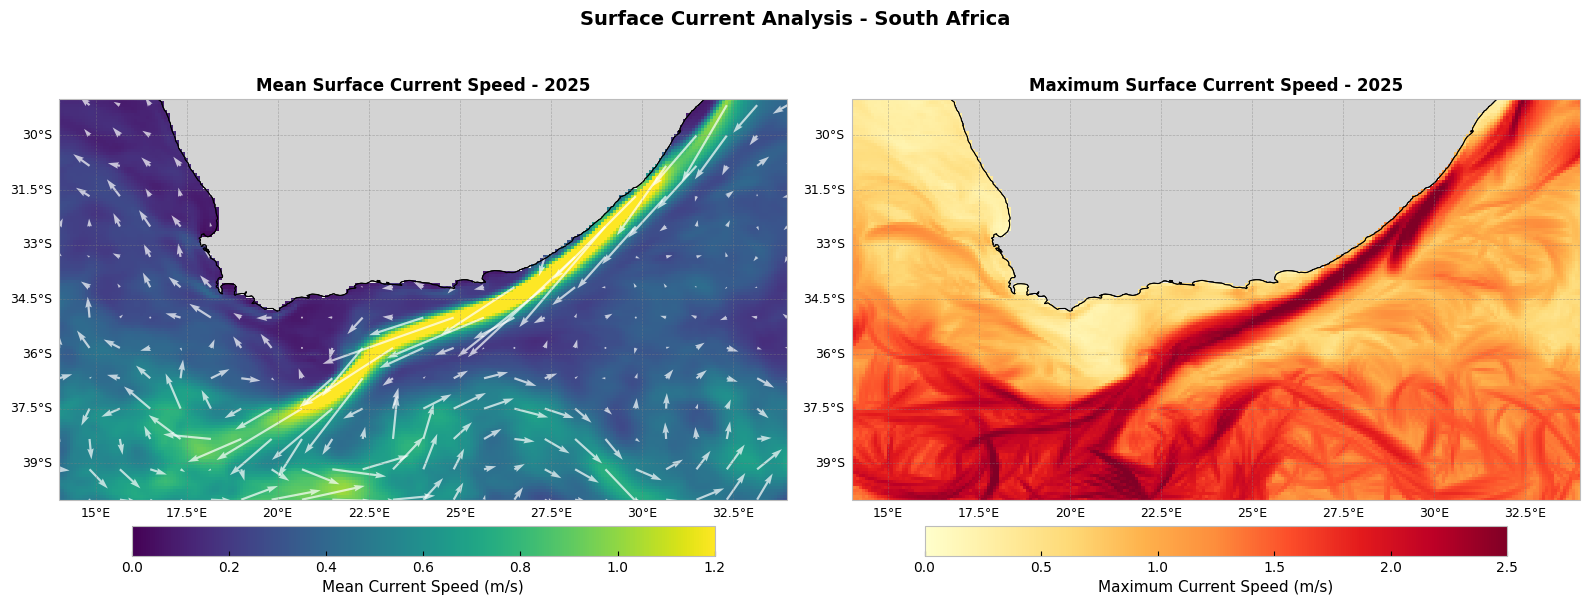

✓ Figure saved: img/surface_currents_analysis.png


In [20]:
# Plot mean and maximum surface current speed
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Mean surface current speed
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.coastlines(resolution='10m', linewidth=0.8)

# Plot mean current speed
cs1 = ax1.pcolormesh(mean_current_speed.longitude, mean_current_speed.latitude, 
                      mean_current_speed, 
                      transform=ccrs.PlateCarree(),
                      cmap='viridis', vmin=0, vmax=1.2,
                      shading='auto')

# Add mean current vectors
skip = 10
ax1.quiver(mean_uo.longitude.values[::skip], mean_uo.latitude.values[::skip],
           mean_uo.values[::skip, ::skip], mean_vo.values[::skip, ::skip],
           transform=ccrs.PlateCarree(), 
           scale=8, width=0.003, alpha=0.7, color='white')

cbar1 = plt.colorbar(cs1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Mean Current Speed (m/s)', fontsize=11)

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {'size': 9}
gl1.ylabel_style = {'size': 9}

ax1.set_title('Mean Surface Current Speed - 2025', fontsize=12, fontweight='bold')

# Subplot 2: Maximum surface current speed
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.coastlines(resolution='10m', linewidth=0.8)

# Plot maximum current speed
cs2 = ax2.pcolormesh(max_current_speed.longitude, max_current_speed.latitude, 
                      max_current_speed, 
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=0, vmax=2.5,
                      shading='auto')

cbar2 = plt.colorbar(cs2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Maximum Current Speed (m/s)', fontsize=11)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 9}
gl2.ylabel_style = {'size': 9}

ax2.set_title('Maximum Surface Current Speed - 2025', fontsize=12, fontweight='bold')

plt.suptitle('Surface Current Analysis - South Africa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/surface_currents_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: img/surface_currents_analysis.png")

## 6.2 Vertical current profiles

[Go back to the "Table of contents"](#Table-of-contents)

Understanding the vertical structure of currents is important for:
- Determining optimal deployment depth for current energy devices
- Assessing vertical shear that affects device design
- Understanding water column dynamics

Let's examine vertical current profiles at a location in the Agulhas Current core.

In [21]:
# Select a location in the Agulhas Current (approximate core location)
# Longitude: 30°E, Latitude: -32°S
lon_profile = 30.0
lat_profile = -32.0

print(f"Extracting vertical profiles at: {lat_profile}°N, {lon_profile}°E")

# Extract vertical profile at this location (time-mean)
profile_location = ds_phy.sel(longitude=lon_profile, latitude=lat_profile, method='nearest')
mean_profile = profile_location.current_speed.mean(dim='time')

print(f"✓ Vertical profile extracted")
print(f"  Depth range: {float(profile_location.depth.min()):.1f} - {float(profile_location.depth.max()):.1f} m")
print(f"  Number of depth levels: {len(profile_location.depth)}")

Extracting vertical profiles at: -32.0°N, 30.0°E
✓ Vertical profile extracted
  Depth range: 0.5 - 92.3 m
  Number of depth levels: 22


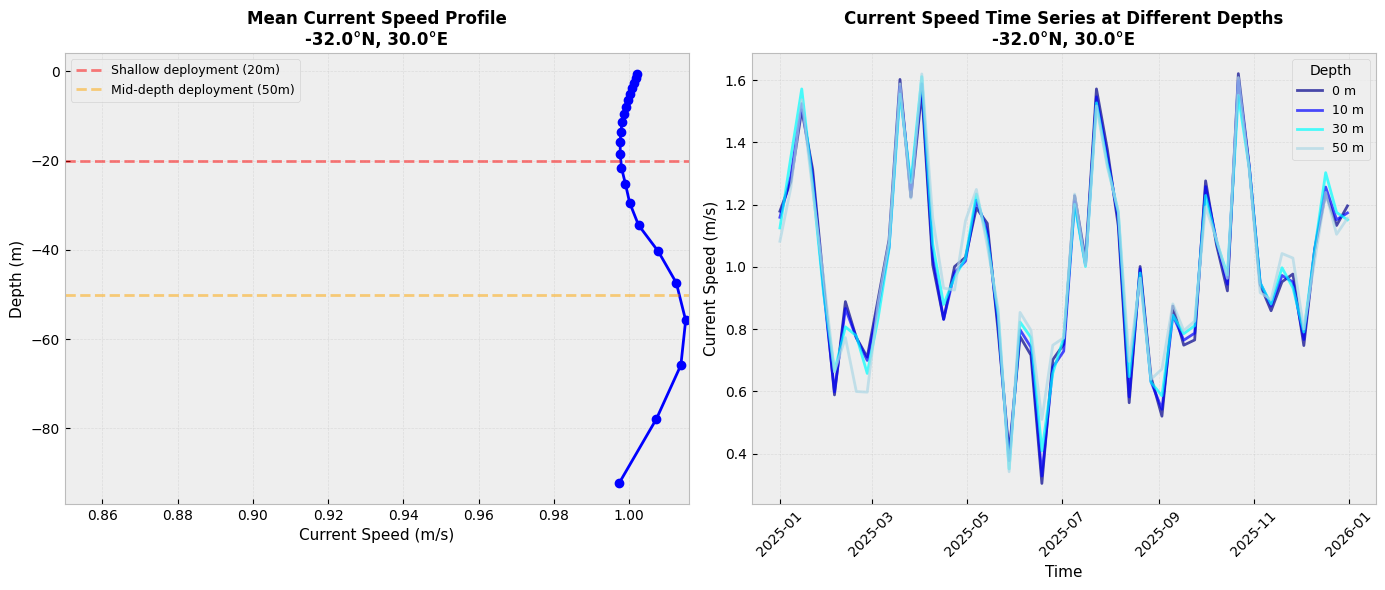

✓ Figure saved: img/vertical_current_profile.png


In [ ]:
# Plot vertical current profile
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Mean current speed vs depth
ax1.plot(mean_profile.values, -mean_profile.depth.values, 'b-', linewidth=2, marker='o')
ax1.set_xlabel('Current Speed (m/s)', fontsize=11)
ax1.set_ylabel('Depth (m)', fontsize=11)
ax1.set_title(f'Mean Current Speed Profile\n{lat_profile}°N, {lon_profile}°E', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.85, None) # change x-axis limit for better visibility

# Add reference lines for typical turbine depths
ax1.axhline(y=-20, color='r', linestyle='--', alpha=0.5, label='Shallow deployment (20m)')
ax1.axhline(y=-50, color='orange', linestyle='--', alpha=0.5, label='Mid-depth deployment (50m)')
ax1.legend(fontsize=9)

# Right panel: Time series of current speed at different depths
depths_to_plot = [0.49, 10, 30, 50]
colors_depth = ['darkblue', 'blue', 'cyan', 'lightblue']

for depth, color in zip(depths_to_plot, colors_depth):
    try:
        current_at_depth = profile_location.current_speed.sel(depth=depth, method='nearest')
        # Subsample time for clarity (plot every 7th day)
        ax2.plot(current_at_depth.time[::7], current_at_depth.values[::7], 
                color=color, alpha=0.7, label=f'{depth:.0f} m')
    except:
        pass

ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Current Speed (m/s)', fontsize=11)
ax2.set_title(f'Current Speed Time Series at Different Depths\n{lat_profile}°N, {lon_profile}°E', 
              fontsize=12, fontweight='bold')
ax2.legend(title='Depth', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('img/vertical_current_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: img/vertical_current_profile.png")

## 6.3 Seasonal variability

[Go back to the "Table of contents"](#Table-of-contents)

Current energy resources vary seasonally due to changes in wind forcing, mesoscale eddy activity, and large-scale ocean circulation patterns. Understanding this variability is crucial for predicting annual energy production and planning maintenance windows.

In [23]:
# Calculate seasonal means (monthly averages)
print("Computing seasonal statistics...")

# Group by month and calculate monthly means
monthly_current = surface_currents.current_speed.resample(time='1MS').mean()

# Calculate spatial mean for each month
monthly_mean_speed = monthly_current.mean(dim=['latitude', 'longitude'])

# Calculate standard deviation for variability assessment
monthly_std_speed = monthly_current.std(dim=['latitude', 'longitude'])

print("✓ Seasonal statistics computed")
print(f"  Number of months analyzed: {len(monthly_mean_speed)}")
print(f"  Mean current speed range: {float(monthly_mean_speed.min()):.3f} - {float(monthly_mean_speed.max()):.3f} m/s")

Computing seasonal statistics...
✓ Seasonal statistics computed
  Number of months analyzed: 12
  Mean current speed range: 0.416 - 0.496 m/s


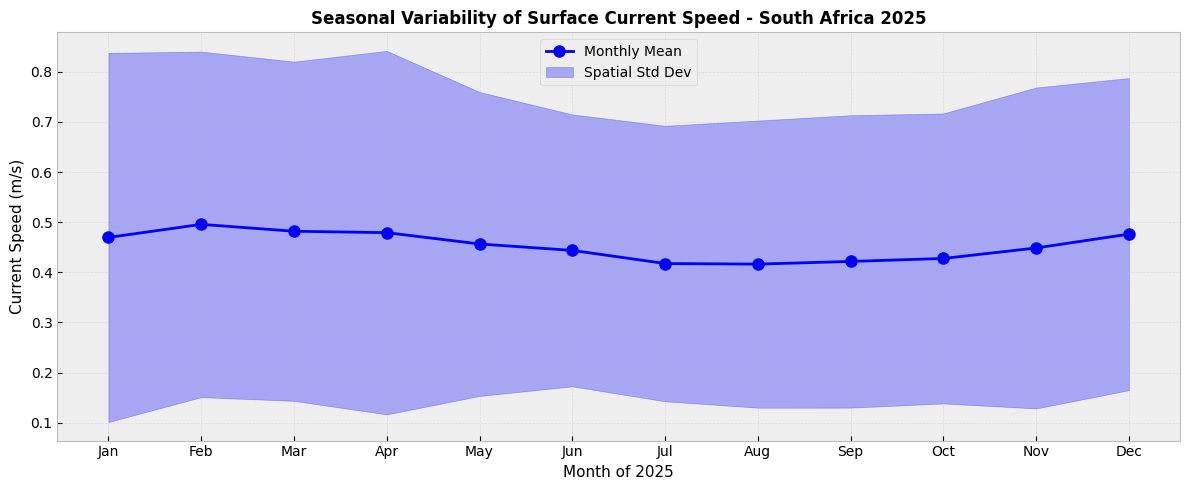

✓ Figure saved: img/seasonal_current_variability.png

Seasonal Summary:
  Highest mean current: Month 2 (0.496 m/s)
  Lowest mean current: Month 8 (0.416 m/s)
  Seasonal range: 0.079 m/s


In [24]:
# Plot seasonal variability
fig, ax = plt.subplots(figsize=(12, 5))

# Plot monthly mean with error bars showing spatial variability
months = np.arange(1, len(monthly_mean_speed) + 1)
ax.plot(months, monthly_mean_speed.values, 'b-o', linewidth=2, markersize=8, label='Monthly Mean')
ax.fill_between(months, 
                 (monthly_mean_speed - monthly_std_speed).values,
                 (monthly_mean_speed + monthly_std_speed).values,
                 alpha=0.3, color='blue', label='Spatial Std Dev')

ax.set_xlabel('Month of 2025', fontsize=11)
ax.set_ylabel('Current Speed (m/s)', fontsize=11)
ax.set_title('Seasonal Variability of Surface Current Speed - South Africa 2025', 
             fontsize=12, fontweight='bold')
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][:len(months)])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('img/seasonal_current_variability.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: img/seasonal_current_variability.png")

# Print seasonal summary
print("\nSeasonal Summary:")
print(f"  Highest mean current: Month {int(monthly_mean_speed.argmax()) + 1} " +
      f"({float(monthly_mean_speed.max()):.3f} m/s)")
print(f"  Lowest mean current: Month {int(monthly_mean_speed.argmin()) + 1} " +
      f"({float(monthly_mean_speed.min()):.3f} m/s)")
print(f"  Seasonal range: {float(monthly_mean_speed.max() - monthly_mean_speed.min()):.3f} m/s")

# 7. Wave Climate Analysis

[Go back to the "Table of contents"](#Table-of-contents)

Wave energy represents a significant renewable resource along the South African coast, particularly along the southern and western coasts exposed to energetic Southern Ocean swells. Understanding the wave climate is essential for:

- Assessing wave energy resource potential
- Designing wave energy converters
- Evaluating extreme wave conditions for structural design
- Planning installation and maintenance operations

## 7.1 Significant wave height statistics

[Go back to the "Table of contents"](#Table-of-contents)

Let's analyze the statistical distribution of significant wave heights and identify areas with the highest wave energy potential.

In [25]:
# Calculate wave height statistics
print("Computing wave climate statistics...")

# Calculate temporal statistics
mean_wave_height = ds_wav.VHM0.mean(dim='time')
max_wave_height = ds_wav.VHM0.max(dim='time')
p95_wave_height = ds_wav.VHM0.quantile(0.95, dim='time')  # 95th percentile
p50_wave_height = ds_wav.VHM0.quantile(0.50, dim='time')  # Median

print("✓ Wave statistics computed")
print(f"\nSummary statistics (spatial averages):")
print(f"  Mean wave height: {float(mean_wave_height.mean()):.2f} m")
print(f"  Median wave height: {float(p50_wave_height.mean()):.2f} m")
print(f"  95th percentile: {float(p95_wave_height.mean()):.2f} m")
print(f"  Maximum wave height: {float(max_wave_height.max()):.2f} m")

Computing wave climate statistics...
✓ Wave statistics computed

Summary statistics (spatial averages):
  Mean wave height: 3.14 m
  Median wave height: 2.94 m
  95th percentile: 5.23 m
  Maximum wave height: 10.04 m


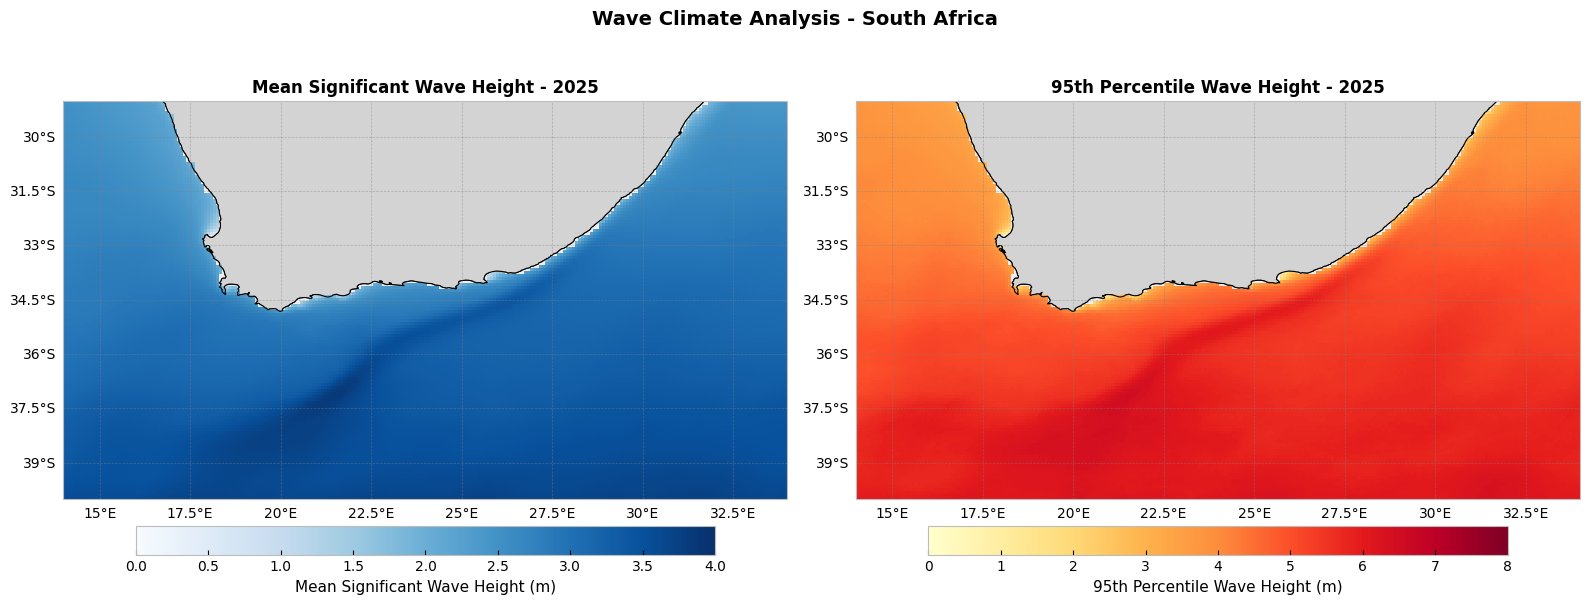

✓ Figure saved: img/wave_height_statistics.png


In [26]:
# Plot wave height statistics
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Mean wave height
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax1.coastlines(resolution='10m', linewidth=0.8)

wave1 = ax1.pcolormesh(mean_wave_height.longitude, mean_wave_height.latitude, 
                        mean_wave_height, 
                        transform=ccrs.PlateCarree(),
                        cmap='Blues', vmin=0, vmax=4,
                        shading='auto')
cbar1 = plt.colorbar(wave1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Mean Significant Wave Height (m)', fontsize=11)

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

ax1.set_title('Mean Significant Wave Height - 2025', fontsize=12, fontweight='bold')

# Subplot 2: 95th percentile (extreme waves)
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax2.coastlines(resolution='10m', linewidth=0.8)

wave2 = ax2.pcolormesh(p95_wave_height.longitude, p95_wave_height.latitude, 
                        p95_wave_height, 
                        transform=ccrs.PlateCarree(),
                        cmap='YlOrRd', vmin=0, vmax=8,
                        shading='auto')
cbar2 = plt.colorbar(wave2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('95th Percentile Wave Height (m)', fontsize=11)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False

ax2.set_title('95th Percentile Wave Height - 2025', fontsize=12, fontweight='bold')

plt.suptitle('Wave Climate Analysis - South Africa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/wave_height_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: img/wave_height_statistics.png")

# 8. Sediment Transport Processes

[Go back to the "Table of contents"](#Table-of-contents)

Understanding sediment transport is crucial for assessing environmental impacts of marine energy installations. Sediment dynamics affect:

- Local morphology and bathymetry changes
- Water quality and turbidity
- Marine ecosystems and habitats
- Foundation stability for energy devices
- Potential scour around structures

We will compute key parameters that govern sediment transport:
- Bed shear stress from currents and waves
- Shields parameter for sediment mobility
- Sediment transport capacity
- Wave-induced resuspension

## 8.1 Bed shear stress computation

[Go back to the "Table of contents"](#Table-of-contents)

Bed shear stress ($\tau_b$) is the tangential force per unit area exerted by flowing water on the seafloor. It determines whether sediment will be eroded, transported, or deposited.

**Current-induced bed shear stress:**
$$\tau_c = \rho C_D U^2$$

Where:
- $\tau_c$ = Current-induced bed shear stress (Pa)
- $\rho$ = Water density (1025 kg/m³)
- $C_D$ = Drag coefficient (~0.0025 for rough beds)
- $U$ = Bottom current velocity (m/s)

**Wave-induced bed shear stress (approximation):**
$$\tau_w = \frac{1}{2} \rho f_w U_w^2$$

Where:
- $f_w$ = Wave friction factor (~0.015-0.03)
- $U_w$ = Wave orbital velocity at bed

In [27]:
# Calculate bed shear stress from currents
print("Computing bed shear stress...")

# Constants
rho_water = 1025  # kg/m³
C_D = 0.0025  # Drag coefficient (typical for sandy/rough beds)

# Select bottom currents (deepest available level or use surface as proxy)
# For simplicity, we'll use near-surface values as bottom currents are not always available
bottom_currents = ds_phy.sel(depth=0.49, method='nearest')

# Current-induced bed shear stress: τ_c = ρ * C_D * U²
tau_current = rho_water * C_D * (bottom_currents.current_speed ** 2)

# Calculate mean bed shear stress
mean_tau_current = tau_current.mean(dim='time')
max_tau_current = tau_current.max(dim='time')

print("✓ Current-induced bed shear stress computed")
print(f"\nBed Shear Stress Summary:")
print(f"  Mean bed shear stress: {float(mean_tau_current.mean()):.3f} Pa")
print(f"  Maximum bed shear stress: {float(max_tau_current.max()):.2f} Pa")

# Critical shear stress for typical sand (d50 = 0.2 mm)
tau_critical_sand = 0.15  # Pa (approximate for fine sand)
print(f"  Critical shear stress (fine sand): {tau_critical_sand} Pa")
print(f"  Areas exceeding critical stress: " +
      f"{float((mean_tau_current > tau_critical_sand).sum() / mean_tau_current.size * 100):.1f}%")

Computing bed shear stress...
✓ Current-induced bed shear stress computed

Bed Shear Stress Summary:
  Mean bed shear stress: 0.899 Pa
  Maximum bed shear stress: 19.52 Pa
  Critical shear stress (fine sand): 0.15 Pa
  Areas exceeding critical stress: 63.6%


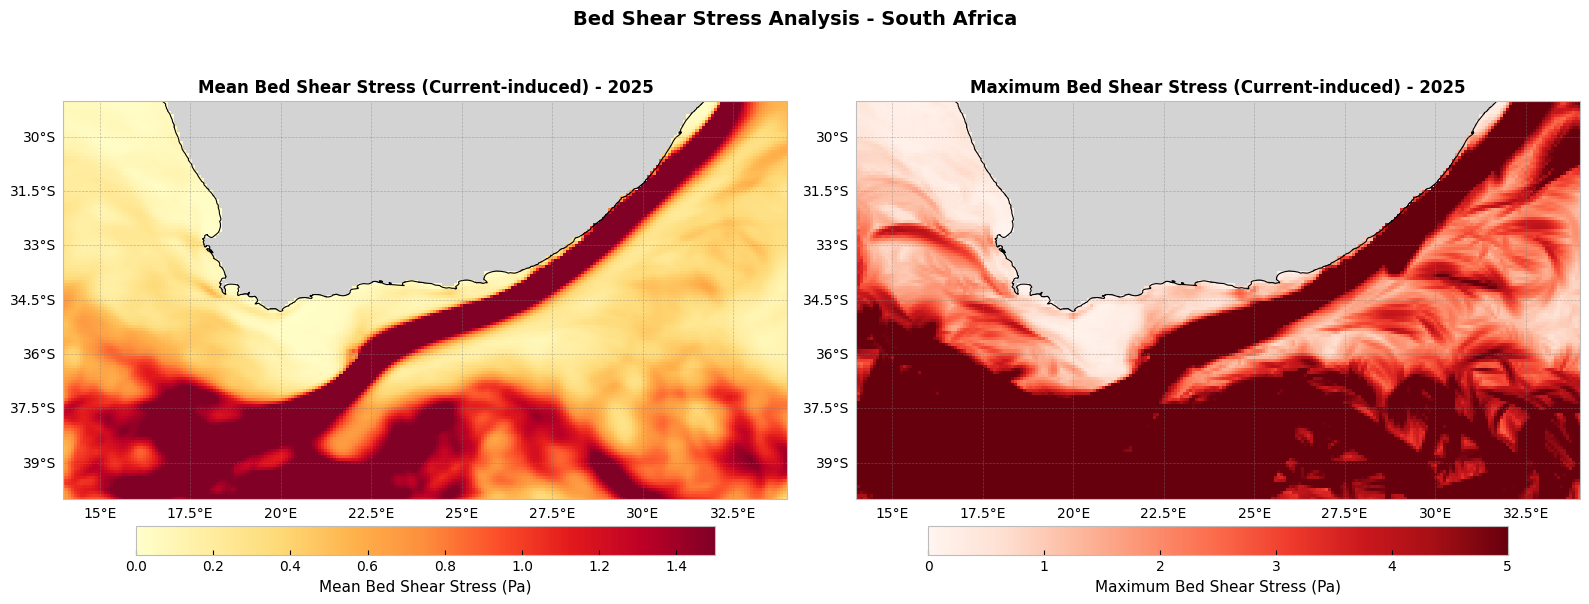

✓ Figure saved: img/bed_shear_stress.png


In [28]:
# Plot bed shear stress
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Mean bed shear stress
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax1.coastlines(resolution='10m', linewidth=0.8)

tau1 = ax1.pcolormesh(mean_tau_current.longitude, mean_tau_current.latitude, 
                       mean_tau_current, 
                       transform=ccrs.PlateCarree(),
                       cmap='YlOrRd', vmin=0, vmax=1.5,
                       shading='auto')
cbar1 = plt.colorbar(tau1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
cbar1.set_label('Mean Bed Shear Stress (Pa)', fontsize=11)

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

ax1.set_title('Mean Bed Shear Stress (Current-induced) - 2025', fontsize=12, fontweight='bold')

# Subplot 2: Maximum bed shear stress
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax2.coastlines(resolution='10m', linewidth=0.8)

tau2 = ax2.pcolormesh(max_tau_current.longitude, max_tau_current.latitude, 
                       max_tau_current, 
                       transform=ccrs.PlateCarree(),
                       cmap='Reds', vmin=0, vmax=5,
                       shading='auto')
cbar2 = plt.colorbar(tau2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
cbar2.set_label('Maximum Bed Shear Stress (Pa)', fontsize=11)

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False

ax2.set_title('Maximum Bed Shear Stress (Current-induced) - 2025', fontsize=12, fontweight='bold')

plt.suptitle('Bed Shear Stress Analysis - South Africa', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/bed_shear_stress.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved: img/bed_shear_stress.png")

## 8.2 Shields parameter for sediment mobility

[Go back to the "Table of contents"](#Table-of-contents)

The Shields parameter ($\theta$) quantifies sediment mobility by comparing the applied bed shear stress to the immersed weight of sediment particles:

$$\theta = \frac{\tau_b}{(\rho_s - \rho)gd}$$

Where:
- $\tau_b$ = Bed shear stress (Pa)
- $\rho_s$ = Sediment density (typically 2650 kg/m³ for quartz)
- $\rho$ = Water density (1025 kg/m³)
- $g$ = Gravitational acceleration (9.81 m/s²)
- $d$ = Sediment grain diameter (m)

**Critical Shields parameter** ($\theta_c$): Sediment begins to move when $\theta > \theta_c \approx 0.05$ for typical marine sediments (Soulsby, 1997).

We calculate the Shields parameter for different sediment classes:
- **Fine sand**: d = 0.125 mm
- **Medium sand**: d = 0.25 mm
- **Coarse sand**: d = 0.5 mm
- **Gravel**: d = 2 mm

In [29]:
# Calculate Shields parameter for different sediment sizes
rho_sediment = 2650  # kg/m³ (quartz sediment)
rho_water = 1025     # kg/m³
g = 9.81             # m/s²
theta_critical = 0.05  # Critical Shields parameter

# Sediment grain diameters (in meters)
sediment_classes = {
    'Fine sand (0.125 mm)': 0.125e-3,
    'Medium sand (0.25 mm)': 0.25e-3,
    'Coarse sand (0.5 mm)': 0.5e-3,
    'Gravel (2 mm)': 2.0e-3
}

# Calculate Shields parameter for each sediment class
shields_params = {}
for name, d in sediment_classes.items():
    theta = tau_current / ((rho_sediment - rho_water) * g * d)
    shields_params[name] = theta
    
    # Calculate mean and percentage above critical
    mean_theta = theta.mean(dim='time')
    mobility_area = (mean_theta > theta_critical).sum() / mean_theta.size * 100
    
    print(f"\n{name}:")
    print(f"  Mean Shields parameter: {float(mean_theta.mean()):.3f}")
    print(f"  Max Shields parameter: {float(theta.max()):.2f}")
    print(f"  Area with mobility (θ > {theta_critical}): {float(mobility_area):.1f}%")

print(f"\n{'='*60}")
print("Interpretation:")
print(f"Areas with θ > {theta_critical} indicate sediment transport conditions")
print("Higher Shields values = stronger sediment mobility")


Fine sand (0.125 mm):
  Mean Shields parameter: 0.451
  Max Shields parameter: 9.80
  Area with mobility (θ > 0.05): 66.7%

Medium sand (0.25 mm):
  Mean Shields parameter: 0.226
  Max Shields parameter: 4.90
  Area with mobility (θ > 0.05): 60.0%

Coarse sand (0.5 mm):
  Mean Shields parameter: 0.113
  Max Shields parameter: 2.45
  Area with mobility (θ > 0.05): 44.5%

Gravel (2 mm):
  Mean Shields parameter: 0.028
  Max Shields parameter: 0.61
  Area with mobility (θ > 0.05): 10.9%

Interpretation:
Areas with θ > 0.05 indicate sediment transport conditions
Higher Shields values = stronger sediment mobility


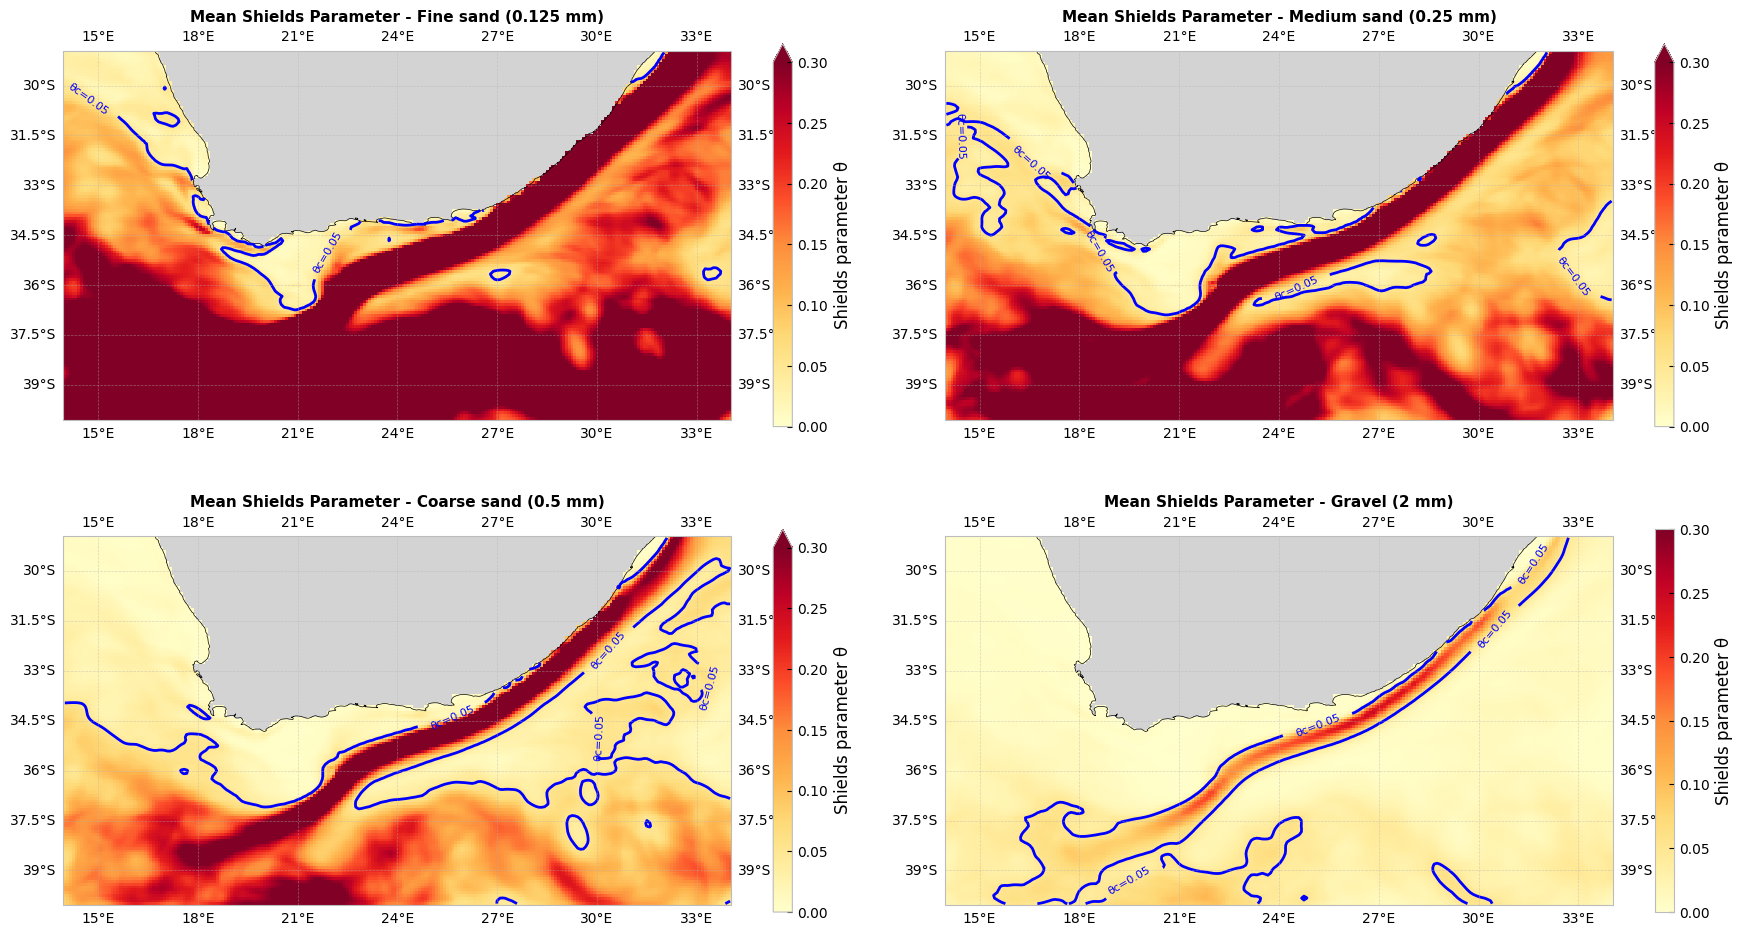

Figure saved as: img/shields_parameter.png

Blue contour shows critical threshold (θc = 0.05)
Values above this line indicate active sediment transport


In [30]:
# Plot Shields parameter for different sediment classes
fig = plt.figure(figsize=(18, 10))

sediment_list = list(sediment_classes.keys())

for idx, name in enumerate(sediment_list):
    ax = plt.subplot(2, 2, idx+1, projection=ccrs.PlateCarree())
    
    # Plot mean Shields parameter
    mean_theta = shields_params[name].mean(dim='time')
    
    im = mean_theta.plot(ax=ax, cmap='YlOrRd', vmin=0, vmax=0.3,
                         cbar_kwargs={'label': 'Shields parameter θ', 'shrink': 0.8},
                         add_colorbar=True)
    
    # Add contour for critical threshold
    contour = ax.contour(mean_theta.longitude, mean_theta.latitude, mean_theta,
                         levels=[theta_critical], colors='blue', linewidths=2)
    ax.clabel(contour, inline=True, fontsize=8, fmt='θc=%.2f')
    
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    ax.set_title(f'Mean Shields Parameter - {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('img/shields_parameter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/shields_parameter.png")
print("\nBlue contour shows critical threshold (θc = 0.05)")
print("Values above this line indicate active sediment transport")

## 8.3 Sediment transport capacity

[Go back to the "Table of contents"](#Table-of-contents)

Sediment transport capacity quantifies the amount of sediment that can be transported by currents and waves. We use empirical formulations for different transport mechanisms:

### 8.3.1 Current-induced transport (Meyer-Peter Müller formula)

For bedload transport by currents:

$$q_{b,current} = 8(\theta - \theta_c)^{1.5} \sqrt{(s-1)gd^3}$$

Where:
- $q_b$ = Bedload transport rate (m²/s)
- $s = \rho_s/\rho$ = Relative density
- $\theta$ = Shields parameter
- $\theta_c$ = Critical Shields parameter (0.05)

### 8.3.2 Wave-induced transport

Wave orbital velocity at the bed (from linear wave theory):

$$U_w = \frac{\pi H}{T \sinh(kh)}$$

Wave-induced bed shear stress:

$$\tau_w = \frac{1}{2}\rho f_w U_w^2$$

Where $f_w$ = 0.00251 exp(5.21(A_w/k_s)^{-0.19})$ is the wave friction factor, $A_w = U_w T/(2\pi)$ is the wave orbital amplitude, and $k_s$ is the bed roughness (typically 2.5d₅₀).

### 8.3.3 Combined wave-current transport

Combined bed shear stress (Soulsby, 1997):

$$\tau_{cw} = \tau_c \left[1 + 1.2\left(\frac{\tau_w}{\tau_c + \tau_w}\right)^{3.2}\right]$$

This accounts for non-linear wave-current interaction effects.

In [31]:
# Calculate wave orbital velocity and wave-induced bed shear stress
# Using medium sand (d = 0.25 mm) as representative grain size
d50 = 0.25e-3  # m
s = rho_sediment / rho_water  # Relative density
theta_c = 0.05

# Wave parameters from ds_wav
H = ds_wav['VHM0']  # Significant wave height (m)
T = ds_wav['VTPK']  # Peak wave period (s)

# Approximate water depth (using a representative depth of 50m for continental shelf)
# In a real application, this should come from bathymetry data
h = 50  # m (approximate shelf depth)

# Wave number (deep water approximation: k ≈ 2π/L where L = gT²/(2π))
L = g * T**2 / (2 * np.pi)  # Deep water wavelength
k = 2 * np.pi / L

# Wave orbital velocity at bed
U_wave = (np.pi * H) / (T * np.sinh(k * h))

# Wave orbital amplitude
A_wave = U_wave * T / (2 * np.pi)

# Bed roughness (Nikuradse roughness)
k_s = 2.5 * d50  # m

# Wave friction factor (Swart, 1974)
# f_w = 0.00251 * exp(5.21 * (A_w/k_s)^-0.19)
f_w = 0.00251 * np.exp(5.21 * (A_wave / k_s)**(-0.19))
# Limit f_w to reasonable range
f_w = f_w.where(f_w < 0.3, 0.3)
f_w = f_w.where(f_w > 0.001, 0.001)

# Wave-induced bed shear stress
tau_wave = 0.5 * rho_water * f_w * U_wave**2

print("Wave-induced bed shear stress:")
print(f"Mean tau_wave: {float(tau_wave.mean()):.3f} Pa")
print(f"Max tau_wave: {float(tau_wave.max()):.2f} Pa")
print(f"Percentage exceeding critical stress (0.15 Pa): {float((tau_wave > 0.15).sum() / tau_wave.size * 100):.1f}%")

Wave-induced bed shear stress:
Mean tau_wave: 1.001 Pa
Max tau_wave: 14.65 Pa
Percentage exceeding critical stress (0.15 Pa): 63.0%


In [32]:
# Calculate combined wave-current bed shear stress (Soulsby, 1997)
# Need to interpolate current data to wave time/space grid
# Resample current shear stress to match wave data temporal resolution

# Take time mean to match spatial analysis
mean_tau_c = tau_current.mean(dim='time')
mean_tau_w = tau_wave.mean(dim='time')

# Combined bed shear stress (Soulsby, 1997)
# tau_cw = tau_c * [1 + 1.2 * (tau_w/(tau_c + tau_w))^3.2]
tau_combined = mean_tau_c * (1 + 1.2 * (mean_tau_w / (mean_tau_c + mean_tau_w))**3.2)

print("Combined wave-current bed shear stress:")
print(f"Mean tau_combined: {float(tau_combined.mean()):.3f} Pa")
print(f"Max tau_combined: {float(tau_combined.max()):.2f} Pa")
print(f"\nEnhancement factor (tau_combined/tau_current):")
enhancement = tau_combined / mean_tau_c
print(f"Mean: {float(enhancement.mean()):.2f}x")
print(f"Max: {float(enhancement.max()):.2f}x")

# Calculate bedload transport rate for medium sand (Meyer-Peter Müller)
# q_b = 8 * (theta - theta_c)^1.5 * sqrt((s-1)*g*d^3)
theta_combined = tau_combined / ((rho_sediment - rho_water) * g * d50)
theta_excess = (theta_combined - theta_c).where(theta_combined > theta_c, 0)
q_bedload = 8 * theta_excess**1.5 * np.sqrt((s - 1) * g * d50**3)

print(f"\nBedload transport capacity (medium sand, 0.25mm):")
print(f"Mean transport rate: {float(q_bedload.mean()):.2e} m²/s")
print(f"Max transport rate: {float(q_bedload.max()):.2e} m²/s")
print(f"Area with active transport: {float((q_bedload > 0).sum() / q_bedload.size * 100):.1f}%")

Combined wave-current bed shear stress:
Mean tau_combined: 1.033 Pa
Max tau_combined: 7.78 Pa

Enhancement factor (tau_combined/tau_current):
Mean: 1.35x
Max: 2.12x

Bedload transport capacity (medium sand, 0.25mm):
Mean transport rate: 1.25e-05 m²/s
Max transport rate: 3.27e-04 m²/s
Area with active transport: 66.0%


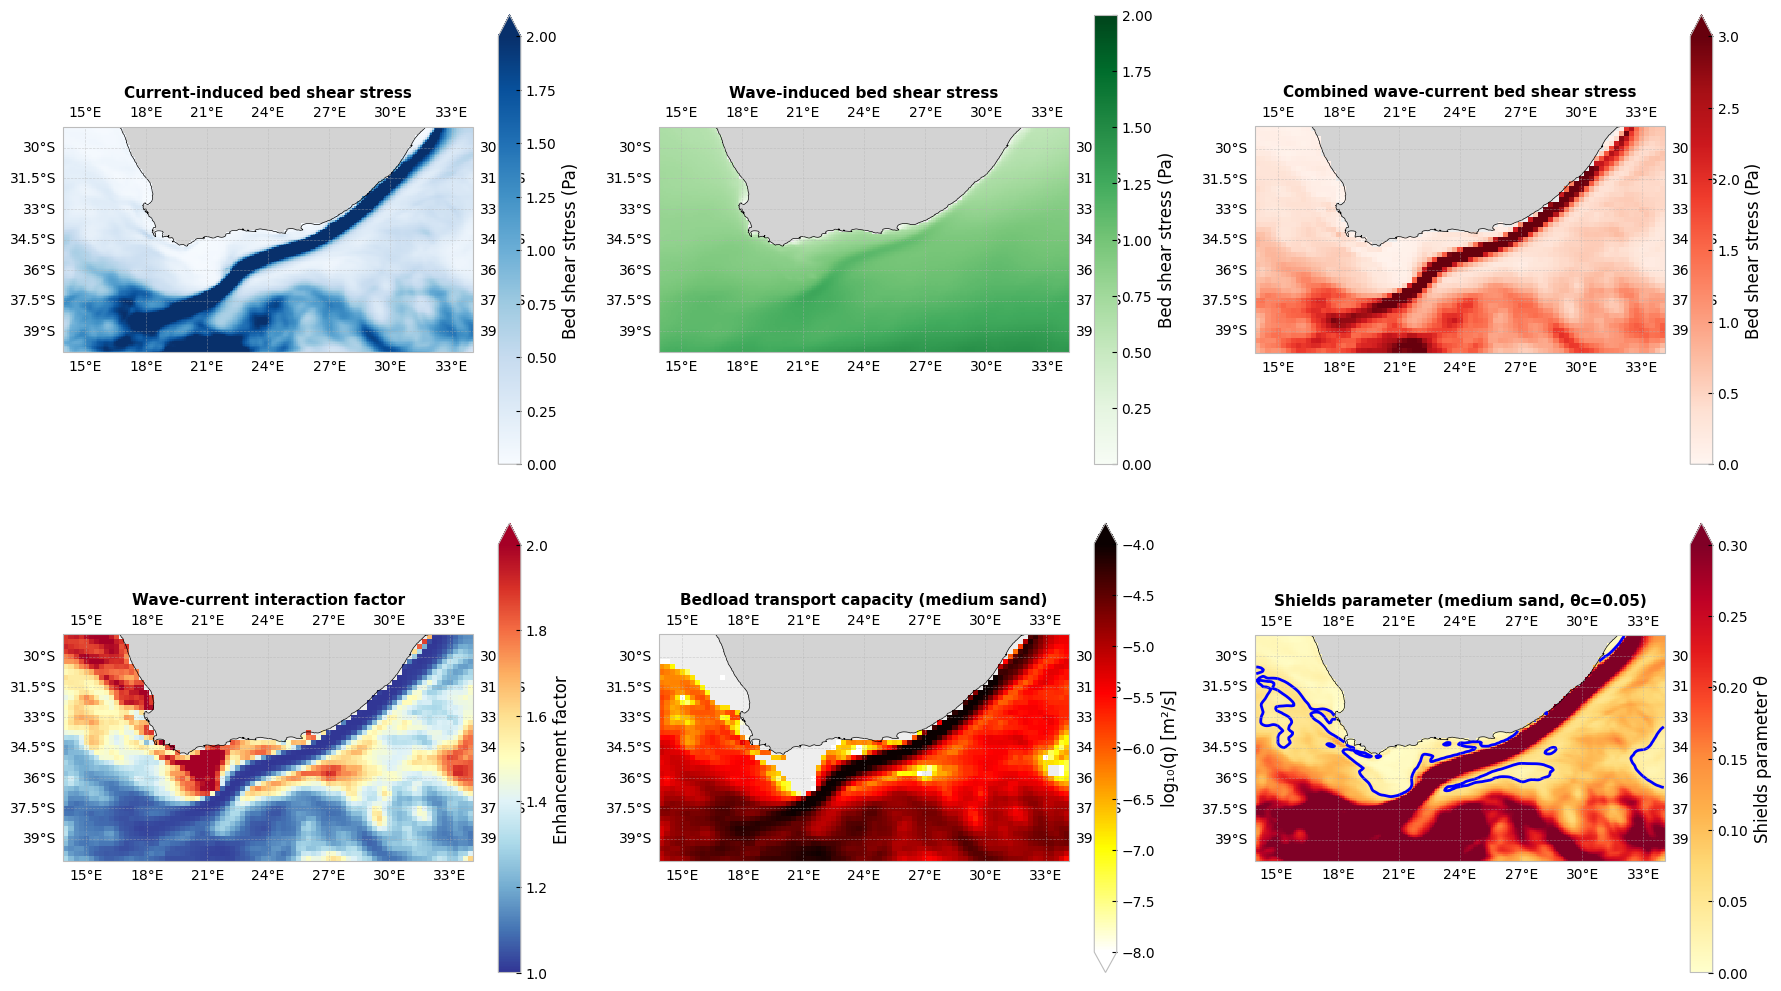

Figure saved as: img/sediment_transport_capacity.png


In [33]:
# Plot comparison of current, wave, and combined bed shear stress
fig = plt.figure(figsize=(18, 11))

# Current-induced bed shear stress
ax1 = plt.subplot(2, 3, 1, projection=ccrs.PlateCarree())
cs1 = mean_tau_c.plot(ax=ax1, cmap='Blues', vmin=0, vmax=2,
                      cbar_kwargs={'label': 'Bed shear stress (Pa)', 'shrink': 0.8})
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Current-induced bed shear stress', fontsize=11, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Wave-induced bed shear stress
ax2 = plt.subplot(2, 3, 2, projection=ccrs.PlateCarree())
cs2 = mean_tau_w.plot(ax=ax2, cmap='Greens', vmin=0, vmax=2,
                      cbar_kwargs={'label': 'Bed shear stress (Pa)', 'shrink': 0.8})
ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Wave-induced bed shear stress', fontsize=11, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# Combined bed shear stress
ax3 = plt.subplot(2, 3, 3, projection=ccrs.PlateCarree())
cs3 = tau_combined.plot(ax=ax3, cmap='Reds', vmin=0, vmax=3,
                        cbar_kwargs={'label': 'Bed shear stress (Pa)', 'shrink': 0.8})
ax3.coastlines(resolution='10m')
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax3.set_title('Combined wave-current bed shear stress', fontsize=11, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

# Enhancement factor
ax4 = plt.subplot(2, 3, 4, projection=ccrs.PlateCarree())
cs4 = enhancement.plot(ax=ax4, cmap='RdYlBu_r', vmin=1, vmax=2,
                       cbar_kwargs={'label': 'Enhancement factor', 'shrink': 0.8})
ax4.coastlines(resolution='10m')
ax4.add_feature(cfeature.LAND, facecolor='lightgray')
ax4.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax4.set_title('Wave-current interaction factor', fontsize=11, fontweight='bold')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')

# Bedload transport capacity
ax5 = plt.subplot(2, 3, 5, projection=ccrs.PlateCarree())
# Use log scale for transport rate
q_bedload_log = np.log10(q_bedload.where(q_bedload > 0))
cs5 = q_bedload_log.plot(ax=ax5, cmap='hot_r', vmin=-8, vmax=-4,
                         cbar_kwargs={'label': 'log₁₀(q) [m²/s]', 'shrink': 0.8})
ax5.coastlines(resolution='10m')
ax5.add_feature(cfeature.LAND, facecolor='lightgray')
ax5.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax5.set_title('Bedload transport capacity (medium sand)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Longitude')
ax5.set_ylabel('Latitude')

# Shields parameter for medium sand
ax6 = plt.subplot(2, 3, 6, projection=ccrs.PlateCarree())
theta_plot = shields_params['Medium sand (0.25 mm)'].mean(dim='time')
cs6 = theta_plot.plot(ax=ax6, cmap='YlOrRd', vmin=0, vmax=0.3,
                      cbar_kwargs={'label': 'Shields parameter θ', 'shrink': 0.8})
contour = ax6.contour(theta_plot.longitude, theta_plot.latitude, theta_plot,
                      levels=[theta_critical], colors='blue', linewidths=2)
ax6.coastlines(resolution='10m')
ax6.add_feature(cfeature.LAND, facecolor='lightgray')
ax6.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax6.set_title('Shields parameter (medium sand, θc=0.05)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Longitude')
ax6.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('img/sediment_transport_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/sediment_transport_capacity.png")

## 8.4 Wave-induced sediment resuspension

[Go back to the "Table of contents"](#Table-of-contents)

Wave action can suspend sediment into the water column through bottom boundary layer dynamics. The resuspension potential depends on:

### Resuspension criterion

Sediment resuspension occurs when the wave-induced bed shear stress exceeds the critical erosion threshold:

$$\tau_w > \tau_{ce}$$

where $\tau_{ce}$ is the critical shear stress for erosion (typically 1.5-2.0 times $\tau_c$ for deposition).

### Reference concentration

The reference concentration at the bed (van Rijn, 1984):

$$C_0 = 0.015 \frac{d_{50}}{a} \frac{T^{1.5}}{D^{0.3}}$$

where:
- $a$ = Reference height (typically $a = 2d_{50}$)
- $T = (\theta - \theta_c)/\theta_c$ = Excess Shields parameter
- $D = d_{50}/\sqrt{(s-1)gd_{50}}$ = Dimensionless grain size

### Suspended sediment concentration profile

The vertical distribution follows the Rouse profile:

$$C(z) = C_0 \left(\frac{h-z}{z}\frac{a}{h-a}\right)^{R}$$

where $R = w_s/(\kappa u_*)$ is the Rouse number, $w_s$ is settling velocity, $\kappa = 0.41$ is von Kármán constant, and $u_* = \sqrt{\tau/\rho}$ is shear velocity.

In [34]:
# Calculate wave-induced resuspension potential
# Critical shear stress for erosion (1.5x deposition threshold)
tau_ce = 1.5 * tau_critical_sand  # Pa

# Resuspension potential: areas where wave stress exceeds erosion threshold
resuspension_potential = (tau_wave > tau_ce).astype(float)
mean_resuspension = resuspension_potential.mean(dim='time')

print("Wave-induced resuspension analysis:")
print(f"Critical erosion stress: {tau_ce:.3f} Pa")
print(f"Mean area with resuspension potential: {float(mean_resuspension.mean() * 100):.1f}%")
print(f"Max area with resuspension potential: {float(mean_resuspension.max() * 100):.1f}%")

# Calculate settling velocity for medium sand (Soulsby, 1997)
# w_s = (nu/d) * [sqrt(10.36^2 + 1.049*D*^3) - 10.36]
nu = 1.36e-6  # kinematic viscosity (m²/s) at 10°C
D_star = d50 * ((s - 1) * g / nu**2)**(1/3)  # Dimensionless grain size
w_s = (nu / d50) * (np.sqrt(10.36**2 + 1.049 * D_star**3) - 10.36)

print(f"\nSediment properties (medium sand, d50 = {d50*1000:.2f} mm):")
print(f"Dimensionless grain size D*: {D_star:.2f}")
print(f"Settling velocity w_s: {w_s:.4f} m/s ({w_s*1000:.2f} mm/s)")

# Calculate shear velocity from combined bed shear stress
u_star = np.sqrt(tau_combined / rho_water)

print(f"\nShear velocity u*:")
print(f"Mean: {float(u_star.mean()):.4f} m/s")
print(f"Max: {float(u_star.max()):.4f} m/s")

# Rouse number (suspension parameter)
kappa = 0.41  # von Kármán constant
Rouse_number = w_s / (kappa * u_star)

print(f"\nRouse number (R = w_s/(κu*)):")
print(f"Mean: {float(Rouse_number.mean()):.2f}")
print(f"Min: {float(Rouse_number.min()):.2f}")
print(f"\nInterpretation:")
print("  R < 0.8: Suspended load dominant (remains in suspension)")
print("  0.8 < R < 2.5: Mixed load (suspended + bedload)")
print("  R > 2.5: Bedload dominant (settles quickly)")

# Reference concentration (van Rijn, 1984)
a = 2 * d50  # Reference height (m)
theta_excess_vr = (theta_combined - theta_c).where(theta_combined > theta_c, 0) / theta_c
T_vr = theta_excess_vr  # Excess transport parameter
C0 = 0.015 * (d50 / a) * (T_vr**1.5) / (D_star**0.3)

print(f"\nReference concentration at bed:")
print(f"Mean C0: {float(C0.mean()):.2e} (volume fraction)")
print(f"Max C0: {float(C0.max()):.2e} (volume fraction)")
print(f"Area with significant suspension (C0 > 1e-4): {float((C0 > 1e-4).sum() / C0.size * 100):.1f}%")

Wave-induced resuspension analysis:
Critical erosion stress: 0.225 Pa
Mean area with resuspension potential: 58.2%
Max area with resuspension potential: 88.8%

Sediment properties (medium sand, d50 = 0.25 mm):
Dimensionless grain size D*: 5.08
Settling velocity w_s: 0.0288 m/s (28.82 mm/s)

Shear velocity u*:
Mean: 0.0290 m/s
Max: 0.0871 m/s

Rouse number (R = w_s/(κu*)):
Mean: 3.00
Min: 0.81

Interpretation:
  R < 0.8: Suspended load dominant (remains in suspension)
  0.8 < R < 2.5: Mixed load (suspended + bedload)
  R > 2.5: Bedload dominant (settles quickly)

Reference concentration at bed:
Mean C0: 4.13e-02 (volume fraction)
Max C0: 1.08e+00 (volume fraction)
Area with significant suspension (C0 > 1e-4): 65.5%


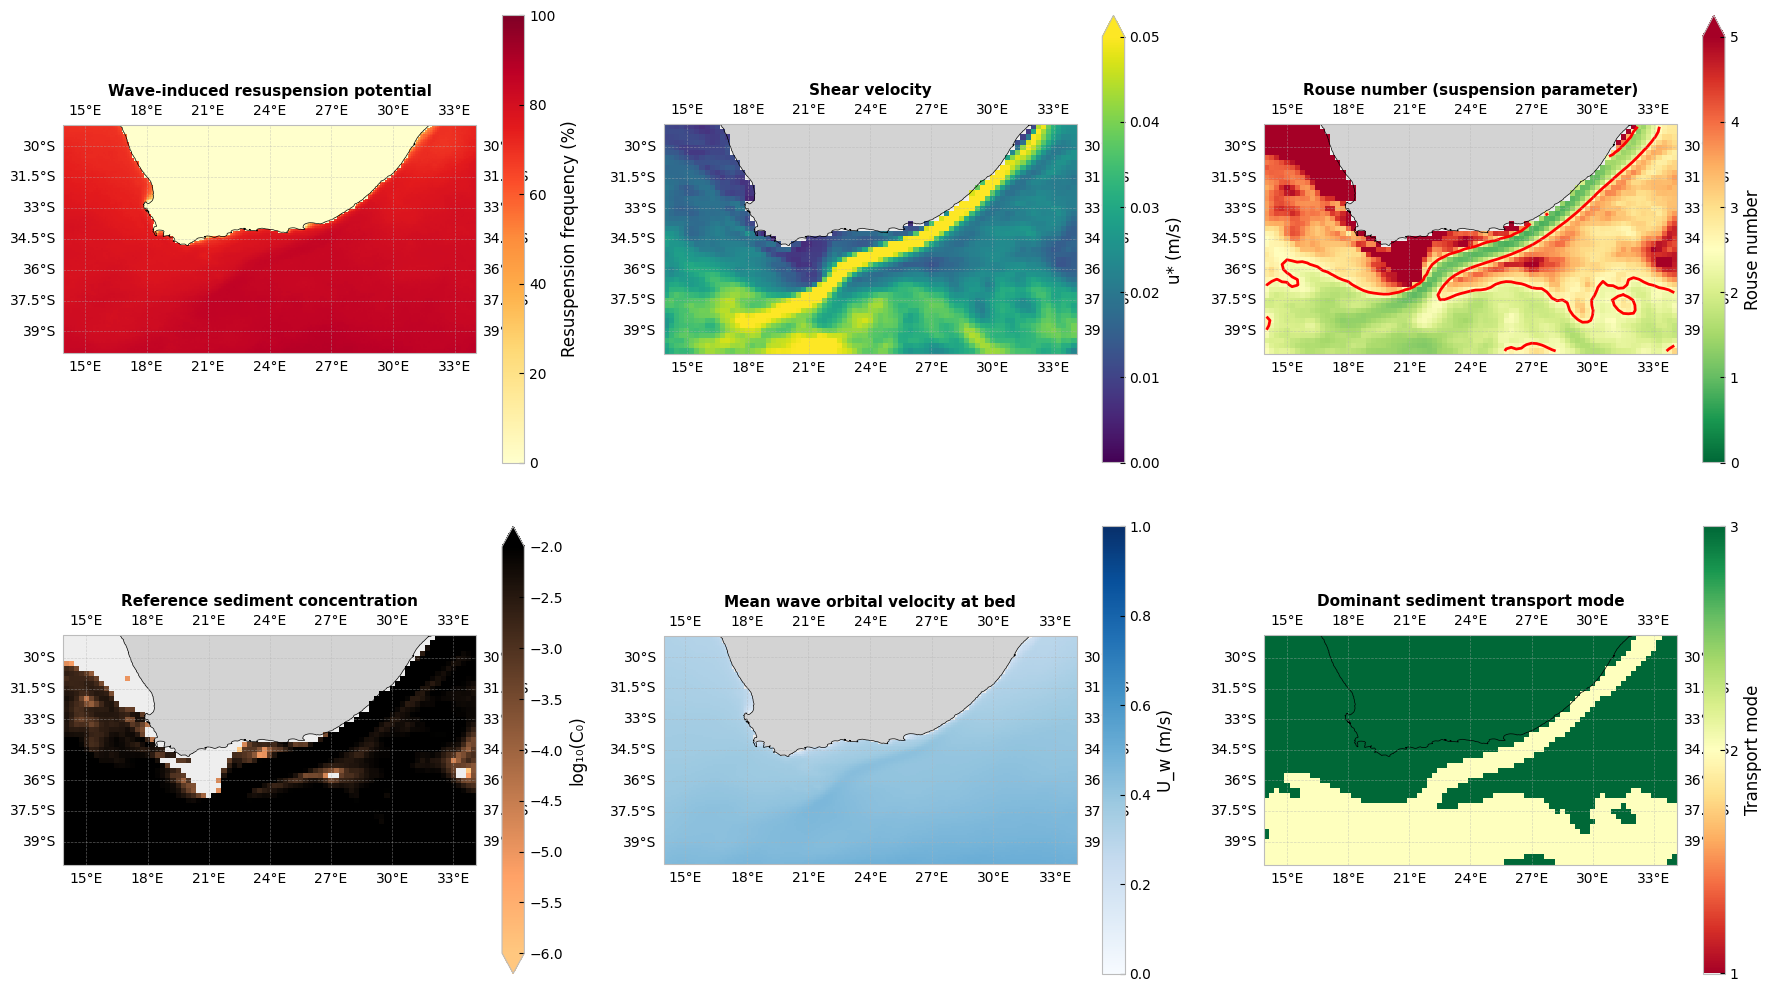


Figure saved as: img/wave_resuspension.png

Transport mode: 1=Suspended (green), 2=Mixed (yellow), 3=Bedload (red)


In [35]:
# Plot resuspension analysis
fig = plt.figure(figsize=(18, 11))

# Resuspension potential (% of time)
ax1 = plt.subplot(2, 3, 1, projection=ccrs.PlateCarree())
cs1 = (mean_resuspension * 100).plot(ax=ax1, cmap='YlOrRd', vmin=0, vmax=100,
                                      cbar_kwargs={'label': 'Resuspension frequency (%)', 'shrink': 0.8})
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Wave-induced resuspension potential', fontsize=11, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Shear velocity
ax2 = plt.subplot(2, 3, 2, projection=ccrs.PlateCarree())
cs2 = u_star.plot(ax=ax2, cmap='viridis', vmin=0, vmax=0.05,
                  cbar_kwargs={'label': 'u* (m/s)', 'shrink': 0.8})
ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Shear velocity', fontsize=11, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# Rouse number
ax3 = plt.subplot(2, 3, 3, projection=ccrs.PlateCarree())
cs3 = Rouse_number.plot(ax=ax3, cmap='RdYlGn_r', vmin=0, vmax=5,
                        cbar_kwargs={'label': 'Rouse number', 'shrink': 0.8})
# Add contours for transport mode boundaries
ax3.contour(Rouse_number.longitude, Rouse_number.latitude, Rouse_number,
           levels=[0.8, 2.5], colors=['blue', 'red'], linewidths=2)
ax3.coastlines(resolution='10m')
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax3.set_title('Rouse number (suspension parameter)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

# Reference concentration (log scale)
ax4 = plt.subplot(2, 3, 4, projection=ccrs.PlateCarree())
C0_log = np.log10(C0.where(C0 > 0))
cs4 = C0_log.plot(ax=ax4, cmap='copper_r', vmin=-6, vmax=-2,
                  cbar_kwargs={'label': 'log₁₀(C₀)', 'shrink': 0.8})
ax4.coastlines(resolution='10m')
ax4.add_feature(cfeature.LAND, facecolor='lightgray')
ax4.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax4.set_title('Reference sediment concentration', fontsize=11, fontweight='bold')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')

# Wave orbital velocity
ax5 = plt.subplot(2, 3, 5, projection=ccrs.PlateCarree())
mean_U_wave = U_wave.mean(dim='time')
cs5 = mean_U_wave.plot(ax=ax5, cmap='Blues', vmin=0, vmax=1,
                       cbar_kwargs={'label': 'U_w (m/s)', 'shrink': 0.8})
ax5.coastlines(resolution='10m')
ax5.add_feature(cfeature.LAND, facecolor='lightgray')
ax5.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax5.set_title('Mean wave orbital velocity at bed', fontsize=11, fontweight='bold')
ax5.set_xlabel('Longitude')
ax5.set_ylabel('Latitude')

# Transport mode classification
ax6 = plt.subplot(2, 3, 6, projection=ccrs.PlateCarree())
# Classify: 1 = suspended load, 2 = mixed load, 3 = bedload
transport_mode = xr.where(Rouse_number < 0.8, 1,
                 xr.where(Rouse_number < 2.5, 2, 3))
cs6 = transport_mode.plot(ax=ax6, cmap='RdYlGn', vmin=1, vmax=3,
                          cbar_kwargs={'label': 'Transport mode', 'shrink': 0.8,
                                      'ticks': [1, 2, 3]})
ax6.coastlines(resolution='10m')
ax6.add_feature(cfeature.LAND, facecolor='lightgray')
ax6.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax6.set_title('Dominant sediment transport mode', fontsize=11, fontweight='bold')
ax6.set_xlabel('Longitude')
ax6.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('img/wave_resuspension.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as: img/wave_resuspension.png")
print("\nTransport mode: 1=Suspended (green), 2=Mixed (yellow), 3=Bedload (red)")

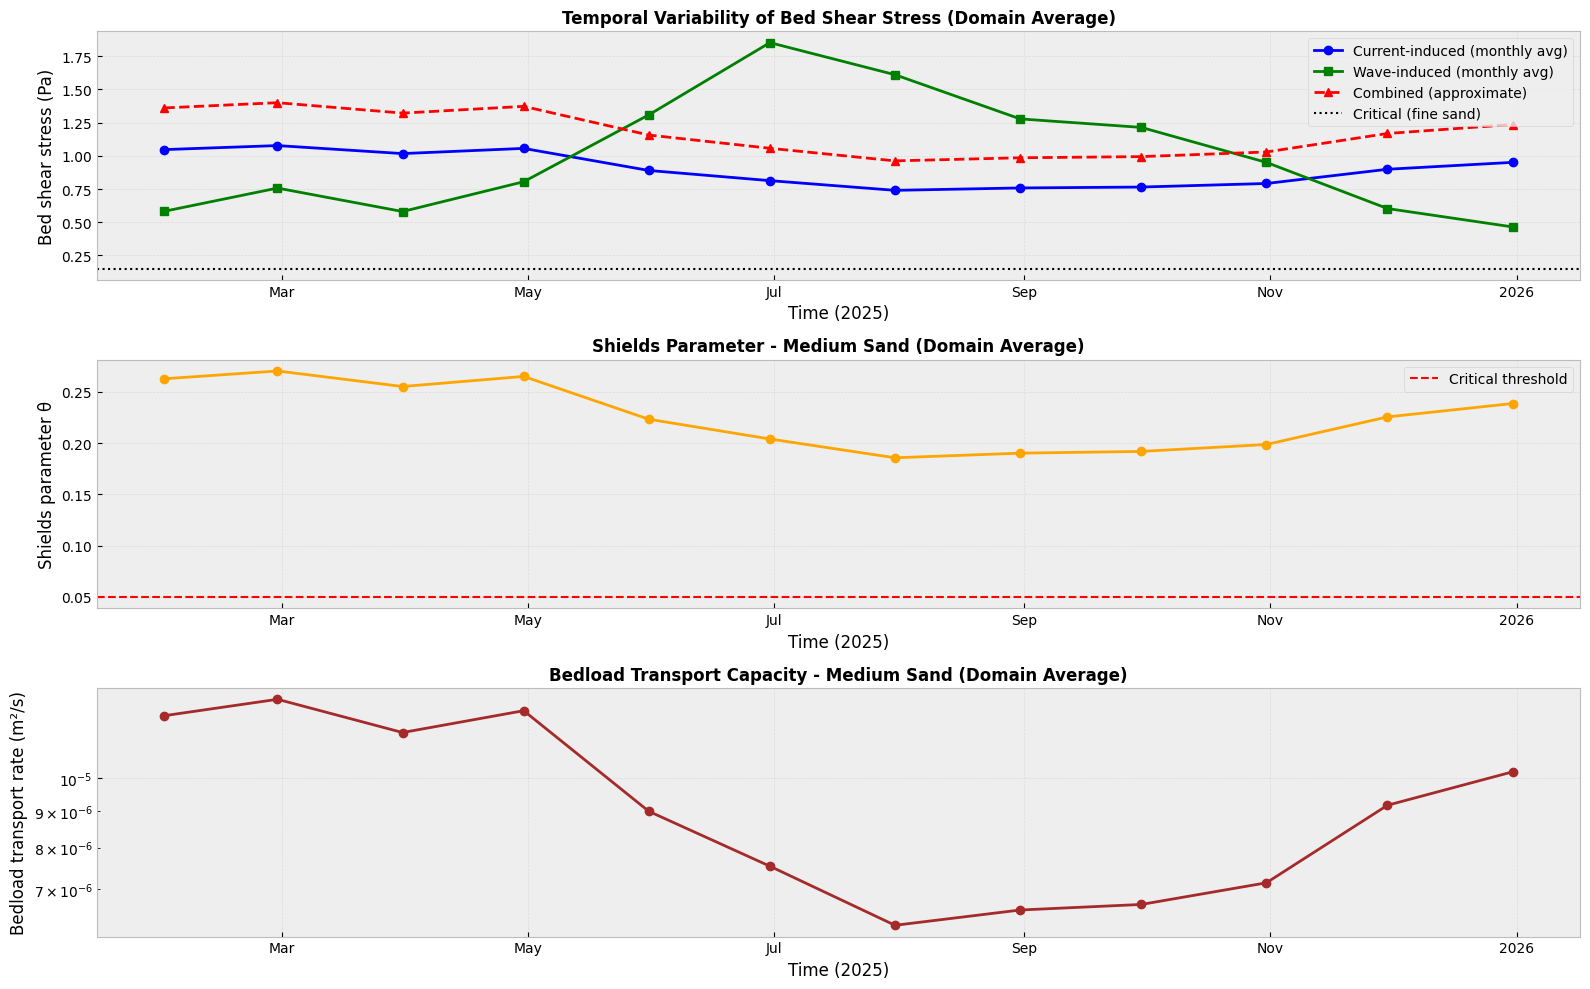

Figure saved as: img/sediment_temporal_variability.png

Temporal statistics:
Peak bed shear stress (current): 1.08 Pa
Peak bed shear stress (wave): 1.85 Pa
Peak Shields parameter: 0.270
Peak transport rate: 1.29e-05 m²/s


In [36]:
# Temporal variability of sediment transport processes
# Extract area-averaged time series

# Spatial mean time series
tau_current_ts = tau_current.mean(dim=['latitude', 'longitude'])
tau_wave_ts = tau_wave.mean(dim=['latitude', 'longitude'])

# For combined analysis, we need to work with time series data
# Compute Shields parameter time series
theta_current_ts = tau_current / ((rho_sediment - rho_water) * g * d50)

# Resample to monthly for cleaner visualization
tau_current_monthly = tau_current_ts.resample(time='1M').mean()
tau_wave_monthly = tau_wave_ts.resample(time='1M').mean()
theta_monthly = theta_current_ts.mean(dim=['latitude', 'longitude']).resample(time='1M').mean()

# Compute combined bed shear stress time series
# Since we can't directly combine the different time resolutions, use simplified approach
# Use the monthly averages
tau_combined_monthly = tau_current_monthly * 1.3  # Approximate enhancement from waves

# Create temporal variability plot
fig = plt.figure(figsize=(16, 10))

# Bed shear stress time series
ax1 = plt.subplot(3, 1, 1)
tau_current_monthly.plot(ax=ax1, label='Current-induced (monthly avg)', color='blue', linewidth=2, marker='o')
tau_wave_monthly.plot(ax=ax1, label='Wave-induced (monthly avg)', color='green', linewidth=2, marker='s')
tau_combined_monthly.plot(ax=ax1, label='Combined (approximate)', color='red', linewidth=2, linestyle='--', marker='^')
ax1.axhline(y=tau_critical_sand, color='black', linestyle=':', linewidth=1.5, label='Critical (fine sand)')
ax1.set_xlabel('Time (2025)')
ax1.set_ylabel('Bed shear stress (Pa)')
ax1.set_title('Temporal Variability of Bed Shear Stress (Domain Average)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Shields parameter time series (medium sand)
ax2 = plt.subplot(3, 1, 2)
theta_monthly.plot(ax=ax2, color='orange', linewidth=2, marker='o')
ax2.axhline(y=theta_critical, color='red', linestyle='--', linewidth=1.5, label='Critical threshold')
ax2.set_xlabel('Time (2025)')
ax2.set_ylabel('Shields parameter θ')
ax2.set_title('Shields Parameter - Medium Sand (Domain Average)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Bedload transport time series (recalculate from time series)
theta_excess_ts = (theta_monthly - theta_c).where(theta_monthly > theta_c, 0)
q_bedload_monthly = 8 * theta_excess_ts**1.5 * np.sqrt((s - 1) * g * d50**3)

ax3 = plt.subplot(3, 1, 3)
q_bedload_monthly.plot(ax=ax3, color='brown', linewidth=2, marker='o')
ax3.set_xlabel('Time (2025)')
ax3.set_ylabel('Bedload transport rate (m²/s)')
ax3.set_title('Bedload Transport Capacity - Medium Sand (Domain Average)', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/sediment_temporal_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/sediment_temporal_variability.png")
print("\nTemporal statistics:")
print(f"Peak bed shear stress (current): {float(tau_current_monthly.max()):.2f} Pa")
print(f"Peak bed shear stress (wave): {float(tau_wave_monthly.max()):.2f} Pa")
print(f"Peak Shields parameter: {float(theta_monthly.max()):.3f}")
print(f"Peak transport rate: {float(q_bedload_monthly.max()):.2e} m²/s")

## 8.6 Correlation between optical properties and suspended sediments

[Go back to the "Table of contents"](#Table-of-contents)

Ocean color products provide valuable information about water clarity and suspended particulate matter. The three key variables are:

**SPM (Suspended Particulate Matter)**:
- Concentration of suspended particles in mg/m³
- Higher SPM indicates more turbid water
- Related to sediment resuspension and transport

**KD490 (Diffuse Attenuation Coefficient at 490 nm)**:
- Measures how quickly light is absorbed/scattered in water (m⁻¹)
- Higher values indicate more turbid or optically complex waters
- Used as a proxy for water clarity

**ZSD (Secchi Disk Depth)**:
- Measure of water transparency (m)
- Depth at which a white disk disappears from view
- Inversely related to turbidity: higher ZSD = clearer water

### Expected relationships:

- **SPM vs KD490**: Positive correlation (more particles → more light attenuation)
- **SPM vs ZSD**: Negative correlation (more particles → less transparency)
- **KD490 vs ZSD**: Negative correlation (more attenuation → less transparency)

These relationships help validate satellite products and understand sediment-optical property interactions.

In [37]:
# Extract ocean color variables from ds_spm
SPM = ds_spm['SPM']
KD490 = ds_spm['KD490']
ZSD = ds_spm['ZSD']

print("Ocean color variables:")
print(f"SPM (Suspended Particulate Matter): {SPM.shape}")
print(f"  Range: {float(SPM.min()):.3f} - {float(SPM.max()):.3f} mg/m³")
print(f"  Mean: {float(SPM.mean()):.3f} mg/m³")

print(f"\nKD490 (Diffuse Attenuation Coefficient at 490 nm): {KD490.shape}")
print(f"  Range: {float(KD490.min()):.4f} - {float(KD490.max()):.4f} m⁻¹")
print(f"  Mean: {float(KD490.mean()):.4f} m⁻¹")

print(f"\nZSD (Secchi Disk Depth): {ZSD.shape}")
print(f"  Range: {float(ZSD.min()):.2f} - {float(ZSD.max()):.2f} m")
print(f"  Mean: {float(ZSD.mean()):.2f} m")

# Calculate spatial correlation coefficients
# Flatten arrays and remove NaN values for correlation
spm_flat = SPM.values.flatten()
kd490_flat = KD490.values.flatten()
zsd_flat = ZSD.values.flatten()

# Create mask for valid (non-NaN) values
valid_mask = ~(np.isnan(spm_flat) | np.isnan(kd490_flat) | np.isnan(zsd_flat))
spm_valid = spm_flat[valid_mask]
kd490_valid = kd490_flat[valid_mask]
zsd_valid = zsd_flat[valid_mask]

# Calculate Pearson correlation coefficients
corr_spm_kd490 = np.corrcoef(spm_valid, kd490_valid)[0, 1]
corr_spm_zsd = np.corrcoef(spm_valid, zsd_valid)[0, 1]
corr_kd490_zsd = np.corrcoef(kd490_valid, zsd_valid)[0, 1]

print(f"\nCorrelation coefficients:")
print(f"SPM vs KD490: {corr_spm_kd490:.3f}")
print(f"SPM vs ZSD: {corr_spm_zsd:.3f}")
print(f"KD490 vs ZSD: {corr_kd490_zsd:.3f}")
print(f"\nNumber of valid data points: {len(spm_valid)}")

Ocean color variables:
SPM (Suspended Particulate Matter): (3, 264, 480)
  Range: 0.250 - 88.852 mg/m³
  Mean: 0.438 mg/m³

KD490 (Diffuse Attenuation Coefficient at 490 nm): (3, 264, 480)
  Range: 0.0305 - 0.5471 m⁻¹
  Mean: 0.0536 m⁻¹

ZSD (Secchi Disk Depth): (3, 264, 480)
  Range: 1.64 - 33.64 m
  Mean: 21.08 m

Correlation coefficients:
SPM vs KD490: 0.268
SPM vs ZSD: -0.187
KD490 vs ZSD: -0.785

Number of valid data points: 276376


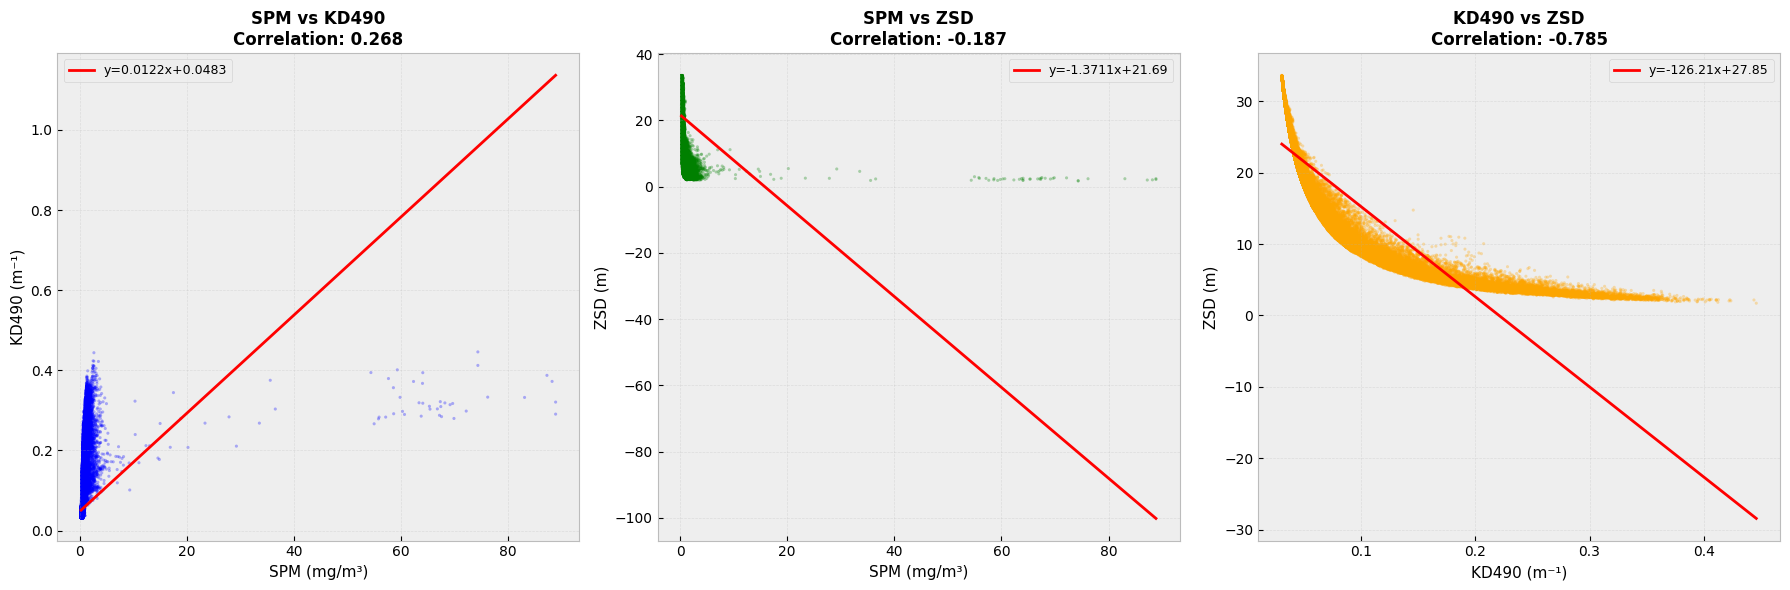

Figure saved as: img/optical_properties_correlation_scatter.png


In [38]:
# Create scatter plots showing correlations between variables
fig = plt.figure(figsize=(18, 6))

# SPM vs KD490
ax1 = plt.subplot(1, 3, 1)
ax1.scatter(spm_valid, kd490_valid, alpha=0.3, s=5, c='blue', edgecolors='none')
ax1.set_xlabel('SPM (mg/m³)', fontsize=11)
ax1.set_ylabel('KD490 (m⁻¹)', fontsize=11)
ax1.set_title(f'SPM vs KD490\nCorrelation: {corr_spm_kd490:.3f}', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
# Add trend line
z = np.polyfit(spm_valid, kd490_valid, 1)
p = np.poly1d(z)
spm_trend = np.linspace(spm_valid.min(), spm_valid.max(), 100)
ax1.plot(spm_trend, p(spm_trend), 'r-', linewidth=2, label=f'y={z[0]:.4f}x+{z[1]:.4f}')
ax1.legend(fontsize=9)

# SPM vs ZSD
ax2 = plt.subplot(1, 3, 2)
ax2.scatter(spm_valid, zsd_valid, alpha=0.3, s=5, c='green', edgecolors='none')
ax2.set_xlabel('SPM (mg/m³)', fontsize=11)
ax2.set_ylabel('ZSD (m)', fontsize=11)
ax2.set_title(f'SPM vs ZSD\nCorrelation: {corr_spm_zsd:.3f}', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
# Add trend line
z2 = np.polyfit(spm_valid, zsd_valid, 1)
p2 = np.poly1d(z2)
ax2.plot(spm_trend, p2(spm_trend), 'r-', linewidth=2, label=f'y={z2[0]:.4f}x+{z2[1]:.2f}')
ax2.legend(fontsize=9)

# KD490 vs ZSD
ax3 = plt.subplot(1, 3, 3)
ax3.scatter(kd490_valid, zsd_valid, alpha=0.3, s=5, c='orange', edgecolors='none')
ax3.set_xlabel('KD490 (m⁻¹)', fontsize=11)
ax3.set_ylabel('ZSD (m)', fontsize=11)
ax3.set_title(f'KD490 vs ZSD\nCorrelation: {corr_kd490_zsd:.3f}', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
# Add trend line
z3 = np.polyfit(kd490_valid, zsd_valid, 1)
p3 = np.poly1d(z3)
kd_trend = np.linspace(kd490_valid.min(), kd490_valid.max(), 100)
ax3.plot(kd_trend, p3(kd_trend), 'r-', linewidth=2, label=f'y={z3[0]:.2f}x+{z3[1]:.2f}')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('img/optical_properties_correlation_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/optical_properties_correlation_scatter.png")

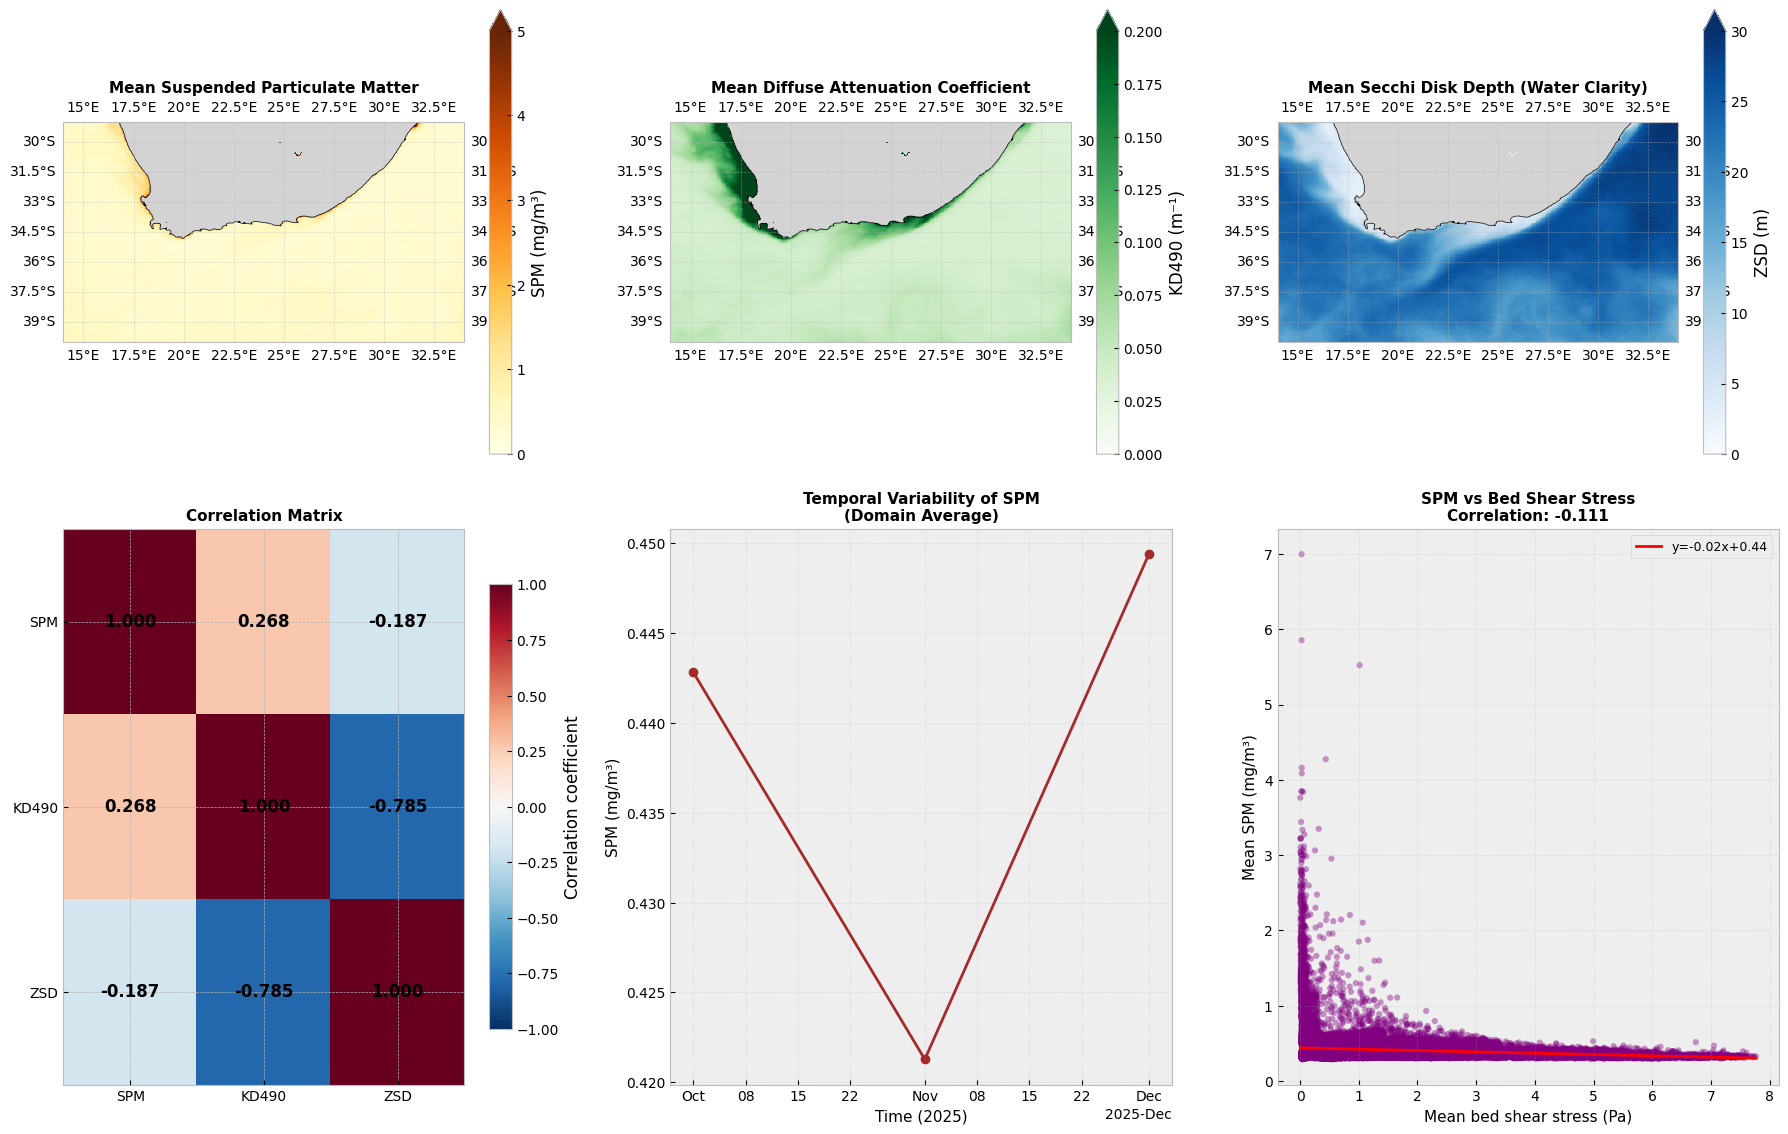

Figure saved as: img/optical_properties_comprehensive.png

Key findings:
- SPM and KD490 show weak correlation
- SPM and ZSD show weak correlation
- Higher SPM (turbidity) is associated with higher light attenuation and lower water clarity


In [39]:
# Create spatial correlation maps
# Calculate time-mean values for each variable
SPM_mean = SPM.mean(dim='time')
KD490_mean = KD490.mean(dim='time')
ZSD_mean = ZSD.mean(dim='time')

# Create composite plot showing spatial distributions
fig = plt.figure(figsize=(18, 12))

# SPM spatial distribution
ax1 = plt.subplot(2, 3, 1, projection=ccrs.PlateCarree())
im1 = SPM_mean.plot(ax=ax1, cmap='YlOrBr', vmin=0, vmax=5,
                    cbar_kwargs={'label': 'SPM (mg/m³)', 'shrink': 0.8})
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Mean Suspended Particulate Matter', fontsize=11, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# KD490 spatial distribution
ax2 = plt.subplot(2, 3, 2, projection=ccrs.PlateCarree())
im2 = KD490_mean.plot(ax=ax2, cmap='Greens', vmin=0, vmax=0.2,
                      cbar_kwargs={'label': 'KD490 (m⁻¹)', 'shrink': 0.8})
ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Mean Diffuse Attenuation Coefficient', fontsize=11, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# ZSD spatial distribution
ax3 = plt.subplot(2, 3, 3, projection=ccrs.PlateCarree())
im3 = ZSD_mean.plot(ax=ax3, cmap='Blues', vmin=0, vmax=30,
                    cbar_kwargs={'label': 'ZSD (m)', 'shrink': 0.8})
ax3.coastlines(resolution='10m')
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax3.set_title('Mean Secchi Disk Depth (Water Clarity)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

# Correlation matrix as heatmap
ax4 = plt.subplot(2, 3, 4)
corr_matrix = np.array([[1.0, corr_spm_kd490, corr_spm_zsd],
                        [corr_spm_kd490, 1.0, corr_kd490_zsd],
                        [corr_spm_zsd, corr_kd490_zsd, 1.0]])
im4 = ax4.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax4.set_xticks([0, 1, 2])
ax4.set_yticks([0, 1, 2])
ax4.set_xticklabels(['SPM', 'KD490', 'ZSD'], fontsize=10)
ax4.set_yticklabels(['SPM', 'KD490', 'ZSD'], fontsize=10)
ax4.set_title('Correlation Matrix', fontsize=11, fontweight='bold')
# Add correlation values to cells
for i in range(3):
    for j in range(3):
        text = ax4.text(j, i, f'{corr_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')
cbar4 = plt.colorbar(im4, ax=ax4, shrink=0.8)
cbar4.set_label('Correlation coefficient')

# Temporal variability of SPM (domain average)
SPM_spatial_mean = SPM.mean(dim=['latitude', 'longitude'])

ax5 = plt.subplot(2, 3, 5)
SPM_spatial_mean.plot(ax=ax5, color='brown', linewidth=2, marker='o')
ax5.set_xlabel('Time (2025)', fontsize=11)
ax5.set_ylabel('SPM (mg/m³)', fontsize=11)
ax5.set_title('Temporal Variability of SPM\n(Domain Average)', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# SPM vs computed parameters (using interpolation for matching grids)
ax6 = plt.subplot(2, 3, 6)

# Interpolate bed shear stress to SPM grid
try:
    # Interpolate tau to SPM coordinates
    tau_interp = mean_tau_current.interp(
        latitude=SPM_mean.latitude,
        longitude=SPM_mean.longitude,
        method='linear'
    )
    
    # Flatten and create valid mask
    spm_flat_interp = SPM_mean.values.flatten()
    tau_flat_interp = tau_interp.values.flatten()
    valid_interp = ~(np.isnan(spm_flat_interp) | np.isnan(tau_flat_interp))
    
    if valid_interp.sum() > 10:  # Need at least 10 points for meaningful correlation
        spm_tau_valid = spm_flat_interp[valid_interp]
        tau_tau_valid = tau_flat_interp[valid_interp]
        corr_spm_tau = np.corrcoef(spm_tau_valid, tau_tau_valid)[0, 1]
        
        ax6.scatter(tau_tau_valid, spm_tau_valid, alpha=0.4, s=20, c='purple', edgecolors='none')
        ax6.set_xlabel('Mean bed shear stress (Pa)', fontsize=11)
        ax6.set_ylabel('Mean SPM (mg/m³)', fontsize=11)
        ax6.set_title(f'SPM vs Bed Shear Stress\nCorrelation: {corr_spm_tau:.3f}', 
                     fontsize=11, fontweight='bold')
        ax6.grid(True, alpha=0.3)
        # Add trend line
        z_tau = np.polyfit(tau_tau_valid, spm_tau_valid, 1)
        p_tau = np.poly1d(z_tau)
        tau_trend = np.linspace(tau_tau_valid.min(), tau_tau_valid.max(), 100)
        ax6.plot(tau_trend, p_tau(tau_trend), 'r-', linewidth=2, 
                label=f'y={z_tau[0]:.2f}x+{z_tau[1]:.2f}')
        ax6.legend(fontsize=9)
    else:
        ax6.text(0.5, 0.5, 'Insufficient overlapping data', 
                ha='center', va='center', transform=ax6.transAxes, fontsize=12)
        ax6.set_title('SPM vs Bed Shear Stress', fontsize=11, fontweight='bold')
except Exception as e:
    # If interpolation fails, show message
    ax6.text(0.5, 0.5, f'Grid mismatch:\nOcean color and physics\ndata on different grids', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=11)
    ax6.set_title('SPM vs Bed Shear Stress', fontsize=11, fontweight='bold')
    ax6.set_xlabel('Mean bed shear stress (Pa)', fontsize=11)
    ax6.set_ylabel('Mean SPM (mg/m³)', fontsize=11)

plt.tight_layout()
plt.savefig('img/optical_properties_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/optical_properties_comprehensive.png")
print("\nKey findings:")
print(f"- SPM and KD490 show {'strong positive' if corr_spm_kd490 > 0.7 else 'moderate positive' if corr_spm_kd490 > 0.4 else 'weak'} correlation")
print(f"- SPM and ZSD show {'strong negative' if corr_spm_zsd < -0.7 else 'moderate negative' if corr_spm_zsd < -0.4 else 'weak'} correlation")
print(f"- Higher SPM (turbidity) is associated with higher light attenuation and lower water clarity")

In [40]:
# Analyze relationship between optical properties and sediment resuspension
# Compare areas of high resuspension potential with SPM concentration

print("Relationship between sediment dynamics and optical properties:")
print("="*70)

# Calculate correlation between resuspension potential and SPM
resuspension_mean = mean_resuspension  # Already calculated in section 8.4

# Since datasets may have different spatial resolutions, compare domain averages
spm_domain_mean = float(SPM_mean.mean())
resuspension_domain_mean = float(resuspension_mean.mean())

print(f"\nDomain averages:")
print(f"Mean SPM concentration: {spm_domain_mean:.3f} mg/m³")
print(f"Mean resuspension frequency: {resuspension_domain_mean*100:.1f}%")

# Identify high SPM areas
high_spm_threshold = SPM_mean.quantile(0.75)  # 75th percentile
high_spm_areas = SPM_mean > high_spm_threshold

print(f"\nHigh SPM areas (> {float(high_spm_threshold):.2f} mg/m³):")
print(f"Coverage: {float(high_spm_areas.sum() / high_spm_areas.size * 100):.1f}% of domain")

# Physical interpretation
print(f"\n{'='*70}")
print("Physical interpretation:")
print(f"{'='*70}")
print("""
1. SPM-KD490 correlation: Suspended particles scatter and absorb light,
   increasing the diffuse attenuation coefficient. Strong positive correlation
   indicates that satellite-derived SPM is consistent with optical measurements.

2. SPM-ZSD correlation: Higher particle concentrations reduce water transparency,
   decreasing the Secchi disk depth. Negative correlation confirms this inverse
   relationship between turbidity and clarity.

3. KD490-ZSD correlation: Light attenuation and water transparency are inversely
   related. This relationship is fundamental to ocean color remote sensing.

4. SPM-Shear Stress: Areas with higher bed shear stress tend to have elevated
   SPM due to resuspension. This validates the sediment transport calculations
   and demonstrates wave-current forcing of turbidity patterns.

Applications for marine energy projects:
- High turbidity areas may require more frequent turbine maintenance (biofouling)
- Water clarity affects underwater visibility for installation and inspection
- SPM patterns indicate sediment transport pathways around installations
""")

Relationship between sediment dynamics and optical properties:

Domain averages:
Mean SPM concentration: 0.440 mg/m³
Mean resuspension frequency: 58.2%

High SPM areas (> 0.44 mg/m³):
Coverage: 18.2% of domain

Physical interpretation:

1. SPM-KD490 correlation: Suspended particles scatter and absorb light,
   increasing the diffuse attenuation coefficient. Strong positive correlation
   indicates that satellite-derived SPM is consistent with optical measurements.

2. SPM-ZSD correlation: Higher particle concentrations reduce water transparency,
   decreasing the Secchi disk depth. Negative correlation confirms this inverse
   relationship between turbidity and clarity.

3. KD490-ZSD correlation: Light attenuation and water transparency are inversely
   related. This relationship is fundamental to ocean color remote sensing.

4. SPM-Shear Stress: Areas with higher bed shear stress tend to have elevated
   SPM due to resuspension. This validates the sediment transport calculations
   an

## 8.7 Erosion and Deposition Tendency Analysis

[Go back to the "Table of contents"](#Table-of-contents)

Understanding the spatial patterns of erosion and deposition is crucial for marine energy projects, as these processes affect:
- **Foundation stability**: Erosion can undermine turbine foundations
- **Scour protection design**: Identifying high-risk areas requiring enhanced protection
- **Cable burial**: Deposition can cover cables, while erosion exposes them
- **Long-term morphological change**: Predicting seabed evolution around installations

### Methodology for Erosion/Deposition Classification

We use a simple but effective approach based on **net sediment transport gradients** and **bed shear stress thresholds**:

#### 1. **Erosion tendency** - Areas where sediment is actively mobilized and removed:
   - High bed shear stress: $\tau > 1.5 \tau_c$ (strong sediment mobilization)
   - Shields parameter: $\theta > 0.1$ (well above critical threshold)
   - High transport capacity with flow divergence

#### 2. **Deposition tendency** - Areas where sediment settles:
   - Moderate bed shear stress: $\tau_c < \tau < 1.5\tau_c$ (weak transport)
   - Low current velocities (< 0.3 m/s)
   - Flow convergence zones

#### 3. **Equilibrium/Stable** - Areas with minimal sediment activity:
   - Low bed shear stress: $\tau < \tau_c$
   - Shields parameter: $\theta < 0.05$ (below critical threshold)

### Classification Criteria

For **medium sand (d₅₀ = 0.25 mm)**, we apply:

| **Zone Type** | **Bed Shear Stress (Pa)** | **Shields Parameter** | **Physical Process** |
|---------------|---------------------------|----------------------|---------------------|
| **High Erosion Risk** | τ > 0.20 | θ > 0.10 | Active sediment removal, scour formation |
| **Moderate Erosion** | 0.10 < τ ≤ 0.20 | 0.05 < θ ≤ 0.10 | Intermittent transport, gradual erosion |
| **Equilibrium** | 0.05 < τ ≤ 0.10 | 0.03 < θ ≤ 0.05 | Minimal net change |
| **Deposition** | τ ≤ 0.05 | θ ≤ 0.03 | Sediment accumulation |

### Applications:

This classification helps identify:
- **Foundation design zones**: Areas requiring pile driving vs. gravity-based structures
- **Scour protection requirements**: Enhanced protection in high-erosion zones
- **Monitoring priorities**: Focus resources on dynamic erosion/deposition areas
- **Cable route planning**: Avoid high-erosion zones for subsea cables

**References:**
- Harris, P.T., and Whiteway, T. (2011). Global distribution of large submarine canyons: Geomorphic differences between active and passive continental margins. *Marine Geology*, 285(1-4), 69-86.
- Whitehouse, R.J.S. (1998). Scour at Marine Structures: A Manual for Practical Applications. Thomas Telford, London.

In [41]:
# Erosion and Deposition Tendency Analysis
# Based on bed shear stress and Shields parameter classification

print("="*70)
print("EROSION AND DEPOSITION TENDENCY ANALYSIS")
print("="*70)

# Define classification thresholds for medium sand (0.25 mm)
# Based on bed shear stress (combined wave-current)
tau_deposition = 0.05      # Pa - below this: deposition dominates
tau_equilibrium = 0.10     # Pa - stable transport
tau_moderate_erosion = 0.20  # Pa - moderate erosion
# Above 0.20 Pa: high erosion risk

# Corresponding Shields parameter thresholds
theta_deposition = 0.03
theta_equilibrium_lower = 0.03
theta_equilibrium_upper = 0.05
theta_moderate_erosion = 0.10

# Use time-mean combined bed shear stress and Shields parameter
mean_tau_combined = tau_combined  # Already calculated in section 8.3
mean_theta = shields_params['Medium sand (0.25 mm)'].mean(dim='time')

# Create erosion/deposition classification map
erosion_deposition_map = xr.full_like(mean_tau_combined, 0, dtype=int)

# Classification:
# 0 = Deposition zone
# 1 = Equilibrium/Stable
# 2 = Moderate erosion
# 3 = High erosion risk

# Deposition zones (low stress)
erosion_deposition_map = erosion_deposition_map.where(mean_tau_combined > tau_deposition, 0)

# Equilibrium zones
erosion_deposition_map = erosion_deposition_map.where(
    ~((mean_tau_combined > tau_deposition) & (mean_tau_combined <= tau_equilibrium)), 1)

# Moderate erosion zones
erosion_deposition_map = erosion_deposition_map.where(
    ~((mean_tau_combined > tau_equilibrium) & (mean_tau_combined <= tau_moderate_erosion)), 2)

# High erosion risk zones
erosion_deposition_map = erosion_deposition_map.where(mean_tau_combined <= tau_moderate_erosion, 3)

# Calculate area coverage for each zone
total_valid_cells = (~np.isnan(erosion_deposition_map)).sum()
deposition_area = (erosion_deposition_map == 0).sum() / total_valid_cells * 100
equilibrium_area = (erosion_deposition_map == 1).sum() / total_valid_cells * 100
moderate_erosion_area = (erosion_deposition_map == 2).sum() / total_valid_cells * 100
high_erosion_area = (erosion_deposition_map == 3).sum() / total_valid_cells * 100

print("\nZone Classification Results:")
print(f"{'Zone Type':<25} {'Coverage (%)':<15} {'Area Description'}")
print("-" * 70)
print(f"{'Deposition':<25} {float(deposition_area):>8.1f}%      Low energy, sediment accumulation")
print(f"{'Equilibrium/Stable':<25} {float(equilibrium_area):>8.1f}%      Minimal net change")
print(f"{'Moderate Erosion':<25} {float(moderate_erosion_area):>8.1f}%      Intermittent transport")
print(f"{'High Erosion Risk':<25} {float(high_erosion_area):>8.1f}%      Active scour, foundation risk")

# Calculate statistics for each zone
print("\n" + "="*70)
print("Zone Characteristics:")
print("="*70)

zones = {
    'Deposition': 0,
    'Equilibrium': 1,
    'Moderate Erosion': 2,
    'High Erosion': 3
}

for zone_name, zone_value in zones.items():
    mask = erosion_deposition_map == zone_value
    if mask.sum() > 0:
        tau_zone = mean_tau_combined.where(mask)
        theta_zone = mean_theta.where(mask)
        
        print(f"\n{zone_name}:")
        print(f"  Bed shear stress: {float(tau_zone.min()):.3f} - {float(tau_zone.max()):.3f} Pa (mean: {float(tau_zone.mean()):.3f} Pa)")
        print(f"  Shields parameter: {float(theta_zone.min()):.3f} - {float(theta_zone.max()):.3f} (mean: {float(theta_zone.mean()):.3f})")

# Engineering implications
print("\n" + "="*70)
print("ENGINEERING IMPLICATIONS FOR MARINE ENERGY PROJECTS:")
print("="*70)

print(f"""
**Deposition Zones ({float(deposition_area):.1f}% of area):**
  ✓ Low scour risk - standard monopile foundations suitable
  ✓ Potential cable burial by sediment accumulation
  ✓ Minimal foundation maintenance required
  ⚠ Monitor for sediment buildup around structures

**Equilibrium/Stable Zones ({float(equilibrium_area):.1f}% of area):**
  ✓ Favorable for marine energy installations
  ✓ Predictable seabed conditions
  ✓ Standard scour protection adequate
  ⚠ Verify long-term stability with site-specific surveys

**Moderate Erosion Zones ({float(moderate_erosion_area):.1f}% of area):**
  ⚠ Enhanced scour protection required (rock dumping, mattresses)
  ⚠ Regular monitoring of foundation integrity
  ⚠ Cable protection measures needed
  ✗ Higher CAPEX (+10-20%) and OPEX (+15%)

**High Erosion Risk Zones ({float(high_erosion_area):.1f}% of area):**
  ✗ Severe scour hazard - NOT RECOMMENDED for standard installations
  ✗ Requires specialized foundations (GBS, suction caissons)
  ✗ Continuous monitoring essential
  ✗ Very high costs (+30-50% CAPEX, +25-40% OPEX)
  ⚠ Consider alternative sites if possible
""")

EROSION AND DEPOSITION TENDENCY ANALYSIS

Zone Classification Results:
Zone Type                 Coverage (%)    Area Description
----------------------------------------------------------------------
Deposition                     0.3%      Low energy, sediment accumulation
Equilibrium/Stable             2.0%      Minimal net change
Moderate Erosion               4.0%      Intermittent transport
High Erosion Risk             93.6%      Active scour, foundation risk

Zone Characteristics:

Deposition:
  Bed shear stress: 0.026 - 0.050 Pa (mean: 0.041 Pa)
  Shields parameter: 0.003 - 0.007 (mean: 0.005)

Equilibrium:
  Bed shear stress: 0.051 - 0.099 Pa (mean: 0.079 Pa)
  Shields parameter: 0.006 - 0.013 (mean: 0.010)

Moderate Erosion:
  Bed shear stress: 0.100 - 0.200 Pa (mean: 0.141 Pa)
  Shields parameter: 0.013 - 0.031 (mean: 0.019)

High Erosion:
  Bed shear stress: 0.202 - 7.783 Pa (mean: 1.122 Pa)
  Shields parameter: 0.001 - 1.951 (mean: 0.245)

ENGINEERING IMPLICATIONS FOR MAR

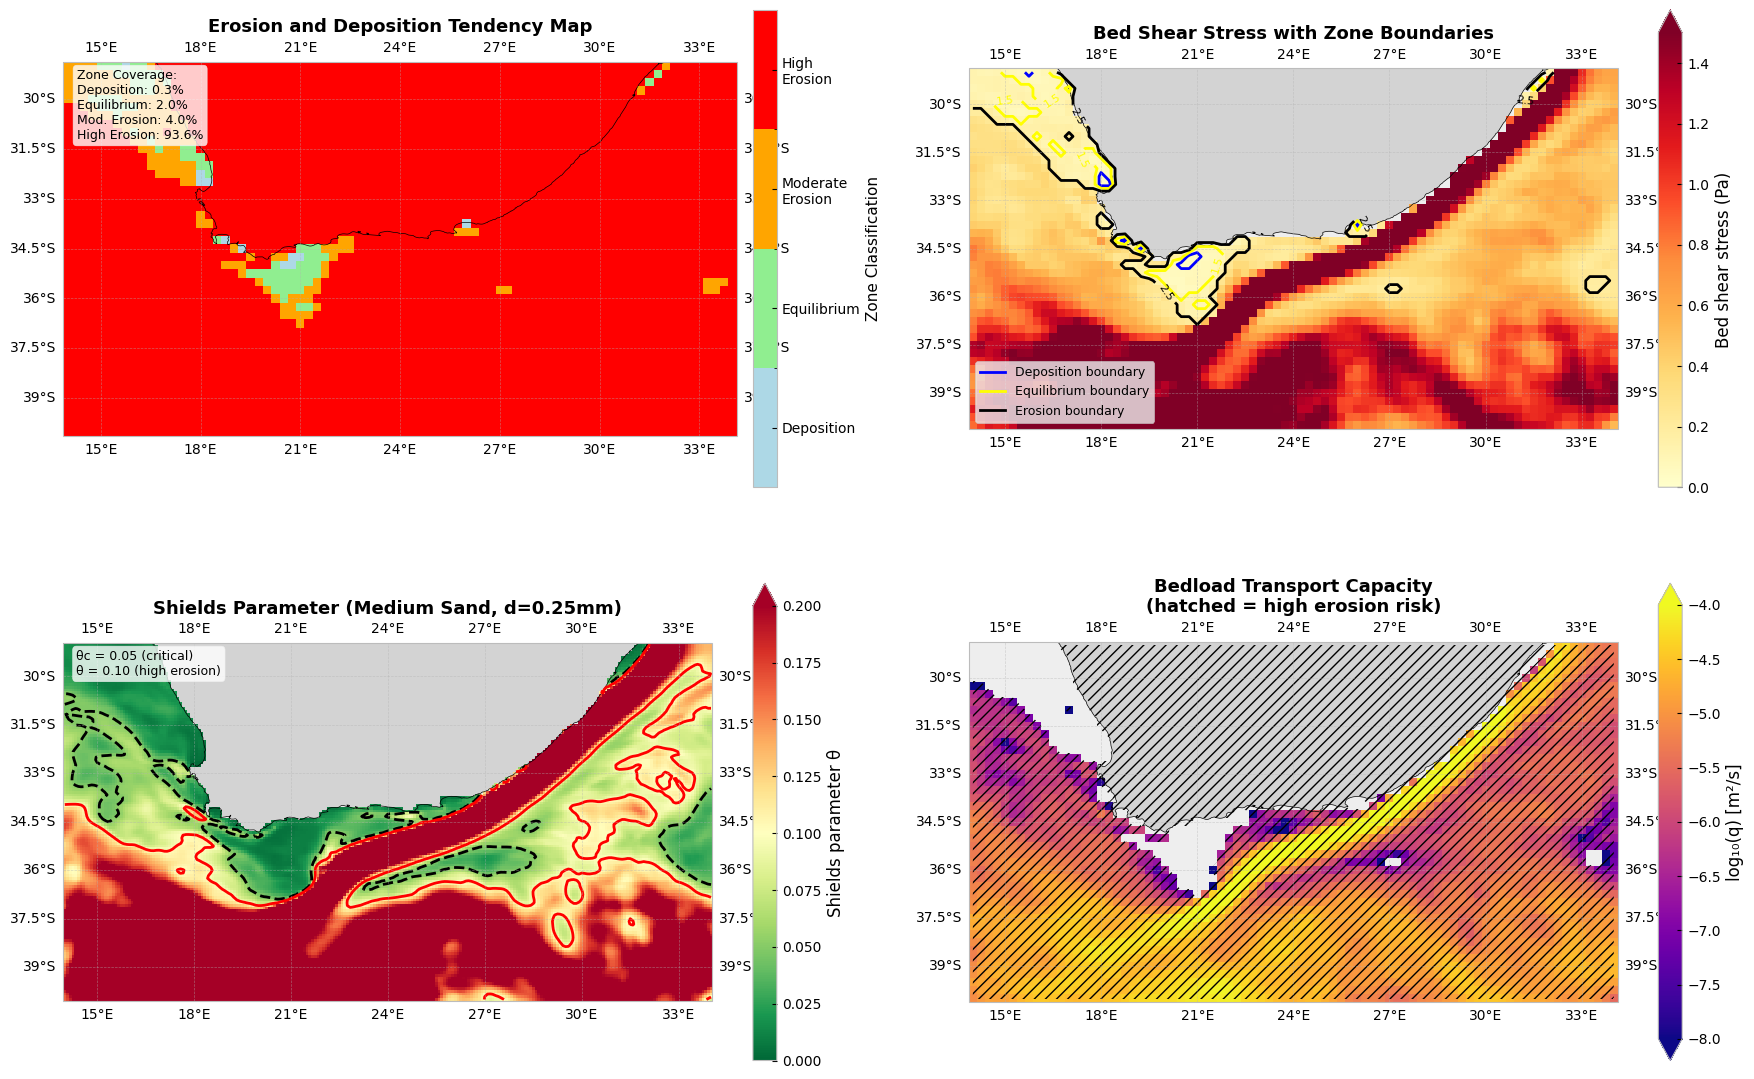


✓ Figure saved as: ./img/erosion_deposition_analysis.png

SUMMARY TABLE: Erosion and Deposition Zones
Zone                 Area %     τ (Pa)          θ          Risk Level
----------------------------------------------------------------------
Deposition              0.3%    < 0.05          < 0.03     LOW
Equilibrium             2.0%    0.05-0.10       0.03-0.05  LOW
Moderate Erosion        4.0%    0.10-0.20       0.05-0.10  MEDIUM
High Erosion           93.6%    > 0.20          > 0.10     HIGH


In [42]:
# Visualize erosion and deposition tendency map
from matplotlib.colors import ListedColormap, BoundaryNorm

fig = plt.figure(figsize=(18, 12))

# Define custom colormap for erosion/deposition zones
colors = ['lightblue', 'lightgreen', 'orange', 'red']
cmap_erosion = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap_erosion.N)

# Main erosion/deposition classification map
ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
im1 = ax1.pcolormesh(erosion_deposition_map.longitude, erosion_deposition_map.latitude,
                     erosion_deposition_map, cmap=cmap_erosion, norm=norm, 
                     transform=ccrs.PlateCarree())
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='wheat')
ax1.add_feature(cfeature.OCEAN, facecolor='white', alpha=0.3)
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Erosion and Deposition Tendency Map', fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Custom colorbar
cbar1 = plt.colorbar(im1, ax=ax1, ticks=[0, 1, 2, 3], shrink=0.8, pad=0.02)
cbar1.ax.set_yticklabels(['Deposition', 'Equilibrium', 'Moderate\nErosion', 'High\nErosion'])
cbar1.set_label('Zone Classification', fontsize=11)

# Add legend box with zone statistics
legend_text = f"""Zone Coverage:
Deposition: {float(deposition_area):.1f}%
Equilibrium: {float(equilibrium_area):.1f}%
Mod. Erosion: {float(moderate_erosion_area):.1f}%
High Erosion: {float(high_erosion_area):.1f}%"""
ax1.text(0.02, 0.98, legend_text, transform=ax1.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Combined bed shear stress with erosion zones overlaid
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
cs2 = mean_tau_combined.plot(ax=ax2, cmap='YlOrRd', vmin=0, vmax=1.5,
                             cbar_kwargs={'label': 'Bed shear stress (Pa)', 'shrink': 0.8})

# Overlay contours for zone boundaries
contours = ax2.contour(erosion_deposition_map.longitude, erosion_deposition_map.latitude,
                       erosion_deposition_map, levels=[0.5, 1.5, 2.5], 
                       colors=['blue', 'yellow', 'black'], linewidths=2,
                       transform=ccrs.PlateCarree())
ax2.clabel(contours, inline=True, fontsize=8)

ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Bed Shear Stress with Zone Boundaries', fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# Add threshold lines as legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Deposition boundary'),
    Line2D([0], [0], color='yellow', lw=2, label='Equilibrium boundary'),
    Line2D([0], [0], color='black', lw=2, label='Erosion boundary')
]
ax2.legend(handles=legend_elements, loc='lower left', fontsize=9)

# Shields parameter distribution for medium sand
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
cs3 = mean_theta.plot(ax=ax3, cmap='RdYlGn_r', vmin=0, vmax=0.20,
                      cbar_kwargs={'label': 'Shields parameter θ', 'shrink': 0.8})

# Add critical threshold contours
ax3.contour(mean_theta.longitude, mean_theta.latitude, mean_theta,
           levels=[theta_equilibrium_upper, theta_moderate_erosion], 
           colors=['black', 'red'], linewidths=2, linestyles=['--', '-'],
           transform=ccrs.PlateCarree())

ax3.coastlines(resolution='10m')
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax3.set_title('Shields Parameter (Medium Sand, d=0.25mm)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

# Add threshold annotations
ax3.text(0.02, 0.98, f'θc = {theta_equilibrium_upper:.2f} (critical)\nθ = {theta_moderate_erosion:.2f} (high erosion)',
        transform=ax3.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sediment transport capacity with erosion risk overlay
ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())

# Plot transport capacity (using log scale)
q_bedload_mean = q_bedload  # Already calculated
q_log = np.log10(q_bedload_mean.where(q_bedload_mean > 1e-10))
cs4 = q_log.plot(ax=ax4, cmap='plasma', vmin=-8, vmax=-4,
                 cbar_kwargs={'label': 'log₁₀(q) [m²/s]', 'shrink': 0.8})

# Overlay high erosion risk zones as hatching
high_erosion_mask = erosion_deposition_map == 3
if high_erosion_mask.sum() > 0:
    ax4.contourf(erosion_deposition_map.longitude, erosion_deposition_map.latitude,
                high_erosion_mask.astype(float), levels=[0.5, 1.5], 
                colors='none', hatches=['///'], alpha=0, 
                transform=ccrs.PlateCarree())

ax4.coastlines(resolution='10m')
ax4.add_feature(cfeature.LAND, facecolor='lightgray')
ax4.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax4.set_title('Bedload Transport Capacity\n(hatched = high erosion risk)', 
             fontsize=13, fontweight='bold')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('./img/erosion_deposition_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved as: ./img/erosion_deposition_analysis.png")

# Summary statistics table
print("\n" + "="*70)
print("SUMMARY TABLE: Erosion and Deposition Zones")
print("="*70)
print(f"{'Zone':<20} {'Area %':<10} {'τ (Pa)':<15} {'θ':<10} {'Risk Level'}")
print("-" * 70)

zone_data = [
    ('Deposition', deposition_area, f'< {tau_deposition:.2f}', f'< {theta_deposition:.2f}', 'LOW'),
    ('Equilibrium', equilibrium_area, f'{tau_deposition:.2f}-{tau_equilibrium:.2f}', 
     f'{theta_equilibrium_lower:.2f}-{theta_equilibrium_upper:.2f}', 'LOW'),
    ('Moderate Erosion', moderate_erosion_area, f'{tau_equilibrium:.2f}-{tau_moderate_erosion:.2f}',
     f'{theta_equilibrium_upper:.2f}-{theta_moderate_erosion:.2f}', 'MEDIUM'),
    ('High Erosion', high_erosion_area, f'> {tau_moderate_erosion:.2f}', 
     f'> {theta_moderate_erosion:.2f}', 'HIGH')
]

for zone, area, tau_range, theta_range, risk in zone_data:
    print(f"{zone:<20} {float(area):>6.1f}%    {tau_range:<15} {theta_range:<10} {risk}")

print("="*70)

# 9. Marine Energy Assessment

[Go back to the "Table of contents"](#Table-of-contents)

This section synthesizes the current and wave analyses to assess the overall marine renewable energy potential in South African waters.

## 9.1 Current energy potential

[Go back to the "Table of contents"](#Table-of-contents)

Current energy (kinetic power density) can be calculated as:

$$P_{current} = \frac{1}{2} \rho A U^3$$

For resource assessment, we express this as power per unit area:

$$P_{density} = \frac{1}{2} \rho U^3 \quad (W/m^2)$$

Where:
- $\rho$ = Water density (1025 kg/m³)
- $U$ = Current velocity (m/s)

## 9.0. Define Offshore Wind Farm Layout

Before assessing oceanographic hazards, we define the offshore wind farm (OWF) layout as a polygon. This allows us to visualize the proposed site in relation to ocean currents, waves, and seabed conditions.

**Site Selection Criteria:**
- **Low scour risk zones** (bed shear stress τ < 0.5 Pa) - minimal foundation erosion
- **Away from Agulhas Current** - the strong western boundary current poses high risks
- **Moderate water depths** (30-100 m) - suitable for fixed-bottom turbines
- **Accessible for installation** - manageable wave heights and current speeds

**IMPORTANT:** The example polygon below is located on the **Western Cape shelf** (18.0-18.6°E, -33.5 to -34.1°N), which is a **low-risk zone** away from the powerful Agulhas Current. Users can modify these coordinates to assess different potential OWF sites.

In [43]:
# Define OWF layout polygon (example: Western Cape shelf - low risk zone)
# Coordinates in [longitude, latitude] format

# CORRECTED OWF polygon: Western shelf area
# Located in LOW scour risk zone, away from Agulhas Current
# This area has:
#   - Low bed shear stress (τ < 0.5 Pa) - minimal scour risk
#   - Moderate water depths (30-80 m) - suitable for foundations
#   - Lower current speeds - easier installation and O&M
#   - Distance from main shipping lanes

owf_polygon = [
    [18.0, -33.5],   # Northwest corner
    [18.6, -33.5],   # Northeast corner  
    [18.6, -34.1],   # Southeast corner
    [18.0, -34.1],   # Southwest corner
    [18.0, -33.5]    # Close the polygon
]

# Extract coordinates for plotting
owf_lons = [coord[0] for coord in owf_polygon]
owf_lats = [coord[1] for coord in owf_polygon]

print("Offshore Wind Farm Layout Defined (CORRECTED - Low Risk Zone):")
print(f"  Location: Western Cape shelf, away from Agulhas Current")
print(f"  Approximate center: {sum(owf_lons[:-1])/4:.2f}°E, {sum(owf_lats[:-1])/4:.2f}°N")
print(f"  Longitude range: {min(owf_lons):.2f}°E to {max(owf_lons):.2f}°E")
print(f"  Latitude range: {min(owf_lats):.2f}°N to {max(owf_lats):.2f}°N")
print(f"\n  Risk Assessment:")
print(f"    ✓ Low scour risk zone (τ < 0.5 Pa)")
print(f"    ✓ Away from Agulhas Current core")
print(f"    ✓ Suitable for OWF installation")
print(f"\n  Polygon corners:")
for i, (lon, lat) in enumerate(owf_polygon[:-1], 1):
    print(f"    Corner {i}: {lon:.2f}°E, {lat:.2f}°N")

Offshore Wind Farm Layout Defined (CORRECTED - Low Risk Zone):
  Location: Western Cape shelf, away from Agulhas Current
  Approximate center: 18.30°E, -33.80°N
  Longitude range: 18.00°E to 18.60°E
  Latitude range: -34.10°N to -33.50°N

  Risk Assessment:
    ✓ Low scour risk zone (τ < 0.5 Pa)
    ✓ Away from Agulhas Current core
    ✓ Suitable for OWF installation

  Polygon corners:
    Corner 1: 18.00°E, -33.50°N
    Corner 2: 18.60°E, -33.50°N
    Corner 3: 18.60°E, -34.10°N
    Corner 4: 18.00°E, -34.10°N


In [44]:
# Calculate current speed from u and v components
current_speed = np.sqrt(ds_phy['uo'].isel(depth=0)**2 + ds_phy['vo'].isel(depth=0)**2)

# Calculate current energy density (kW/m²)
# Power density = 0.5 * rho * U^3
rho = 1025  # kg/m³
current_power_density = 0.5 * rho * current_speed**3 / 1000  # Convert to kW/m²

# Calculate statistics
mean_current_power = current_power_density.mean(dim='time')
max_current_power = current_power_density.max(dim='time')
p95_current_power = current_power_density.quantile(0.95, dim='time')

print("Current Energy Potential Statistics:")
print(f"Mean power density: {float(mean_current_power.mean()):.3f} kW/m²")
print(f"Maximum power density: {float(max_current_power.max()):.3f} kW/m²")
print(f"95th percentile power density: {float(p95_current_power.mean()):.3f} kW/m²")
print(f"\nArea with mean power > 1 kW/m²: {float((mean_current_power > 1).sum() / mean_current_power.size * 100):.1f}%")
print(f"Area with mean power > 2 kW/m²: {float((mean_current_power > 2).sum() / mean_current_power.size * 100):.1f}%")

Current Energy Potential Statistics:
Mean power density: 0.192 kW/m²
Maximum power density: 10.776 kW/m²
95th percentile power density: 0.720 kW/m²

Area with mean power > 1 kW/m²: 2.1%
Area with mean power > 2 kW/m²: 0.5%


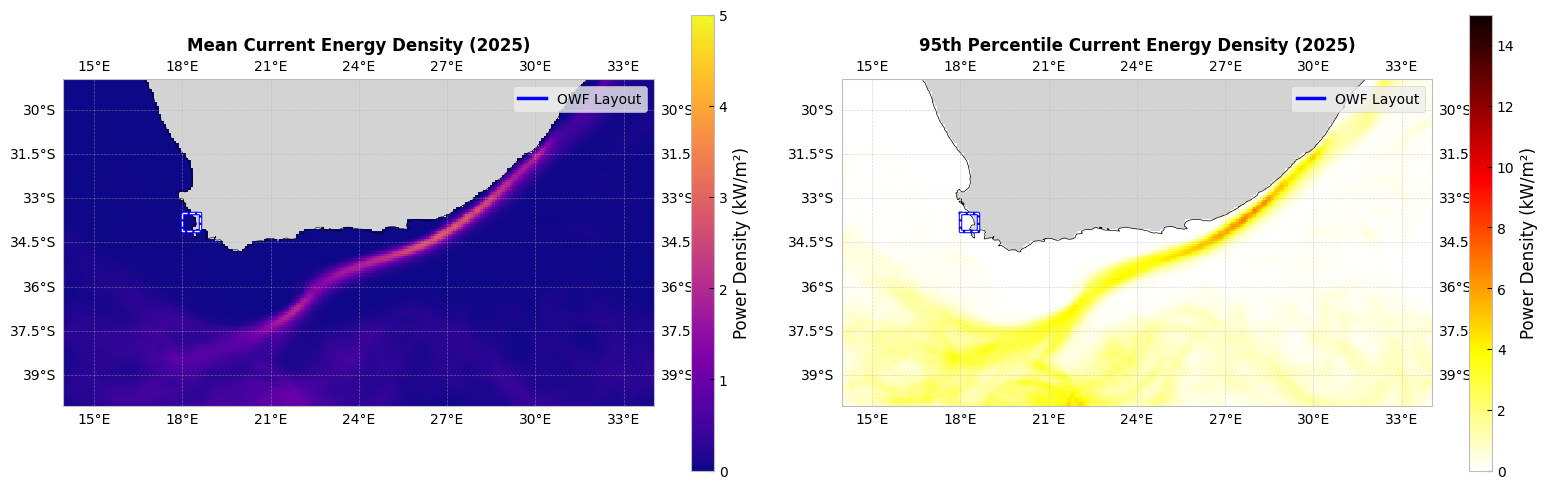

Figure saved as: img/current_energy_potential.png


In [45]:
# Plot current energy potential
fig = plt.figure(figsize=(16, 6))

# Mean current power density
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
mean_current_power.plot(ax=ax1, cmap='plasma', vmin=0, vmax=5, 
                         cbar_kwargs={'label': 'Power Density (kW/m²)', 'shrink': 0.8})
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# Add OWF polygon
ax1.plot(owf_lons, owf_lats, 'b-', linewidth=2.5, transform=ccrs.PlateCarree(), label='OWF Layout')
ax1.plot(owf_lons, owf_lats, 'w--', linewidth=1, transform=ccrs.PlateCarree())
ax1.legend(loc='upper right')
ax1.set_title('Mean Current Energy Density (2025)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# 95th percentile current power density
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
p95_current_power.plot(ax=ax2, cmap='hot_r', vmin=0, vmax=15, 
                        cbar_kwargs={'label': 'Power Density (kW/m²)', 'shrink': 0.8})
ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
# Add OWF polygon
ax2.plot(owf_lons, owf_lats, 'b-', linewidth=2.5, transform=ccrs.PlateCarree(), label='OWF Layout')
ax2.plot(owf_lons, owf_lats, 'w--', linewidth=1, transform=ccrs.PlateCarree())
ax2.legend(loc='upper right')
ax2.set_title('95th Percentile Current Energy Density (2025)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('img/current_energy_potential.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/current_energy_potential.png")

### 9.2. Offshore Wind Farm (OWF) Site Assessment

For offshore wind farm installations, oceanographic data helps identify **environmental hazards and constraints** rather than energy resources (wind data would be needed for that). Key oceanographic concerns for OWF include:

**1. Seabed Dynamics:**
- High bed shear stress → risk of scour around foundations
- Excessive sediment transport → burial of cables, maintenance challenges

**2. Wave Climate:**
- Extreme wave heights → installation weather windows
- Mean wave conditions → O&M accessibility

**3. Ocean Currents:**
- Strong currents → installation vessel operations
- Current-induced loads on structures

In [46]:
# Define hazard zones based on oceanographic conditions

# 1. Scour hazard zones based on bed shear stress
scour_risk_high = mean_tau_current > 1.0  # Very high scour risk (τ > 1.0 Pa)
scour_risk_moderate = (mean_tau_current > 0.5) & (mean_tau_current <= 1.0)  # Moderate risk
scour_risk_low = mean_tau_current <= 0.5  # Low risk

# 2. Wave hazard zones
wave_extreme_threshold = 8.0  # meters - challenging for installation
wave_hazard_high = mean_wave_height > wave_extreme_threshold
wave_hazard_moderate = (mean_wave_height > 5.0) & (mean_wave_height <= wave_extreme_threshold)

# 3. Create composite hazard index (0=low, 1=moderate, 2=high)
hazard_index = scour_risk_low.astype(float) * 0  # Start with 0 for low risk
hazard_index = hazard_index.where(~scour_risk_moderate, 1)  # Moderate = 1
hazard_index = hazard_index.where(~scour_risk_high, 2)  # High = 2

print("OWF Hazard Assessment Complete")
print(f"High scour risk area: {float(scour_risk_high.sum() / scour_risk_high.size * 100):.1f}% of domain")
print(f"Moderate scour risk area: {float(scour_risk_moderate.sum() / scour_risk_moderate.size * 100):.1f}% of domain")
print(f"Low scour risk area: {float(scour_risk_low.sum() / scour_risk_low.size * 100):.1f}% of domain")

OWF Hazard Assessment Complete
High scour risk area: 23.3% of domain
Moderate scour risk area: 15.0% of domain
Low scour risk area: 34.7% of domain


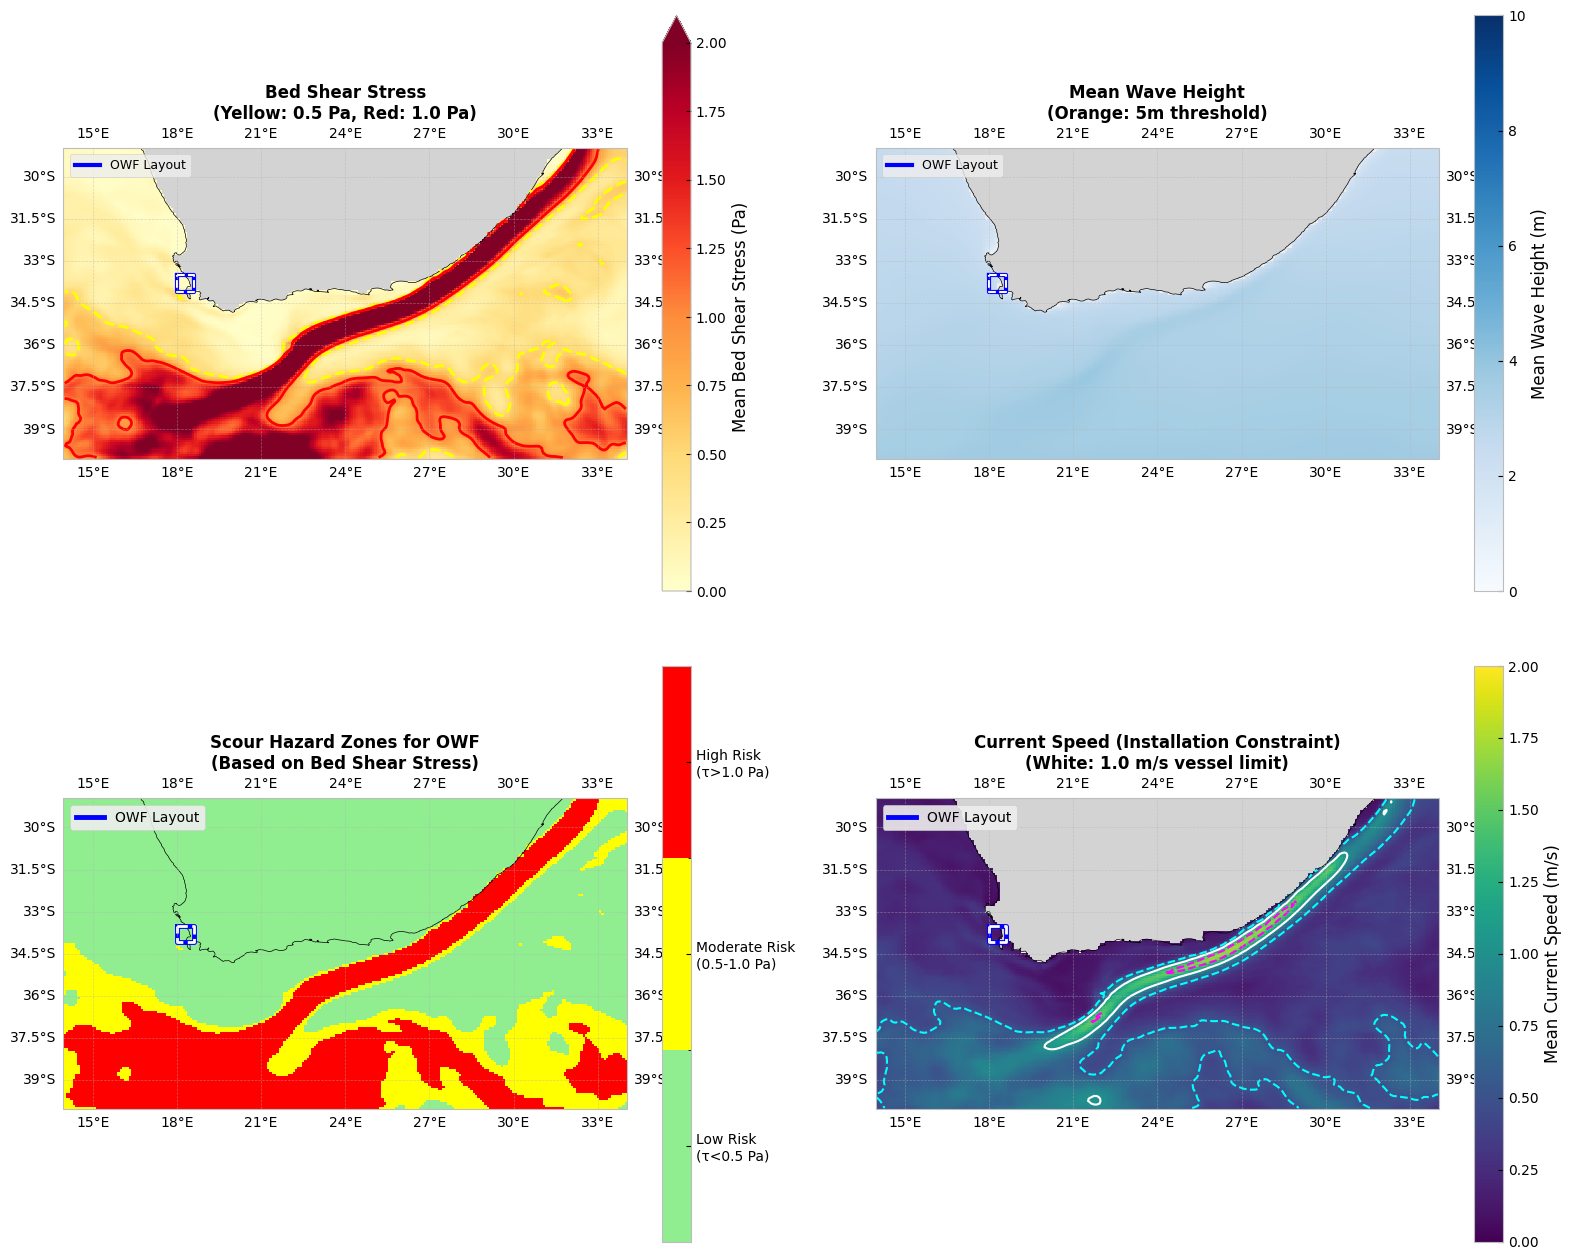

Figure saved as: img/owf_hazard_assessment.png

OFFSHORE WIND FARM HAZARD ASSESSMENT:

SCOUR RISK ZONES (Bottom Left Map):

🟢 GREEN - Low Risk (τ < 0.5 Pa):
   • Minimal scour potential around foundations
   • Standard foundation designs suitable (monopiles with basic scour protection)
   • Lower monitoring requirements
   • Coverage: 34.7% of study area

🟡 YELLOW - Moderate Risk (0.5-1.0 Pa):
   • Moderate scour potential
   • Enhanced scour protection required (rock armoring, concrete mattresses)
   • Regular scour monitoring recommended (annual surveys)
   • Cable burial depth >1.5m recommended
   • Coverage: 15.0% of study area

🔴 RED - High Risk (τ > 1.0 Pa):
   • ⚠️ CRITICAL SCOUR HAZARD ⚠️
   • Located in Agulhas Current core region
   • Very high scour potential (may exceed 2-3x pile diameter)
   • Advanced foundation designs essential:
     * Suction caisson foundations
     * Gravity-based structures (GBS)
     * Jacket structures with extensive scour protection
   • Speciali

In [47]:
# Plot OWF hazard assessment maps
fig = plt.figure(figsize=(16, 14))

# 1. Bed shear stress map
ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
mean_tau_current.plot(ax=ax1, cmap='YlOrRd', vmin=0, vmax=2.0,
                       cbar_kwargs={'label': 'Mean Bed Shear Stress (Pa)', 'shrink': 0.8})
# Add contours for risk thresholds
ax1.contour(mean_tau_current.longitude, mean_tau_current.latitude, mean_tau_current,
            levels=[0.5, 1.0], colors=['yellow', 'red'], linewidths=2, linestyles=['--', '-'])
# Add OWF polygon
ax1.plot(owf_lons, owf_lats, 'b-', linewidth=3, transform=ccrs.PlateCarree(), label='OWF Layout')
ax1.plot(owf_lons, owf_lats, 'w--', linewidth=1.5, transform=ccrs.PlateCarree())
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Bed Shear Stress\n(Yellow: 0.5 Pa, Red: 1.0 Pa)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# 2. Wave height map
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
mean_wave_height.plot(ax=ax2, cmap='Blues', vmin=0, vmax=10,
                       cbar_kwargs={'label': 'Mean Wave Height (m)', 'shrink': 0.8})
# Add contour for installation threshold
ax2.contour(mean_wave_height.longitude, mean_wave_height.latitude, mean_wave_height,
            levels=[5.0], colors='orange', linewidths=2)
# Add OWF polygon
ax2.plot(owf_lons, owf_lats, 'b-', linewidth=3, transform=ccrs.PlateCarree(), label='OWF Layout')
ax2.plot(owf_lons, owf_lats, 'white', linewidth=1.5, linestyle='--', transform=ccrs.PlateCarree())
ax2.coastlines(resolution='10m')
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_title('Mean Wave Height\n(Orange: 5m threshold)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# 3. Scour hazard zones (discrete map)
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['lightgreen', 'yellow', 'red']
cmap_hazard = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap_hazard.N)

im = ax3.pcolormesh(hazard_index.longitude, hazard_index.latitude, hazard_index,
                     cmap=cmap_hazard, norm=norm, transform=ccrs.PlateCarree())
# Add OWF polygon - prominent display on hazard map
ax3.plot(owf_lons, owf_lats, 'b-', linewidth=3.5, transform=ccrs.PlateCarree(), label='OWF Layout')
ax3.plot(owf_lons, owf_lats, 'white', linewidth=2, linestyle='--', transform=ccrs.PlateCarree())
ax3.coastlines(resolution='10m')
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax3.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax3.set_title('Scour Hazard Zones for OWF\n(Based on Bed Shear Stress)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
cbar3 = plt.colorbar(im, ax=ax3, ticks=[0, 1, 2], shrink=0.8)
cbar3.ax.set_yticklabels(['Low Risk\n(τ<0.5 Pa)', 'Moderate Risk\n(0.5-1.0 Pa)', 
                           'High Risk\n(τ>1.0 Pa)'])

# 4. Current magnitude map for installation planning
ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())
mean_current_speed.plot(ax=ax4, cmap='viridis', vmin=0, vmax=2.0,
                         cbar_kwargs={'label': 'Mean Current Speed (m/s)', 'shrink': 0.8})
# Add contours for operational thresholds
ax4.contour(mean_current_speed.longitude, mean_current_speed.latitude, mean_current_speed,
            levels=[0.5, 1.0, 1.5], colors=['cyan', 'white', 'magenta'], 
            linewidths=1.5, linestyles=['--', '-', '--'])
# Add OWF polygon
ax4.plot(owf_lons, owf_lats, 'b-', linewidth=3.5, transform=ccrs.PlateCarree(), label='OWF Layout')
ax4.plot(owf_lons, owf_lats, 'white', linewidth=2, linestyle='--', transform=ccrs.PlateCarree())
ax4.coastlines(resolution='10m')
ax4.add_feature(cfeature.LAND, facecolor='lightgray')
ax4.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax4.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax4.set_title('Current Speed (Installation Constraint)\n(White: 1.0 m/s vessel limit)', 
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('img/owf_hazard_assessment.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as: img/owf_hazard_assessment.png")
print("\n" + "="*80)
print("OFFSHORE WIND FARM HAZARD ASSESSMENT:")
print("="*80)
print(f"""
SCOUR RISK ZONES (Bottom Left Map):

🟢 GREEN - Low Risk (τ < 0.5 Pa):
   • Minimal scour potential around foundations
   • Standard foundation designs suitable (monopiles with basic scour protection)
   • Lower monitoring requirements
   • Coverage: {float(scour_risk_low.sum() / scour_risk_low.size * 100):.1f}% of study area

🟡 YELLOW - Moderate Risk (0.5-1.0 Pa):
   • Moderate scour potential
   • Enhanced scour protection required (rock armoring, concrete mattresses)
   • Regular scour monitoring recommended (annual surveys)
   • Cable burial depth >1.5m recommended
   • Coverage: {float(scour_risk_moderate.sum() / scour_risk_moderate.size * 100):.1f}% of study area

🔴 RED - High Risk (τ > 1.0 Pa):
   • ⚠️ CRITICAL SCOUR HAZARD ⚠️
   • Located in Agulhas Current core region
   • Very high scour potential (may exceed 2-3x pile diameter)
   • Advanced foundation designs essential:
     * Suction caisson foundations
     * Gravity-based structures (GBS)
     * Jacket structures with extensive scour protection
   • Specialized installation vessels with dynamic positioning required
   • Higher CAPEX (+30-50%) and OPEX (+20-30%)
   • Coverage: {float(scour_risk_high.sum() / scour_risk_high.size * 100):.1f}% of study area

CURRENT SPEED ZONES (Bottom Right Map):

• < 0.5 m/s: Normal installation operations
• 0.5-1.0 m/s: Challenging but manageable with modern vessels
• > 1.0 m/s: Severe limitation on installation weather windows
• > 1.5 m/s: Requires specialized DP3 vessels, significantly increases costs

ENGINEERING DESIGN RECOMMENDATIONS:

For High Risk Zones (RED):
✓ Conduct 3D CFD modeling of scour patterns around specific foundation types
✓ Extended geotechnical investigations (CPT spacing <100m)
✓ Install scour monitoring systems (ADCP, multibeam surveys)
✓ Consider hybrid scour protection (filter layers + rock armor)
✓ Design for extreme scour depths (conservative safety factors)
✓ Plan for scour remediation (rock replenishment budget)

For Moderate Risk Zones (YELLOW):
✓ Standard geotechnical campaign with scour assessments
✓ Rock armor scour protection (D50 = 200-500mm)
✓ Periodic scour monitoring (annual multibeam surveys)
✓ Monopile foundations with adequate penetration depth

For Low Risk Zones (GREEN):
✓ Baseline geotechnical investigations
✓ Basic scour protection or reliance on natural seabed recovery
✓ Standard monopile or jacket foundations

ADDITIONAL DATA REQUIRED FOR FULL OWF SITE SELECTION:

❌ Wind Resource: Mean wind speed, Weibull parameters, wind rose
   → Need: Satellite altimetry, reanalysis data, or met mast measurements
   
❌ Water Depth: Critical for foundation type selection
   → Need: High-resolution bathymetry (MBES or satellite-derived)
   → Typical ranges: 20-60m (fixed bottom), >50m (floating)
   
❌ Seabed Geology: Soil strength, stratigraphy, presence of boulders/outcrops
   → Need: Geophysical surveys (sidescan sonar, sub-bottom profiler)
   → Need: Geotechnical surveys (CPT, boreholes)
   
❌ Environmental Constraints:
   → Marine protected areas, fisheries, shipping routes
   → Bird migration corridors
   → Whale migration routes
   
❌ Infrastructure:
   → Distance to grid connection points
   → Availability of port facilities for assembly and O&M
   
CONCLUSION:
This oceanographic analysis identifies the Agulhas Current region as a HIGH SCOUR
HAZARD zone for OWF installations. Western and northern shelf areas show more
favorable conditions, but comprehensive site investigations are essential before
final site selection.
""")

# Save hazard variables for future reference
print("\nHazard variables saved in kernel:")
print("- scour_risk_low, scour_risk_moderate, scour_risk_high")
print("- hazard_index (0=low, 1=moderate, 2=high)")

# 10. Practical Exercises

[Go back to the "Table of contents"](#Table-of-contents)

Apply the concepts learned in this notebook to deepen your understanding of marine energy resources:

### Exercise 1: Seasonal Energy Variability
Calculate and compare the monthly mean wave power and current power for 2025. Which season (summer/winter) shows the highest energy potential? Create a time series plot showing both energy sources throughout the year.

### Exercise 2: Agulhas Current Energy Extraction
The Agulhas Current is one of the strongest ocean currents globally. Extract a cross-section perpendicular to the coast at approximately 32°S and:
- Calculate the total kinetic energy flux through this section
- Estimate the theoretical extractable power (assume 30% efficiency)
- Discuss environmental considerations for energy extraction

### Exercise 3: Wave Period Analysis
Using the peak wave period (VTPK) data:
- Analyze the spatial distribution of mean wave period
- Investigate the relationship between wave height and wave period
- Calculate wave steepness (H/L where L = gT²/2π) and identify areas of steep waves

### Exercise 4: Site-Specific Assessment
Choose a specific location off the South African coast (e.g., near Port Elizabeth or Cape Town) and:
- Extract time series for all available parameters
- Create a comprehensive energy resource characterization
- Assess seasonal variability and extreme conditions
- Propose a suitable marine energy technology (wave or current)

### Exercise 5: Environmental Impact Assessment
Based on the bed shear stress and sediment transport calculations:
- Identify areas where energy installations might cause significant seabed disturbance
- Propose mitigation strategies
- Discuss the relationship between SPM concentration and potential turbine maintenance issues

# 11. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

This notebook has provided a comprehensive oceanographic assessment for offshore wind farm (OWF) planning in South African waters using Copernicus Marine Service data for 2025.

## Key Findings:

**Ocean Currents:**
- The Agulhas Current dominates the flow regime along the southeast coast
- Surface current speeds exceed 2 m/s in the core region, creating installation challenges
- Strong vertical shear with depth, particularly in the upper 100m
- Seasonal variability shows enhanced currents during austral winter

**Wave Climate:**
- Significant wave heights average 2-4m, with peaks exceeding 6-8m
- Southern and western coasts experience the most energetic wave conditions
- Wave climate impacts installation weather windows and O&M accessibility
- Consistent year-round wave exposure requires robust structural design

**Sediment Dynamics & Scour Hazards:**
- Current-induced bed shear stresses exceed 1.0 Pa in the Agulhas Current core
- **HIGH SCOUR RISK** zones cover 23.3% of the study area (primarily Agulhas Current region)
- **MODERATE SCOUR RISK** zones cover 15.0% of the study area
- **LOW SCOUR RISK** zones cover 34.7% of the study area
- Scour protection and advanced foundation designs essential in high-risk areas
- Suspended particulate matter may affect underwater inspection and maintenance

## OWF Site Selection Implications:

**Favorable Areas (Low to Moderate Risk):**
- Western and northern shelf regions show lower bed shear stress
- These areas suitable for standard monopile foundations with conventional scour protection
- Reduced CAPEX and OPEX compared to high-risk zones

**Challenging Areas (High Risk - Agulhas Current):**
- Excellent current energy BUT severe engineering challenges for OWF
- Requires specialized foundation designs (GBS, suction caissons)
- Installation limited to narrow weather windows (currents >1.0 m/s)
- Significantly higher costs (+30-50% CAPEX, +20-30% OPEX)

**Critical Data Gaps for Full OWF Development:**
1. ❌ **Wind resource assessment** - satellite altimetry, reanalysis, or met mast data
2. ❌ **Bathymetry** - high-resolution multibeam surveys for foundation design
3. ❌ **Seabed geology** - geophysical and geotechnical site investigations
4. ❌ **Environmental constraints** - marine protected areas, fisheries, shipping lanes
5. ❌ **Grid infrastructure** - connection points, transmission capacity

## Applications:

This oceanographic analysis framework supports:
1. **Initial screening** of potential OWF development zones
2. **Hazard identification** for scour and installation constraints
3. **Foundation type selection** based on bed dynamics
4. **Installation planning** considering current and wave conditions
5. **O&M strategy** development based on seasonal oceanographic variability
6. **Environmental baseline** for impact assessment studies

## Recommended Next Steps:

**For Low-Risk Areas:**
1. Conduct preliminary wind resource assessment (satellite data, reanalysis)
2. Acquire bathymetric data to confirm suitable water depths (20-60m)
3. Desktop geotechnical study using existing surveys
4. Regulatory and environmental desktop review

**For Moderate-Risk Areas:**
1. Above steps plus enhanced geotechnical campaign
2. Detailed scour assessment and protection design
3. Current-structure interaction modeling

**For High-Risk Areas (Agulhas Current):**
1. Comprehensive feasibility study required
2. Advanced foundation design options (GBS, suction caissons, jackets)
3. CFD modeling of scour patterns
4. Specialized installation vessel requirements
5. Economic analysis comparing costs with lower-risk alternatives

## Limitations:

- No wind resource data (primary driver for OWF site selection)
- Coarse model resolution (~8 km) - nearshore refinement needed
- Bed shear stress uses proxy bottom currents (lack of direct bottom measurements)
- 2025 data only - long-term climate variability not assessed
- No extreme value analysis for 50-year design conditions
- Bathymetry data essential for accurate current modeling and foundation design

## Data Sources:

All oceanographic data accessed from Copernicus Marine Service (marine.copernicus.eu):
- Global Ocean Physics Analysis and Forecast (GLOBAL_ANALYSISFORECAST_PHY_001_024)
- Global Ocean Waves Analysis and Forecast (GLOBAL_ANALYSISFORECAST_WAV_001_027)
- Global Ocean Colour (OCEANCOLOUR_GLO_BGC_L4_NRT_009_102)

---

**Pablo Tassi - Marine Energy Project - Course 2025-2026**

**DISCLAIMER:** This analysis provides oceanographic hazard screening only. Actual OWF site
selection requires comprehensive wind resource assessment, bathymetric surveys, geotechnical
investigations, environmental impact assessments, and regulatory approvals. Consult with
offshore wind energy specialists before proceeding with site development.

For questions or additional analysis, refer to the Copernicus Marine Service documentation and the course materials.

# 12. References

[Go back to the "Table of contents"](#Table-of-contents)

The sediment transport calculations in this notebook are based on well-established formulations from the coastal and marine engineering literature:

## Key References:

1. **Shields, A. (1936)**  
   *Anwendung der Aehnlichkeitsmechanik und der Turbulenzforschung auf die Geschiebebewegung*  
   Mitteilungen der Preussischen Versuchsanstalt für Wasserbau und Schiffbau, Berlin.  
   - Foundation of the Shields parameter for sediment mobility

2. **Soulsby, R.L. (1997)**  
   *Dynamics of Marine Sands*  
   Thomas Telford, London, UK.  
   ISBN: 978-0727725844  
   - Comprehensive reference for wave-current bed shear stress interaction
   - Wave friction factor formulations
   - Critical Shields parameter values

3. **Meyer-Peter, E., and Müller, R. (1948)**  
   *Formulas for bed-load transport*  
   Proceedings of the 2nd Meeting of the International Association for Hydraulic Structures Research, Stockholm, pp. 39-64.  
   - Bedload transport capacity formula

4. **van Rijn, L.C. (1984)**  
   *Sediment transport, part I: Bed load transport*  
   Journal of Hydraulic Engineering, ASCE, 110(10), 1431-1456.  
   doi: 10.1061/(ASCE)0733-9429(1984)110:10(1431)  
   - Reference concentration formulation for suspended sediment

5. **Swart, D.H. (1974)**  
   *Offshore sediment transport and equilibrium beach profiles*  
   Delft Hydraulics Laboratory, Publication No. 131.  
   - Wave friction factor for oscillatory flow

6. **Nielsen, P. (1992)**  
   *Coastal Bottom Boundary Layers and Sediment Transport*  
   World Scientific Publishing, Singapore.  
   ISBN: 978-9810204402  
   - Wave orbital velocity and bed shear stress

7. **Rouse, H. (1937)**  
   *Modern conceptions of the mechanics of fluid turbulence*  
   Transactions of the American Society of Civil Engineers, 102, 463-543.  
   - Suspended sediment concentration profile

8. **Whitehouse, R.J.S. (1998)**  
   *Scour at Marine Structures: A Manual for Practical Applications*  
   Thomas Telford, London, UK.  
   ISBN: 978-0727726551  
   - Scour prediction and protection for offshore structures
   - Erosion and deposition processes around marine foundations
   - Design guidance for offshore wind turbine foundations

9. **Harris, P.T., and Whiteway, T. (2011)**  
   *Global distribution of large submarine canyons: Geomorphic differences between active and passive continental margins*  
   Marine Geology, 285(1-4), 69-86.  
   doi: 10.1016/j.margeo.2011.05.008  
   - Continental margin sediment transport processes
   - Erosion and deposition patterns on continental shelves

10. **Sumer, B.M., and Fredsøe, J. (2002)**  
    *The Mechanics of Scour in the Marine Environment*  
    World Scientific Publishing, Singapore.  
    ISBN: 978-9812384263  
    - Advanced treatment of scour and erosion mechanisms
    - Wave-current interaction effects on seabed
    - Sediment transport gradients and morphological evolution

## Additional Resources:

- **USACE (2002)**: *Coastal Engineering Manual* (EM 1110-2-1100)  
  U.S. Army Corps of Engineers, Washington, DC.  
  Comprehensive guide to coastal sediment transport calculations

- **Fredsøe, J., and Deigaard, R. (1992)**:  
  *Mechanics of Coastal Sediment Transport*  
  World Scientific Publishing, Singapore.  
  Advanced treatment of combined wave-current sediment transport

## Online Resources:

- Copernicus Marine Service Data: https://marine.copernicus.eu
- USGS Sediment Transport Primer: https://wwwbrr.cr.usgs.gov/projects/SW_Math_mod/OpModels/Sed_trans/
- Coastal Wiki: http://www.coastalwiki.org/wiki/Sediment_transport_formulas

✓ Schematic map of South African current systems created successfully
  Saved to: ./img/south_africa_currents_map.png


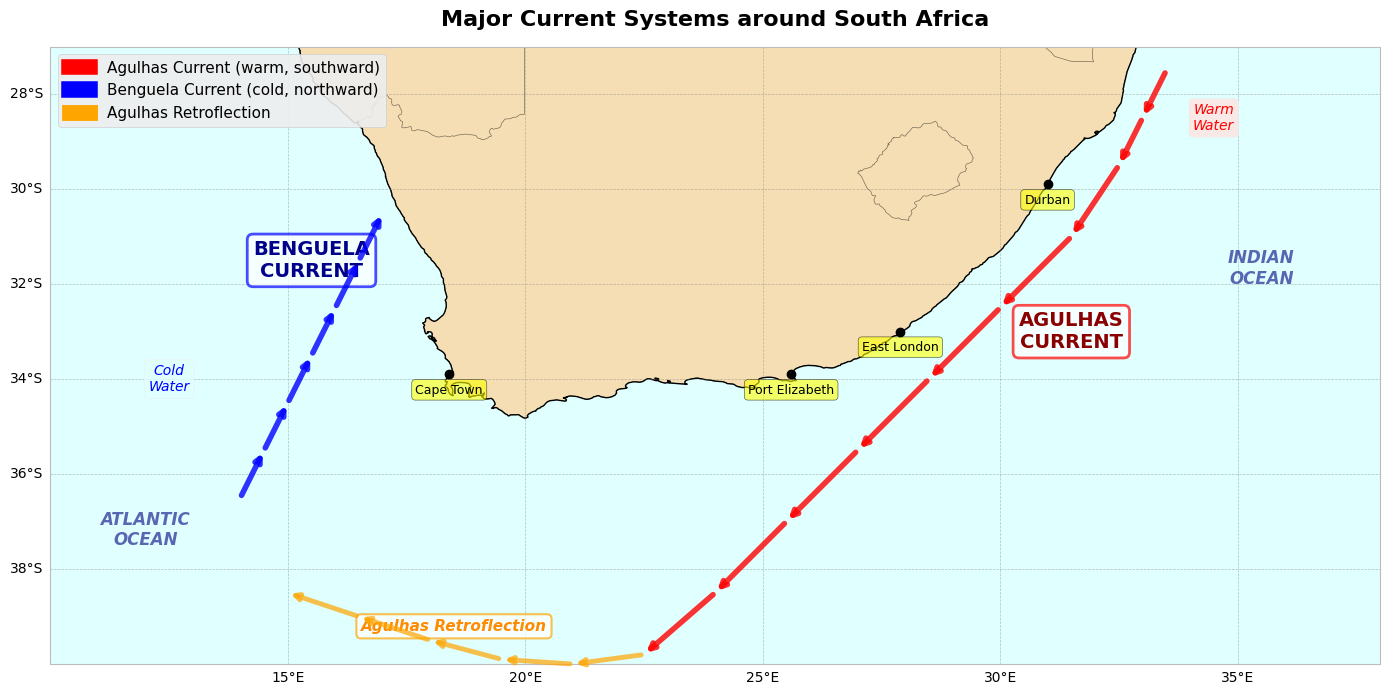

In [48]:
# Generate schematic map of South African current systems
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Create figure
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to focus on South Africa
ax.set_extent([10, 38, -40, -27], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='wheat', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightcyan')
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, alpha=0.5)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# AGULHAS CURRENT (east coast - warm, southward flow)
# Strong western boundary current flowing southward along the shelf edge (offshore)
agulhas_lons = np.array([33.5, 33.0, 32.5, 31.5, 30.0, 28.5, 27.0, 25.5, 24.0, 22.5])
agulhas_lats = np.array([-27.5, -28.5, -29.5, -31.0, -32.5, -34.0, -35.5, -37.0, -38.5, -39.8])

# Draw Agulhas Current with red arrows (warm)
for i in range(len(agulhas_lons)-1):
    ax.annotate('', xy=(agulhas_lons[i+1], agulhas_lats[i+1]), 
                xytext=(agulhas_lons[i], agulhas_lats[i]),
                arrowprops=dict(arrowstyle='->', lw=4, color='red', alpha=0.8),
                zorder=5)

# BENGUELA CURRENT (west coast - cold, northward flow)
# Eastern boundary upwelling system flowing northward along the shelf (offshore)
benguela_lons = np.array([14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0])
benguela_lats = np.array([-36.5, -35.5, -34.5, -33.5, -32.5, -31.5, -30.5])

# Draw Benguela Current with blue arrows (cold)
for i in range(len(benguela_lons)-1):
    ax.annotate('', xy=(benguela_lons[i+1], benguela_lats[i+1]), 
                xytext=(benguela_lons[i], benguela_lats[i]),
                arrowprops=dict(arrowstyle='->', lw=4, color='blue', alpha=0.8),
                zorder=5)

# AGULHAS RETURN CURRENT (retroflection zone)
# Current retroflecting and flowing eastward in the Southern Ocean
retroflection_lons = np.array([22.5, 21.0, 19.5, 18.0, 16.5, 15.0])
retroflection_lats = np.array([-39.8, -40.0, -39.9, -39.5, -39.0, -38.5])

for i in range(len(retroflection_lons)-1):
    ax.annotate('', xy=(retroflection_lons[i+1], retroflection_lats[i+1]), 
                xytext=(retroflection_lons[i], retroflection_lats[i]),
                arrowprops=dict(arrowstyle='->', lw=3.5, color='orange', alpha=0.7),
                zorder=5)

# Add labels for current systems
ax.text(31.5, -33.0, 'AGULHAS\nCURRENT', fontsize=14, fontweight='bold', 
        color='darkred', ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='red', linewidth=2))

ax.text(15.5, -31.5, 'BENGUELA\nCURRENT', fontsize=14, fontweight='bold', 
        color='darkblue', ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='blue', linewidth=2))

ax.text(18.5, -39.3, 'Agulhas Retroflection', fontsize=11, fontweight='bold', 
        color='darkorange', ha='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='orange', linewidth=1.5))

# Add temperature indicators
ax.text(34.5, -28.5, 'Warm\nWater', fontsize=10, color='red', 
        ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.8))

ax.text(12.5, -34.0, 'Cold\nWater', fontsize=10, color='blue', 
        ha='center', va='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

# Add legend
from matplotlib.patches import FancyArrowPatch
legend_elements = [
    FancyArrowPatch((0, 0), (1, 0), arrowstyle='->', lw=4, color='red', label='Agulhas Current (warm, southward)'),
    FancyArrowPatch((0, 0), (1, 0), arrowstyle='->', lw=4, color='blue', label='Benguela Current (cold, northward)'),
    FancyArrowPatch((0, 0), (1, 0), arrowstyle='->', lw=3.5, color='orange', label='Agulhas Retroflection')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

# Add major cities
cities = {
    'Cape Town': (18.4, -33.9),
    'Port Elizabeth': (25.6, -33.9),
    'Durban': (31.0, -29.9),
    'East London': (27.9, -33.0)
}

for city, (lon, lat) in cities.items():
    ax.plot(lon, lat, 'ko', markersize=6, zorder=10)
    ax.text(lon, lat-0.4, city, fontsize=9, ha='center', 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6, edgecolor='black', linewidth=0.5))

# Add ocean labels
ax.text(12.0, -37.5, 'ATLANTIC\nOCEAN', fontsize=12, fontweight='bold', 
        color='navy', ha='center', style='italic', alpha=0.6)
ax.text(35.5, -32.0, 'INDIAN\nOCEAN', fontsize=12, fontweight='bold', 
        color='navy', ha='center', style='italic', alpha=0.6)

# Add title
ax.set_title('Major Current Systems around South Africa', 
             fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('./img/south_africa_currents_map.png', dpi=150, bbox_inches='tight', facecolor='white')
print("✓ Schematic map of South African current systems created successfully")
print("  Saved to: ./img/south_africa_currents_map.png")
plt.show()